In [1]:
%load_ext autoreload
%autoreload 2

# RMSD Analysis: PduA / PduJ Hexameric Mutant Poses

This notebook provides a suite of functions for:
1. **Crystal structure validation** — RMSD of computed mutants vs. known PDB crystal structures
2. **Mutant vs. wildtype RMSD** — structural divergence for all generated mutants
3. **Bound vs. unbound RMSD** — effect of 1,2-PD ligand on protein conformation
4. **Pairwise RMSD correlation matrix** — clustering mutations by structural similarity

All functions are parameterised and reusable for PduA **or** PduJ libraries.

---
**Available crystal structures**

| PDB  | Variant  |
|------|----------|
| 3NGK | WT PduA  |
| 4RBT | S40L     |
| 4QIF | S40H     |
| 4QIG | S40C     |
| 4RBU | S40Q     |

## Cell 1 — Imports & PyRosetta Initialisation

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import os
import sys
import glob
import warnings
from math import sqrt
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

import pyrosetta
from pyrosetta import *
from pyrosetta.rosetta.core.import_pose import pose_from_file

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# PYROSETTA INIT  (silent – suppress Rosetta log spam)
# ─────────────────────────────────────────────────────────────────────────────
pyrosetta.init("-mute all -ex1 -ex2")
print('PyRosetta initialised.')

┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2026 [Rosetta PyRosetta4.Release.python311.m1 2026.03+releasequarterly.5e498f1409c68ade56c8ce5842bf79e1b02e8db4 2026-01-13T13:24:11] retrieved from: http://www.pyrosetta.org
PyRosetta initialised.


## Cell 2 — PDB Helper Functions (reused from pipeline)

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# PDB HELPERS (compatible with your existing pipeline)
# ─────────────────────────────────────────────────────────────────────────────

def dist(a, b):
    """Euclidean distance between two 3-tuples."""
    return sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2 + (a[2]-b[2])**2)


def fix_chains_and_add_TER(in_pdb: str, out_pdb: str, cutoff: float = 2.0) -> str:
    """
    Reconstruct chain IDs by detecting breaks in backbone connectivity
    (C → N distance > cutoff) and insert TER records.

    Parameters
    ----------
    in_pdb  : path to input PDB
    out_pdb : path for fixed output PDB
    cutoff  : Å threshold for a chain break (default 2.0 Å)

    Returns
    -------
    out_pdb : echoed back for convenience
    """
    chain_letters = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'
    current_chain = 0
    prev_C = None
    new_lines = []

    with open(in_pdb) as f:
        lines = f.readlines()

    for line in lines:
        if not line.startswith(('ATOM', 'HETATM')):
            new_lines.append(line)
            continue

        atom   = line[12:16].strip()
        x      = float(line[30:38])
        y      = float(line[38:46])
        z      = float(line[46:54])

        if atom == 'N' and prev_C is not None:
            if dist((x, y, z), prev_C) > cutoff:
                new_lines.append('TER\n')
                current_chain += 1

        chain_id = chain_letters[min(current_chain, 25)]
        line = line[:21] + chain_id + line[22:]
        new_lines.append(line)

        if atom == 'C':
            prev_C = (x, y, z)

    new_lines.append('END\n')

    with open(out_pdb, 'w') as f:
        f.writelines(new_lines)

    print(f'  Chain-fixed PDB → {out_pdb}')
    return out_pdb


def load_pose(pdb_path: str, fix_chains: bool = False, tmp_dir: str = '/tmp') -> 'Pose':
    """
    Load a PyRosetta Pose from file.  Optionally run fix_chains_and_add_TER
    first (useful for raw RCSB / Rosetta output that lacks proper chain IDs).

    Parameters
    ----------
    pdb_path   : path to .pdb or .cif
    fix_chains : if True, write a chain-fixed copy before loading
    tmp_dir    : where to write the fixed copy

    Returns
    -------
    pose : pyrosetta.Pose
    """
    if not os.path.exists(pdb_path):
        raise FileNotFoundError(f'PDB not found: {pdb_path}')

    load_path = pdb_path
    if fix_chains:
        stem     = Path(pdb_path).stem
        fixed    = os.path.join(tmp_dir, f'{stem}_fixed.pdb')
        load_path = fix_chains_and_add_TER(pdb_path, fixed)

    pose = pose_from_file(load_path)
    return pose

mutants = ['3NGK','4QIF','4QIG','4RBT','4RBU']

current_directory = os.getcwd()

for mut in mutants:
    # Save a fixed Pdu Hexamer
    fix_chains_and_add_TER(f"{mut}.pdb1", f"{mut}_fixed.pdb")
    print(f"{mut}_fixed.pdb saved to {current_directory}/{mut}_fixed.pdb")

  Chain-fixed PDB → 3NGK_fixed.pdb
3NGK_fixed.pdb saved to /Users/matthew/Desktop/Pdu_PyRosetta/3NGK_fixed.pdb
  Chain-fixed PDB → 4QIF_fixed.pdb
4QIF_fixed.pdb saved to /Users/matthew/Desktop/Pdu_PyRosetta/4QIF_fixed.pdb
  Chain-fixed PDB → 4QIG_fixed.pdb
4QIG_fixed.pdb saved to /Users/matthew/Desktop/Pdu_PyRosetta/4QIG_fixed.pdb
  Chain-fixed PDB → 4RBT_fixed.pdb
4RBT_fixed.pdb saved to /Users/matthew/Desktop/Pdu_PyRosetta/4RBT_fixed.pdb
  Chain-fixed PDB → 4RBU_fixed.pdb
4RBU_fixed.pdb saved to /Users/matthew/Desktop/Pdu_PyRosetta/4RBU_fixed.pdb


## Cell 3 — Core RMSD Engine (Kabsch superimposition + atom extraction)

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CORE RMSD UTILITIES
# ─────────────────────────────────────────────────────────────────────────────

def _extract_backbone_coords(
    pose,
    chain_id: Optional[str]        = None,
    pdb_res_range: Optional[Tuple]  = None,
    atom_names: Tuple[str, ...]     = ('CA',),
) -> Tuple[np.ndarray, List[Tuple[str, int]]]:
    """
    Extract Cartesian coordinates for selected atoms from a pose.

    Parameters
    ----------
    pose          : PyRosetta Pose
    chain_id      : single chain letter, or None for all protein chains
    pdb_res_range : (start, end) in PDB numbering (inclusive), or None
    atom_names    : tuple of atom names to collect, e.g. ('CA',) or ('N','CA','C','O')

    Returns
    -------
    coords  : (N, 3) float64 array
    labels  : list of (chain, pdb_resnum, atom_name) for each row
    """
    coords = []
    labels = []
    pi     = pose.pdb_info()

    for i in range(1, pose.total_residue() + 1):
        res = pose.residue(i)
        if not res.is_protein():
            continue
        ch      = pi.chain(i) if pi else 'A'
        pdb_num = pi.number(i) if pi else i

        if chain_id is not None and ch != chain_id:
            continue
        if pdb_res_range is not None:
            lo, hi = pdb_res_range
            if not (lo <= pdb_num <= hi):
                continue

        for aname in atom_names:
            if res.has(aname):
                xyz = res.xyz(aname)
                coords.append([xyz.x, xyz.y, xyz.z])
                labels.append((ch, pdb_num, aname))

    return np.array(coords, dtype=np.float64), labels


def _match_labels(
    coords1: np.ndarray, labels1: list,
    coords2: np.ndarray, labels2: list,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Intersect two labelled coordinate sets on (pdb_resnum, atom_name) keys,
    ignoring chain letter differences (allows crystal monomer vs hex chain A).

    Returns matched (coords1_sub, coords2_sub) in the same order.
    """
    # Key = (resnum, atom_name) — ignore chain so crystal monomers match hexamer chains
    map2 = {(ch, rn, an): idx for idx, (ch, rn, an) in enumerate(labels2)}

    # First try exact (chain, resnum, atom) match
    idx1, idx2 = [], []
    for i, (ch, rn, an) in enumerate(labels1):
        key = (ch, rn, an)
        if key in map2:
            idx1.append(i)
            idx2.append(map2[key])

    # Fall back: match on (resnum, atom_name) only – e.g. crystal monomer vs hex chain A
    if not idx1:
        map2_noc = {}
        for ch, rn, an in labels2:
            map2_noc.setdefault((rn, an), []).append(
                next(k for k, (c,r,a) in enumerate(labels2) if c==ch and r==rn and a==an)
            )
        for i, (ch, rn, an) in enumerate(labels1):
            key = (rn, an)
            if key in map2_noc:
                idx1.append(i)
                idx2.append(map2_noc[key][0])

    if not idx1:
        raise ValueError('No matching residue/atom labels found between the two poses.')

    return coords1[idx1], coords2[idx2]


def kabsch_rmsd(
    coords_ref: np.ndarray,
    coords_mob: np.ndarray,
    superimpose: bool = True,
) -> float:
    """
    Compute RMSD between two (N,3) coordinate arrays, optionally after
    Kabsch least-squares superimposition of coords_mob onto coords_ref.

    Parameters
    ----------
    coords_ref  : reference coordinates (N, 3)
    coords_mob  : mobile coordinates (N, 3)
    superimpose : if True (default), remove translation and optimal rotation

    Returns
    -------
    rmsd : float (Å)
    """
    assert coords_ref.shape == coords_mob.shape, 'Coordinate arrays must be same shape'

    if not superimpose:
        diff = coords_ref - coords_mob
        return float(np.sqrt((diff**2).sum(axis=1).mean()))

    # Centre
    c_ref = coords_ref - coords_ref.mean(axis=0)
    c_mob = coords_mob - coords_mob.mean(axis=0)

    # Kabsch rotation (SVD)
    H        = c_mob.T @ c_ref
    U, S, Vt = np.linalg.svd(H)
    # Correct for reflection
    d = np.linalg.det(Vt.T @ U.T)
    D = np.diag([1.0, 1.0, d])
    R = Vt.T @ D @ U.T

    c_mob_rot = (R @ c_mob.T).T
    diff      = c_ref - c_mob_rot
    return float(np.sqrt((diff**2).sum(axis=1).mean()))


def _pose_rmsd(
    pose_ref,
    pose_mob,
    chain_ref: Optional[str]       = None,
    chain_mob: Optional[str]       = None,
    pdb_res_range: Optional[Tuple] = None,
    atom_names: Tuple[str, ...]    = ('CA',),
    superimpose: bool              = True,
) -> float:
    """
    Convenience wrapper: extract, match, and compute Kabsch RMSD between poses.
    """
    c1, l1 = _extract_backbone_coords(pose_ref, chain_ref, pdb_res_range, atom_names)
    c2, l2 = _extract_backbone_coords(pose_mob, chain_mob, pdb_res_range, atom_names)

    # If chain labels differ (e.g. crystal A vs computed A) strip chain for matching
    if chain_ref != chain_mob:
        # relabel both with neutral chain so _match_labels uses (resnum, atom)
        l1 = [('X', rn, an) for (_, rn, an) in l1]
        l2 = [('X', rn, an) for (_, rn, an) in l2]

    c1m, c2m = _match_labels(c1, l1, c2, l2)

    if len(c1m) == 0:
        raise ValueError('Zero matched atoms — check chain IDs and residue ranges.')

    return kabsch_rmsd(c1m, c2m, superimpose=superimpose)

# ─────────────────────────────────────────────────────────────────────────────
# PORE GEOMETRY FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────
#
# Design notes
# ────────────
# All pore diameter measurements follow the same algorithm used in
# PduA_Mutant_Docking.ipynb (PoreAnalyzer._measure_cross):
#
#   1.  Find the "opposite" chain pairs geometrically by chain-centroid dot
#       product — no assumption that chain A faces chain D.
#   2.  At the target position, collect sidechain heavy atoms from each chain
#       in an opposite pair (falling back to Cα for Gly).
#   3.  The pore DIAMETER = min(|ci − cj| − ri − rj) over all heavy-atom
#       pairs, where ri/rj are VDW radii.  This gives accessible surface-to-
#       surface clearance.
#   4.  Pore RADIUS = diameter / 2.
#
# The position is identified by PDB residue number (resseq), not by rank,
# so S40 → target_pdb_num=40  and  K37 → target_pdb_num=37.
#
# Crystal structures are parsed with a lightweight inline PDB reader
# (no PyRosetta required) so the same function works on raw PDB files.
# ─────────────────────────────────────────────────────────────────────────────

# Sidechain Van der Waals volumes (Å³) — Pontius et al. 1996 / Tsai et al. 1999
_SC_VOLUME: Dict[str, float] = {
    'ALA':  67.0, 'ARG': 196.0, 'ASN': 113.0, 'ASP': 111.0,
    'CYS':  86.0, 'GLN': 144.0, 'GLU': 138.0, 'GLY':   0.0,
    'HIS': 153.0, 'ILE': 124.0, 'LEU': 124.0, 'LYS': 135.0,
    'MET': 124.0, 'PHE': 135.0, 'PRO':  90.0, 'SER':  73.0,
    'THR':  93.0, 'TRP': 163.0, 'TYR': 141.0, 'VAL': 105.0,
}

# Heavy-atom VDW radii (Å) — same as PduA_Mutant_Docking.ipynb
_VDW_RADII: Dict[str, float] = {
    'H': 1.20, 'C': 1.70, 'N': 1.55, 'O': 1.52,
    'S': 1.80, 'P': 1.80, 'F': 1.47, 'CL': 1.75,
    'BR': 1.85, 'I': 1.98,
}
_DEFAULT_VDW = 1.70

_BACKBONE_ATOMS = frozenset({'N', 'CA', 'C', 'O', 'OXT', 'H', 'HA'})

_AA3TO1 = {
    'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C',
    'GLN':'Q','GLU':'E','GLY':'G','HIS':'H','ILE':'I',
    'LEU':'L','LYS':'K','MET':'M','PHE':'F','PRO':'P',
    'SER':'S','THR':'T','TRP':'W','TYR':'Y','VAL':'V',
}


# ─────────────────────────────────────────────────────────────────────────────
# LIGHTWEIGHT PDB READER  (no PyRosetta — works on raw PDB files)
# ─────────────────────────────────────────────────────────────────────────────

# Standard amino-acid residue names — defined at module level so the
# lightweight PDB reader can filter HETATM records by residue name.
# Rosetta writes all residues as HETATM when a pose contains a ligand.
_STANDARD_AA_NAMES: frozenset = frozenset({
    'ALA', 'ARG', 'ASN', 'ASP', 'CYS', 'GLN', 'GLU', 'GLY', 'HIS', 'ILE',
    'LEU', 'LYS', 'MET', 'PHE', 'PRO', 'SER', 'THR', 'TRP', 'TYR', 'VAL',
    'HID', 'HIE', 'HIP', 'HSD', 'HSE', 'HSP',   # Rosetta HIS tautomers
    'CYD', 'CYSD',                                 # Rosetta disulfide CYS
})

def _parse_pdb_atoms(pdb_path: str) -> List[Dict]:
    """
    Parse protein heavy atoms from a PDB file.

    Accepts both ATOM and HETATM records whose residue name is a standard
    amino acid.  This is necessary because Rosetta writes all residues —
    including standard protein residues — as HETATM when the pose also
    contains a non-protein ligand (e.g. a docked 12PD molecule).

    Non-standard HETATM entries (ligands, waters, ions) are skipped.
    Hydrogen atoms are always skipped.
    """
    # Belt-and-suspenders: inline copy so this never fails due to execution order
    _std_aa = frozenset({
        'ALA', 'ARG', 'ASN', 'ASP', 'CYS', 'GLN', 'GLU', 'GLY', 'HIS', 'ILE',
        'LEU', 'LYS', 'MET', 'PHE', 'PRO', 'SER', 'THR', 'TRP', 'TYR', 'VAL',
        'HID', 'HIE', 'HIP', 'HSD', 'HSE', 'HSP', 'CYD', 'CYSD',
    })
    atoms = []
    _diag_done = False
    with open(pdb_path) as fh:
        for line in fh:
            # Diagnostic: print the first content line of the first file
            # so we can verify record format (ATOM vs HETATM vs other)
            if not _diag_done and line.strip():
                _diag_done = True
            rec = line[:6].rstrip()
            if rec not in ('ATOM', 'HETATM'):
                continue
            resname = line[17:20].strip()
            # For HETATM records only keep standard amino acids — this passes
            # Rosetta-labelled protein residues while discarding ligands/waters.
            if rec == 'HETATM' and resname not in _std_aa:
                continue
            aname    = line[12:16].strip()
            elem_col = line[76:78].strip() if len(line) > 77 else ''
            elem = elem_col.upper() if elem_col else next(
                (ch for ch in aname if ch.isalpha()), 'X').upper()
            if elem == 'H':
                continue
            try:
                atoms.append({
                    'chain':   line[21],
                    'resname': resname,
                    'resseq':  int(line[22:26]),
                    'name':    aname,
                    'elem':    elem,
                    'x':       float(line[30:38]),
                    'y':       float(line[38:46]),
                    'z':       float(line[46:54]),
                })
            except ValueError:
                continue
    return atoms


def _chain_centroids(chain_atoms: Dict[str, List[Dict]]) -> Dict[str, np.ndarray]:
    """Return mean Cα position per chain (falls back to all heavy atoms for Gly)."""
    centroids = {}
    for ch, atoms in chain_atoms.items():
        ca = [a for a in atoms if a['name'] == 'CA']
        src = ca if ca else atoms
        coords = np.array([[a['x'], a['y'], a['z']] for a in src])
        centroids[ch] = coords.mean(axis=0)
    return centroids


def _resolve_resseq_per_chain(
    chain_atoms: Dict[str, List[Dict]],
    target_rank: int,
) -> Dict[str, int]:
    """
    Return {chain: actual_resseq} for the *target_rank*-th residue (1-based)
    within each chain, sorted by ascending resseq.

    Works transparently for both numbering conventions:
      • Per-chain restart  (crystal/unbound PDBs: chain A 1-88, chain B 1-88)
      • Continuous across chains (Rosetta docked PDBs: A 1-88, B 89-176, ...)

    Chains with fewer than target_rank distinct residues are omitted.
    """
    result = {}
    for ch, ats in chain_atoms.items():
        unique_resseqs = sorted(set(a['resseq'] for a in ats))
        if len(unique_resseqs) >= target_rank:
            result[ch] = unique_resseqs[target_rank - 1]
    return result


def _find_opposite_chain_pairs(
    chain_atoms: Dict[str, List[Dict]],
) -> List[Tuple[str, str]]:
    """
    Identify opposite chain pairs in a homo-oligomer by chain-centroid
    dot products.  Chains whose unit vectors point in opposite directions
    (most negative dot product) are paired.

    Mirrors PoreAnalyzer.find_opposite_chains() from PduA_Mutant_Docking.ipynb.
    """
    centroids      = _chain_centroids(chain_atoms)
    assembly_centre = np.mean(list(centroids.values()), axis=0)

    unit_vecs = {}
    for ch, cen in centroids.items():
        v = cen - assembly_centre
        n = np.linalg.norm(v)
        unit_vecs[ch] = v / n if n > 1e-6 else v

    chains = sorted(chain_atoms.keys())
    used, pairs = set(), []
    for c in chains:
        if c in used:
            continue
        best_cos, best = 2.0, None
        for d in chains:
            if d == c or d in used:
                continue
            cos = float(np.dot(unit_vecs[c], unit_vecs[d]))
            if cos < best_cos:
                best_cos, best = cos, d
        if best is not None:
            pairs.append((c, best))
            used.add(c)
            used.add(best)
    return pairs


def _sidechain_atoms(residue_atoms: List[Dict]) -> List[Dict]:
    """Return sidechain heavy atoms, falling back to Cα for Gly."""
    sc = [a for a in residue_atoms if a['name'] not in _BACKBONE_ATOMS]
    return sc if sc else [a for a in residue_atoms if a['name'] == 'CA']


def _measure_cross_diameter(
    chain_atoms:   Dict[str, List[Dict]],
    chain_a:       str,
    chain_b:       str,
    resseq_source: 'Union[int, Dict[str, int]]',
) -> Tuple[float, Dict]:
    """
    Measure the VDW-corrected sidechain cross-pore diameter between two
    opposite chains at the target residue position.

    *resseq_source* accepts:
      • int   – same absolute resseq for both chains (per-chain-restart PDBs)
      • dict  – {chain: actual_resseq} from _resolve_resseq_per_chain
                (Rosetta continuous-numbering docked PDBs)

    Returns (diameter_Å, info_dict).
    diameter = min over all sidechain heavy-atom pairs of:
                   |ci − cj| − vdw_i − vdw_j    (≥ 0)
    """
    def _rseq(ch):
        return resseq_source.get(ch) if isinstance(resseq_source, dict) else resseq_source

    # Collect all atoms for the target residue in each chain
    def res_atoms(ch):
        rseq = _rseq(ch)
        return [] if rseq is None else [a for a in chain_atoms[ch] if a['resseq'] == rseq]

    sc_a = _sidechain_atoms(res_atoms(chain_a))
    sc_b = _sidechain_atoms(res_atoms(chain_b))

    if not sc_a or not sc_b:
        return float('nan'), {}

    best_d, best_info = float('inf'), {}
    for ai in sc_a:
        ri = _VDW_RADII.get(ai['elem'], _DEFAULT_VDW)
        ci = np.array([ai['x'], ai['y'], ai['z']])
        for aj in sc_b:
            rj = _VDW_RADII.get(aj['elem'], _DEFAULT_VDW)
            cj = np.array([aj['x'], aj['y'], aj['z']])
            d  = float(np.linalg.norm(ci - cj)) - ri - rj
            if d < best_d:
                best_d = d
                best_info = {
                    'chain_a': chain_a, 'chain_b': chain_b,
                    'atom_a': ai['name'], 'atom_b': aj['name'],
                    'resname': ai['resname'],
                }
    return max(0.0, round(best_d, 3)), best_info


def measure_pore_diameter_from_pdb(
    pdb_path:            str,
    target_resseq:       int,
    protein_chains:      Optional[List[str]] = None,
    use_absolute_resseq: bool                = False,
) -> Dict:
    """
    Measure pore diameter at a given PDB residue number using VDW-corrected
    sidechain cross distances.  Chain pairing is determined geometrically.

    Parameters
    ----------
    pdb_path             : path to PDB file (crystal or computed model)
    target_resseq        : residue number to measure
    protein_chains       : restrict to these chains; None = all chains in file
    use_absolute_resseq  : if True, treat target_resseq as a literal PDB resseq
                           value and look up chains that contain it directly.
                           Use for crystal PDB files whose RCSB numbering is
                           intact (e.g. resseq 40 = S40 in all crystal files).
                           If False (default), use rank-based lookup, which
                           handles Rosetta continuous-numbering docked PDBs.

    Returns
    -------
    dict:
        pore_diameter_A  : VDW-surface-to-surface accessible diameter (Å)
        pore_radius_A    : diameter / 2
        residue_name     : 3-letter code at the pore position (chain A / first chain)
        chain_a, chain_b : chains used for measurement (the opposite pair)
        atom_a, atom_b   : closest sidechain atoms
        n_chains         : number of chains where the residue was found
    """
    atoms = _parse_pdb_atoms(pdb_path)
    chain_atoms: Dict[str, List[Dict]] = {}
    for a in atoms:
        chain_atoms.setdefault(a['chain'], []).append(a)

    # Filter to requested chains
    if protein_chains is not None:
        chain_atoms = {c: v for c, v in chain_atoms.items() if c in protein_chains}

    if use_absolute_resseq:
        # Crystal files: target_resseq is the literal RCSB resseq (e.g. 40 for S40).
        # Build the map directly — only include chains that actually contain that resseq.
        resseq_map = {
            ch: target_resseq
            for ch, ats in chain_atoms.items()
            if any(a['resseq'] == target_resseq for a in ats)
        }
    else:
        # Docked / unbound PDBs: use rank-based lookup to handle Rosetta's
        # continuous chain numbering (chain A = 1-88, chain B = 89-176, …).
        resseq_map = _resolve_resseq_per_chain(chain_atoms, target_resseq)

    chains_with_res = sorted(resseq_map.keys())
    n_chains = len(chains_with_res)

    if n_chains < 2:
        return {
            'pore_diameter_A': float('nan'), 'pore_radius_A': float('nan'),
            'residue_name': 'UNK', 'chain_a': '?', 'chain_b': '?',
            'atom_a': '?', 'atom_b': '?', 'n_chains': n_chains,
        }

    # Residue name at the target rank position (chain A / first chain)
    first_ch  = chains_with_res[0]
    first_seq = resseq_map[first_ch]
    res_name  = next(
        (a['resname'] for a in chain_atoms.get(first_ch, [])
         if a['resseq'] == first_seq),
        'UNK'
    )

    # Find opposite chain pairs (geometric, not assumed A-D)
    pairs = _find_opposite_chain_pairs(
        {c: chain_atoms[c] for c in chains_with_res}
    )

    best_d, best_info = float('inf'), {}
    for ca, cb in pairs:
        d, info = _measure_cross_diameter(chain_atoms, ca, cb, resseq_map)
        if not np.isnan(d) and d < best_d:
            best_d, best_info = d, info

    if np.isinf(best_d) or not best_info:
        best_d = float('nan')

    return {
        'pore_diameter_A': best_d,
        'pore_radius_A':   best_d / 2.0 if not np.isnan(best_d) else float('nan'),
        'residue_name':    res_name,
        'chain_a':         best_info.get('chain_a', '?'),
        'chain_b':         best_info.get('chain_b', '?'),
        'atom_a':          best_info.get('atom_a', '?'),
        'atom_b':          best_info.get('atom_b', '?'),
        'n_chains':        n_chains,
    }


# ─────────────────────────────────────────────────────────────────────────────
# POSE-BASED PORE GEOMETRY  (PyRosetta, for mutant model comparisons)
# ─────────────────────────────────────────────────────────────────────────────

def _get_pore_resnums(
    pose,
    target_pdb_num: int,
    chains: List[str] = list('ABCDEF'),
) -> Dict[str, int]:
    """Return {chain: pose_resnum} for target_pdb_num across chains."""
    hits = {}
    pi   = pose.pdb_info()
    if pi is None:
        return hits
    for i in range(1, pose.total_residue() + 1):
        ch  = pi.chain(i)
        num = pi.number(i)
        if ch in chains and num == target_pdb_num:
            hits[ch] = i
    return hits


def compute_pore_geometry(
    pose,
    target_pdb_num:  int,
    chains:          List[str] = list('ABCDEF'),
    wt_pose                    = None,
) -> Dict:
    """
    Compute pore geometry metrics for a single mutant pose using the same
    VDW-corrected sidechain cross-distance algorithm as PoreAnalyzer in
    PduA_Mutant_Docking.ipynb.

    Opposite chains are found geometrically (chain centroid dot products),
    NOT assumed to be A↔D.

    Parameters
    ----------
    pose           : PyRosetta Pose
    target_pdb_num : PDB residue number (37 for K37, 40 for S40)
    chains         : all chains of the hexamer
    wt_pose        : WT pose for Cβ deviation; None = skip (or for WT itself)

    Returns
    -------
    dict with keys:
        residue_name, pore_diameter_A, pore_radius_A,
        sidechain_volume_A3, mean_cb_distance_A,
        cb_centroid_dev_A, n_chains
    """
    resnums = _get_pore_resnums(pose, target_pdb_num, chains)

    if not resnums:
        return {
            'residue_name': 'UNK',
            'pore_diameter_A': np.nan, 'pore_radius_A': np.nan,
            'sidechain_volume_A3': np.nan, 'mean_cb_distance_A': np.nan,
            'cb_centroid_dev_A': np.nan, 'n_chains': 0,
        }

    # ── Residue name ─────────────────────────────────────────────────────────
    first_rn = next(iter(resnums.values()))
    res_name = pose.residue(first_rn).name3()

    # ── Sidechain total volume ────────────────────────────────────────────────
    sc_vol = _SC_VOLUME.get(res_name, 0.0) * len(resnums)

    # ── Cβ positions for centroid and deviation calc ──────────────────────────
    cb_positions: Dict[str, np.ndarray] = {}
    for ch, rn in resnums.items():
        res  = pose.residue(rn)
        atom = 'CB' if res.has('CB') else 'CA'
        xyz  = res.xyz(atom)
        cb_positions[ch] = np.array([xyz.x, xyz.y, xyz.z])

    cb_arr    = np.array(list(cb_positions.values()))
    pore_axis = cb_arr.mean(axis=0)
    dists     = np.linalg.norm(cb_arr - pore_axis, axis=1)
    mean_cb_dist = float(dists.mean())

    # ── VDW-corrected pore diameter (geometric opposite chain pairs) ──────────
    # Extract chain centroids from CA atoms to find opposite pairs
    chain_ca: Dict[str, np.ndarray] = {}
    pi = pose.pdb_info()
    for ch, rn_list in [(c, []) for c in resnums]:
        ca_coords = []
        for i in range(1, pose.total_residue() + 1):
            if pi and pi.chain(i) == ch:
                res = pose.residue(i)
                if res.is_protein() and res.has('CA'):
                    xyz = res.xyz('CA')
                    ca_coords.append([xyz.x, xyz.y, xyz.z])
        if ca_coords:
            chain_ca[ch] = np.mean(ca_coords, axis=0)

    # Build synthetic chain_atoms dict for geometric pairing (need all chains)
    full_chain_ca: Dict[str, np.ndarray] = {}
    for ch in chains:
        ca_coords = []
        for i in range(1, pose.total_residue() + 1):
            if pi and pi.chain(i) == ch:
                res = pose.residue(i)
                if res.is_protein() and res.has('CA'):
                    xyz = res.xyz('CA')
                    ca_coords.append([xyz.x, xyz.y, xyz.z])
        if ca_coords:
            full_chain_ca[ch] = np.mean(ca_coords, axis=0)

    # Find opposite pairs among chains that have the target residue
    assembly_centre = np.mean(list(full_chain_ca.values()), axis=0) if full_chain_ca else pore_axis
    present_chains  = sorted(resnums.keys())

    unit_vecs = {}
    for ch in present_chains:
        v = (full_chain_ca.get(ch, cb_positions[ch])) - assembly_centre
        n = np.linalg.norm(v)
        unit_vecs[ch] = v / n if n > 1e-6 else v

    used, opp_pairs = set(), []
    for c in present_chains:
        if c in used:
            continue
        best_cos, best = 2.0, None
        for d in present_chains:
            if d == c or d in used:
                continue
            cos = float(np.dot(unit_vecs[c], unit_vecs[d]))
            if cos < best_cos:
                best_cos, best = cos, d
        if best is not None:
            opp_pairs.append((c, best))
            used.add(c); used.add(best)

    # Measure VDW sidechain cross-diameter for each opposite pair
    pore_diameter = float('nan')
    best_d_all = float('inf')
    for ca_ch, cb_ch in opp_pairs:
        rn_a = resnums[ca_ch]
        rn_b = resnums[cb_ch]
        res_a = pose.residue(rn_a)
        res_b = pose.residue(rn_b)

        # Collect sidechain heavy atoms (skip backbone; fall back to CA for Gly)
        def get_sc_atoms(res):
            sc = [(res.xyz(res.atom_name(j)), res.atom_name(j).strip())
                  for j in range(1, res.natoms() + 1)
                  if not res.atom_is_hydrogen(j)
                  and res.atom_name(j).strip() not in _BACKBONE_ATOMS]
            if not sc:
                sc = [(res.xyz('CA'), 'CA')]
            return sc

        sc_a = get_sc_atoms(res_a)
        sc_b = get_sc_atoms(res_b)

        for (xyz_a, aname_a) in sc_a:
            # Infer element from atom name
            elem_a = next((c for c in aname_a if c.isalpha()), 'C').upper()
            ri = _VDW_RADII.get(elem_a, _DEFAULT_VDW)
            ca_pt = np.array([xyz_a.x, xyz_a.y, xyz_a.z])
            for (xyz_b, aname_b) in sc_b:
                elem_b = next((c for c in aname_b if c.isalpha()), 'C').upper()
                rj = _VDW_RADII.get(elem_b, _DEFAULT_VDW)
                cb_pt = np.array([xyz_b.x, xyz_b.y, xyz_b.z])
                d = float(np.linalg.norm(ca_pt - cb_pt)) - ri - rj
                if d < best_d_all:
                    best_d_all = d

    if not np.isinf(best_d_all):
        pore_diameter = max(0.0, round(best_d_all, 3))

    # ── Cβ deviation from WT ─────────────────────────────────────────────────
    cb_dev = np.nan
    if wt_pose is not None:
        wt_resnums = _get_pore_resnums(wt_pose, target_pdb_num, chains)
        sq_devs = []
        for ch in resnums:
            if ch not in wt_resnums:
                continue
            res_mut = pose.residue(resnums[ch])
            res_wt  = wt_pose.residue(wt_resnums[ch])
            for aname in ('CB', 'CA'):
                if res_mut.has(aname) and res_wt.has(aname):
                    d = res_mut.xyz(aname).distance(res_wt.xyz(aname))
                    sq_devs.append(d * d)
                    break
        if sq_devs:
            cb_dev = float(np.sqrt(np.mean(sq_devs)))

    return {
        'residue_name':        res_name,
        'pore_diameter_A':     pore_diameter,
        'pore_radius_A':       pore_diameter / 2.0 if not np.isnan(pore_diameter) else np.nan,
        'sidechain_volume_A3': sc_vol,
        'mean_cb_distance_A':  mean_cb_dist,
        'cb_centroid_dev_A':   cb_dev,
        'n_chains':            len(resnums),
    }


def batch_pore_geometry(
    pdb_map:        Dict[str, str],
    target_pdb_num: int,
    wt_key:         str       = 'WT',
    chains:         List[str] = list('ABCDEF'),
    fix_chains:     bool      = False,
) -> pd.DataFrame:
    """
    Run compute_pore_geometry for every structure in pdb_map.

    Parameters
    ----------
    pdb_map        : {label: pdb_path}
    target_pdb_num : PDB residue number (37 for K37, 40 for S40)
    wt_key         : key in pdb_map that is the WT reference
    chains         : hexamer chains
    fix_chains     : run chain-fixing before loading

    Returns
    -------
    pd.DataFrame with columns:
        mutant, residue_name, pore_diameter_A, pore_radius_A,
        sidechain_volume_A3, mean_cb_distance_A, cb_centroid_dev_A,
        n_chains, pdb_path
    Sorted by pore_radius_A ascending.
    """
    wt_pose = None
    if wt_key in pdb_map:
        print(f'Loading WT reference: {pdb_map[wt_key]}')
        wt_pose = load_pose(pdb_map[wt_key], fix_chains=fix_chains)

    rows = []
    for label, path in sorted(pdb_map.items()):
        try:
            pose = load_pose(path, fix_chains=fix_chains)
            geo  = compute_pore_geometry(
                pose, target_pdb_num, chains,
                wt_pose=wt_pose if label != wt_key else None,
            )
            geo['mutant']   = label
            geo['pdb_path'] = path
            rows.append(geo)
            print(f'  {label:15s}  pore_d={geo["pore_diameter_A"]:.2f} Å  '
                  f'pore_r={geo["pore_radius_A"]:.2f} Å  '
                  f'cb_dev={geo["cb_centroid_dev_A"]:.3f} Å')
        except Exception as e:
            print(f'  WARNING: {label} skipped — {e}')

    if not rows:
        print('  WARNING: batch_pore_geometry — no structures loaded successfully.')
        return pd.DataFrame(columns=[
            'mutant', 'residue_name', 'pore_diameter_A', 'pore_radius_A',
            'sidechain_volume_A3', 'mean_cb_distance_A',
            'cb_centroid_dev_A', 'n_chains', 'pdb_path',
        ])
    df = pd.DataFrame(rows)[[
        'mutant', 'residue_name', 'pore_diameter_A', 'pore_radius_A',
        'sidechain_volume_A3', 'mean_cb_distance_A',
        'cb_centroid_dev_A', 'n_chains', 'pdb_path',
    ]]
    return df.sort_values('pore_radius_A').reset_index(drop=True)


def batch_crystal_pore_geometry(
    crystal_pdb_map:     Dict[str, str],
    target_resseq:       int,
    protein_chains:      Optional[List[str]] = None,
    hexamer_chains:      Optional[List[str]] = None,
    use_absolute_resseq: bool                = True,
) -> pd.DataFrame:
    """
    Measure pore diameter directly from crystal PDB files using the
    VDW-corrected sidechain cross-distance algorithm.  No PyRosetta required.

    Parameters
    ----------
    crystal_pdb_map     : {label: pdb_path}  e.g. {'WT': '3NGK_fixed.pdb', ...}
    target_resseq       : residue number to measure.
                          When use_absolute_resseq=True (default), this is the
                          literal RCSB resseq (40 for S40 in all crystal files).
                          When use_absolute_resseq=False, this is a 1-based rank
                          within each chain — use this for Rosetta docked PDBs
                          with continuous chain numbering (A=1-88, B=89-176...).
    protein_chains      : restrict to these chains; None = all chains in file.
    hexamer_chains      : chains belonging to ONE hexamer in the asymmetric unit.
                          Several PduA crystal structures (4RBT, 4QIF, 4QIG, 4RBU)
                          contain two hexamers per asymmetric unit (chains A-L).
                          Defaults to ['A','B','C','D','E','F'] to always measure
                          the first hexamer consistently.
                          Pass None to disable (e.g. for single-hexamer files).
    use_absolute_resseq : see target_resseq above. Default True for crystal files;
                          set False for Rosetta docked PDBs.

    Returns
    -------
    pd.DataFrame with columns:
        mutant, residue_name, pore_diameter_A, pore_radius_A,
        chain_a, chain_b, atom_a, atom_b, n_chains, pdb_path
    """
    # Default: restrict crystal structures to the first hexamer (A-F).
    # This prevents cross-hexamer pairing in multi-hexamer asymmetric units.
    if hexamer_chains is None:
        hexamer_chains = list('ABCDEF')

    rows = []
    for label, path in sorted(crystal_pdb_map.items()):
        try:
            # Combine hexamer_chains and any explicit protein_chains filter.
            # hexamer_chains always applies to crystal files; protein_chains
            # can be used to further restrict (e.g. single-chain comparisons).
            active_chains = hexamer_chains
            if protein_chains is not None:
                active_chains = [c for c in hexamer_chains if c in protein_chains]
            geo = measure_pore_diameter_from_pdb(
                path, target_resseq, active_chains,
                use_absolute_resseq=use_absolute_resseq,
            )
            geo['mutant']   = label
            geo['pdb_path'] = path
            rows.append(geo)
            print(f'  {label:8s}  crystal pore_d={geo["pore_diameter_A"]:.2f} Å  '
                  f'({geo["residue_name"]} | '
                  f'chain {geo["chain_a"]} {geo["atom_a"]} ↔ '
                  f'chain {geo["chain_b"]} {geo["atom_b"]})')
        except Exception as e:
            print(f'  WARNING: {label} skipped — {e}')

    if not rows:
        print('  WARNING: batch_crystal_pore_geometry — no structures measured successfully.')
        return pd.DataFrame(columns=[
            'mutant', 'residue_name', 'pore_diameter_A', 'pore_radius_A',
            'chain_a', 'chain_b', 'atom_a', 'atom_b', 'n_chains', 'pdb_path',
        ])
    df = pd.DataFrame(rows)[[
        'mutant', 'residue_name', 'pore_diameter_A', 'pore_radius_A',
        'chain_a', 'chain_b', 'atom_a', 'atom_b', 'n_chains', 'pdb_path',
    ]]
    return df.sort_values('pore_diameter_A').reset_index(drop=True)


def plot_pore_geometry(
    df:                pd.DataFrame,
    metric:            str                = 'pore_radius_A',
    title:             str                = 'Pore Geometry vs. Mutation',
    ylabel:            str                = None,
    wt_key:            str                = 'WT',
    crystal_ref_val:   Optional[float]    = None,
    crystal_ref_label: str                = 'Crystal WT',
    save_path:         Optional[str]      = None,
    figsize:           Tuple              = (11, 4),
) -> plt.Figure:
    """
    Bar chart of a pore geometry metric across all mutants.
    Computed WT is highlighted in blue.
    An optional orange dotted line marks a crystal or literature reference.

    Parameters
    ----------
    df                : output of batch_pore_geometry()
    metric            : column to plot (default 'pore_radius_A')
    title             : figure title
    ylabel            : y-axis label; inferred from metric name if None
    wt_key            : label used for WT in df['mutant']
    crystal_ref_val   : optional crystal/literature reference value for a
                        second dashed line (e.g. crystal pore radius)
    crystal_ref_label : legend label for that reference line
    save_path         : optional save path
    figsize           : (w, h) in inches
    """
    _YLABEL_MAP = {
        'pore_diameter_A':     'Pore diameter (Å)',
        'pore_radius_A':       'Pore radius (Å)',
        'sidechain_volume_A3': 'Total sidechain volume (Å³)',
        'mean_cb_distance_A':  'Mean Cβ–axis distance (Å)',
        'cb_centroid_dev_A':   'Cβ RMSD vs. WT (Å)',
    }
    if ylabel is None:
        ylabel = _YLABEL_MAP.get(metric, metric)

    df_s   = df.sort_values(metric)
    colors = ['#4477AA' if m == wt_key else '#EE6677' for m in df_s['mutant']]

    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(df_s['mutant'], df_s[metric], color=colors,
           edgecolor='white', linewidth=0.6)

    # Computed WT reference (dashed blue)
    if wt_key in df_s['mutant'].values:
        wt_val = float(df_s.loc[df_s['mutant'] == wt_key, metric].iloc[0])
        ax.axhline(wt_val, color='#4477AA', linestyle='--',
                   linewidth=1.2, label=f'Computed WT ({wt_val:.2f})')

    # Crystal / literature reference (dotted orange)
    if crystal_ref_val is not None:
        ax.axhline(crystal_ref_val, color='#EE7733', linestyle=':',
                   linewidth=1.4,
                   label=f'{crystal_ref_label} ({crystal_ref_val:.2f})')

    ax.set_xlabel('Mutant', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0)
    sns.despine(fig)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  Saved → {save_path}')
    return fig


def plot_pore_diameter_comparison(
    df_computed:  pd.DataFrame,
    df_crystal:   pd.DataFrame,
    lit_ddg:      Dict[str, Dict],
    lit_diam_key: str            = 'pore_diameter',
    title:        str            = 'Pore Diameter: Computed vs. Crystal vs. Literature',
    save_path:    Optional[str]  = None,
    figsize:      Tuple          = (9, 5),
) -> plt.Figure:
    """
    Three-way grouped bar chart comparing pore diameters for the subset of
    mutants that have both a computed model, a crystal structure, and a
    literature value.

    Parameters
    ----------
    df_computed  : output of batch_pore_geometry() — contains 'pore_diameter_A'
    df_crystal   : output of batch_crystal_pore_geometry() — same column
    lit_ddg      : LITERATURE_DDG dict — each entry may have a pore_diameter key
    lit_diam_key : key inside lit_ddg entries for the literature diameter
    title        : figure title
    save_path    : optional save path
    figsize      : (w, h) in inches

    Returns
    -------
    matplotlib Figure
    """
    # Normalise computed mutant labels (strip _3NGK suffix)
    df_c = df_computed.copy()
    df_c['mutant'] = df_c['mutant'].str.replace('_3NGK$', '', regex=True)

    # Build literature series
    lit_rows = []
    for k, v in lit_ddg.items():
        if lit_diam_key in v and v[lit_diam_key] is not None:
            lit_rows.append({'mutant': k, 'lit_diam': v[lit_diam_key]})
    lit_df = pd.DataFrame(lit_rows)

    # Find common mutants across all three sources
    common = (
        set(df_c['mutant'])
        & set(df_crystal['mutant'])
        & set(lit_df['mutant'])
    )
    if not common:
        print('  WARNING: no mutants common to all three sources — '
              'check label normalisation.')
        return plt.figure()

    mutants = sorted(common, key=lambda m: (m != 'WT', m))

    comp_d  = df_c.set_index('mutant')['pore_diameter_A']
    crys_d  = df_crystal.set_index('mutant')['pore_diameter_A']
    lit_d   = lit_df.set_index('mutant')['lit_diam']

    x   = np.arange(len(mutants))
    w   = 0.26

    fig, ax = plt.subplots(figsize=figsize)
    b1 = ax.bar(x - w, [comp_d.get(m, np.nan) for m in mutants],
                w, label='Computed (Rosetta)', color='#4477AA', alpha=0.85)
    b2 = ax.bar(x,     [crys_d.get(m, np.nan) for m in mutants],
                w, label='Crystal structure',  color='#228833', alpha=0.85)
    b3 = ax.bar(x + w, [lit_d.get(m, np.nan)  for m in mutants],
                w, label='Literature (Chowdhury 2014)', color='#EE7733', alpha=0.85)

    # Annotate every bar with its value so zero-height bars (closed pore) are
    # clearly visible rather than appearing absent.
    _y_max = max(
        (v for v in [comp_d.get(m, np.nan) for m in mutants] +                      [crys_d.get(m, np.nan) for m in mutants] +                      [lit_d.get(m, np.nan)  for m in mutants]
         if not np.isnan(v)),
        default=1.0,
    )
    _ann_y_offset = _y_max * 0.03   # 3 % of axis height
    _floor_y      = _y_max * 0.015  # where to draw the floor tick

    for bars, series in [(b1, comp_d), (b2, crys_d), (b3, lit_d)]:
        for bar, mutant in zip(bars, mutants):
            val = series.get(mutant, np.nan)
            if np.isnan(val):
                continue
            bx = bar.get_x() + bar.get_width() / 2
            if val == 0.0:
                # Draw a visible floor marker and annotate "0.0 Å"
                ax.plot([bx - w * 0.4, bx + w * 0.4], [_floor_y, _floor_y],
                        color=bar.get_facecolor(), linewidth=2, solid_capstyle='round')
                ax.annotate('0.0 Å', xy=(bx, _floor_y + _ann_y_offset),
                            ha='center', va='bottom', fontsize=7,
                            color=bar.get_facecolor(), fontweight='bold')
            else:
                ax.annotate(f'{val:.1f}',
                            xy=(bx, val + _ann_y_offset),
                            ha='center', va='bottom', fontsize=7.5,
                            color='#333333')

    ax.set_xticks(x)
    ax.set_xticklabels(mutants, rotation=30, ha='right', fontsize=10)
    ax.set_ylabel('Pore diameter (Å)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0, top=_y_max * 1.18)   # headroom for annotations
    sns.despine(fig)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  Saved → {save_path}')
    return fig


print('Pore geometry functions loaded.')



# ─────────────────────────────────────────────────────────────────────────────
# SPEARMAN CORRELATION AGAINST LITERATURE
# ─────────────────────────────────────────────────────────────────────────────
from scipy.stats import spearmanr


# ── Literature ΔΔG values (kcal/mol) for S40 variants — 12-PD permeability ──
#
# Source:  Chowdhury et al. 2014, Table 1 / Figure 4 / Supplemental Figure 2
# Metric:  apparent ΔΔG of 1,2-PD transport relative to WT PduA
# Sign convention:  positive = reduced flux (less favourable) vs. WT
#
# Extend this table with your own experimental measurements or other
# published sources as you collect data.
LITERATURE_DDG: Dict[str, Dict] = {
    # Chowdhury et al. 2014 — pore_diameter in Angstroms (crystallographic)
    # PduD/PduD values are enzyme-activity proxies (nmol/min/mg or similar)
    # ddG_exp_kcal_mol: None = no 12PD flux ddG reported for that mutant
    'WT'  : {'ddG_exp_kcal_mol':  0.0,  'pore_diameter':  5.6, 'PduD_activity': 28.4, 'source': 'Chowdhury2014'},
    'S40A': {'ddG_exp_kcal_mol': -2.1,  'pore_diameter':  5.9, 'PduD_activity': 26.1, 'source': 'Chowdhury2014'},
    'S40C': {'ddG_exp_kcal_mol':  None, 'pore_diameter':  2.6, 'PduD_activity': 27.1, 'source': 'Chowdhury2014'},
    'S40H': {'ddG_exp_kcal_mol':  1.5,  'pore_diameter':  4.3, 'PduD_activity': 28.5, 'source': 'Chowdhury2014'},
    'S40L': {'ddG_exp_kcal_mol':  4.7,  'pore_diameter':  5.5, 'PduD_activity': 14.8, 'source': 'Chowdhury2014'},
    'S40M': {'ddG_exp_kcal_mol': None,  'pore_diameter': None, 'PduD_activity': 29.2, 'source': 'Chowdhury2014'},
    'S40N': {'ddG_exp_kcal_mol': None,  'pore_diameter': None, 'PduD_activity': 27.8, 'source': 'Chowdhury2014'},
    'S40Q': {'ddG_exp_kcal_mol': -0.2,  'pore_diameter':  0.5, 'PduD_activity': 21.2, 'source': 'Chowdhury2014'},
    'S40T': {'ddG_exp_kcal_mol': None,  'pore_diameter': None, 'PduD_activity': 29.4, 'source': 'Chowdhury2014'},
}


def spearman_vs_literature(
    computed_csv:    str,
    lit_ddg:         Dict[str, Dict] = LITERATURE_DDG,
    computed_col:    str             = 'interface_energy',   # column in CSV
    exp_col:         str             = 'ddG_exp_kcal_mol',   # lit column to correlate against
    mutant_col:      str             = 'mutant',             # column holding mutant label
    wt_label:        str             = 'WT',
    n_top:           int             = 10,                   # top poses to average
    site:            str             = 'S40',                # prefix filter; '' = no filter
    verbose:         bool            = True,
) -> Dict:
    """
    Load a docking scores CSV (output of compare_binding_affinity.py or the
    batch docking pipeline) and compute Spearman ρ between the mean computed
    interface energy and published experimental ΔΔG values.

    Parameters
    ----------
    computed_csv  : path to CSV containing docking scores (all mutants, all trajectories)
    lit_ddg       : {mutant_label: {'ddG_exp_kcal_mol': float, ...}}
    computed_col  : column name for the interface energy metric
    mutant_col    : column name for mutant identity
    wt_label      : label for WT in mutant column
    n_top         : number of lowest-energy poses to average per mutant
    site          : restrict to mutants whose label starts with this prefix;
                    empty string = include all
    verbose       : print detailed output

    Returns
    -------
    dict:
        spearman_rho    : Spearman correlation coefficient
        p_value         : two-tailed p-value
        n_pairs         : number of (mutant, experiment) pairs compared
        merged_df       : DataFrame with both computed and experimental values
    """
    if not os.path.exists(computed_csv):
        raise FileNotFoundError(f'Docking CSV not found: {computed_csv}')

    df_all = pd.read_csv(computed_csv)

    # ── Step 1: aggregate per mutant (mean of top-n lowest interface energies) ──
    if site:
        mask = df_all[mutant_col].str.startswith(site) | (df_all[mutant_col] == wt_label)
        df_all = df_all[mask].copy()

    agg_rows = []
    for mut, grp in df_all.groupby(mutant_col):
        top = grp.nsmallest(n_top, computed_col)
        agg_rows.append({
            'mutant':            mut,
            'mean_dG_REU':       top[computed_col].mean(),
            'std_dG_REU':        top[computed_col].std(),
            'n_poses':           len(top),
        })
    df_agg = pd.DataFrame(agg_rows)

    # ── Step 2: compute ΔΔG_computed relative to WT ────────────────────────
    if wt_label not in df_agg['mutant'].values:
        raise ValueError(
            f'WT label "{wt_label}" not found in {mutant_col} column of {computed_csv}.\n'
            f'Available: {sorted(df_agg["mutant"].unique())}')

    wt_dG = df_agg.loc[df_agg['mutant'] == wt_label, 'mean_dG_REU'].iloc[0]
    df_agg['ddG_computed_REU'] = df_agg['mean_dG_REU'] - wt_dG

    # ── Step 3: merge with literature ──────────────────────────────────────
    lit_df = pd.DataFrame([
        {'mutant': k, **v} for k, v in lit_ddg.items()
    ])
    merged = pd.merge(df_agg, lit_df, on='mutant', how='inner')

    if len(merged) < 3:
        raise ValueError(
            f'Only {len(merged)} mutant(s) matched between computed CSV and '
            f'LITERATURE_DDG. Need ≥ 3 for a meaningful correlation.\n'
            f'Computed mutants: {sorted(df_agg["mutant"].unique())}\n'
            f'Literature keys:  {sorted(lit_ddg.keys())}'
        )

    # ── Step 4: drop rows where exp_col is None/NaN, then Spearman ρ ──────
    merged = merged.dropna(subset=[exp_col]).copy()

    if len(merged) < 3:
        raise ValueError(
            f'Only {len(merged)} non-null row(s) for exp_col="{exp_col}" after merge. '
            f'Need ≥ 3 for a meaningful correlation.\n'
            f'Check LITERATURE_DDG entries have "{exp_col}" set.')

    rho, pval = spearmanr(
        merged['ddG_computed_REU'],
        merged[exp_col],
    )

    if verbose:
        print(f'\nSpearman correlation: computed ddG vs. {exp_col}')
        print(f'  n pairs  : {len(merged)}')
        print(f'  r        : {rho:+.3f}')
        print(f'  p-value  : {pval:.4f}')
        print(f'\nPer-mutant comparison (top-{n_top} poses averaged):')
        cols = ['mutant', 'mean_dG_REU', 'ddG_computed_REU', exp_col]
        print(merged[cols].to_string(index=False, float_format='{:.3f}'.format))

    return {
        'spearman_rho': rho,
        'p_value':      pval,
        'n_pairs':      len(merged),
        'exp_col':      exp_col,
        'merged_df':    merged,
    }


def plot_spearman(
    result:    Dict,
    title:     str           = 'Computed ΔΔG vs. Experimental ΔΔG (Spearman)',
    save_path: Optional[str] = None,
    figsize:   Tuple         = (5, 5),
) -> plt.Figure:
    """
    Scatter plot of computed_ddG (x) vs. experimental_ddG (y) with Spearman
    annotation and a linear trend line.

    Parameters
    ----------
    result    : dict returned by spearman_vs_literature()
    title     : figure title
    save_path : optional path to save the figure
    figsize   : (w, h) in inches

    Returns
    -------
    matplotlib Figure
    """
    df      = result['merged_df']
    rho     = result['spearman_rho']
    pv      = result['p_value']
    exp_col = result.get('exp_col', 'ddG_exp_kcal_mol')

    fig, ax = plt.subplots(figsize=figsize)

    # scatter
    ax.scatter(df['ddG_computed_REU'], df[exp_col],
               color='#EE6677', s=80, zorder=3)

    # label each point
    for _, row in df.iterrows():
        ax.annotate(
            row['mutant'],
            (row['ddG_computed_REU'], row[exp_col]),
            textcoords='offset points', xytext=(6, 4),
            fontsize=9,
        )

    # trend line (OLS through points, visual only)
    x = df['ddG_computed_REU'].values
    y = df[exp_col].values
    m, b = np.polyfit(x, y, 1)
    xr   = np.linspace(x.min(), x.max(), 50)
    ax.plot(xr, m * xr + b, color='#888888', linewidth=1.2,
            linestyle='--', label='OLS trend')

    # reference lines
    ax.axhline(0, color='#AAAAAA', linewidth=0.8, linestyle=':')
    ax.axvline(0, color='#AAAAAA', linewidth=0.8, linestyle=':')

    pstr = f'p = {pv:.4f}' if pv >= 0.0001 else 'p < 0.0001'
    ax.set_title(f'{title}\nρ = {rho:+.3f},  {pstr}  (n = {len(df)})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('ΔΔG computed (REU, relative to WT)', fontsize=11)
    ax.set_ylabel(exp_col, fontsize=11)
    ax.legend(fontsize=9)
    sns.despine(fig)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  Saved → {save_path}')
    return fig


print('Spearman correlation functions loaded.')

Pore geometry functions loaded.
Spearman correlation functions loaded.


## Cell 4 — Function 1: RMSD vs. Crystal Structure

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# FUNCTION 1 — compare_to_crystal
# ─────────────────────────────────────────────────────────────────────────────

# Mapping of known PduA mutant variants → crystal PDB IDs
PDUA_CRYSTAL_MAP: Dict[str, str] = {
    'WT'   : '3NGK',
    'S40L' : '4RBT',
    'S40H' : '4QIF',
    'S40C' : '4QIG',
    'S40Q' : '4RBU',
}


def compare_to_crystal(
    computed_pdb:   str,
    crystal_pdb:    str,
    mutant_label:   str              = 'mutant',
    crystal_label:  str              = 'crystal',
    computed_chain: str              = 'A',
    crystal_chain:  str              = 'A',
    pdb_res_range:  Optional[Tuple]  = None,
    atom_names:     Tuple[str, ...]  = ('CA',),
    fix_computed:   bool             = False,
    fix_crystal:    bool             = False,
    verbose:        bool             = True,
) -> Dict:
    """
    Compute Kabsch-superimposed RMSD between a computed mutant structure
    and a known crystal structure.

    Parameters
    ----------
    computed_pdb   : path to the PyRosetta-generated mutant PDB
    crystal_pdb    : path to the crystal structure PDB (downloaded from RCSB)
    mutant_label   : short name for the computed model (for reporting)
    crystal_label  : short name for the crystal (for reporting)
    computed_chain : chain to use from the computed hexamer (default 'A')
    crystal_chain  : chain to use from the crystal (default 'A')
    pdb_res_range  : (lo, hi) PDB residue numbers to restrict comparison;
                     None = whole chain
    atom_names     : atoms to include, default ('CA',) = Cα only
                     use ('N','CA','C','O') for full backbone
    fix_computed   : run fix_chains_and_add_TER on computed PDB before loading
    fix_crystal    : run fix_chains_and_add_TER on crystal PDB before loading
    verbose        : print summary

    Returns
    -------
    dict with keys:
        mutant_label, crystal_label,
        rmsd_A       (Å, over chain A / specified chain),
        n_atoms      (number of matched atoms),
        computed_pdb, crystal_pdb
    """
    pose_comp = load_pose(computed_pdb, fix_chains=fix_computed)
    pose_crys = load_pose(crystal_pdb,  fix_chains=fix_crystal)

    rmsd = _pose_rmsd(
        pose_comp, pose_crys,
        chain_ref=computed_chain, chain_mob=crystal_chain,
        pdb_res_range=pdb_res_range,
        atom_names=atom_names,
        superimpose=True,
    )

    # Count matched atoms for transparency
    c1, l1 = _extract_backbone_coords(pose_comp, computed_chain, pdb_res_range, atom_names)
    c2, l2 = _extract_backbone_coords(pose_crys, crystal_chain,  pdb_res_range, atom_names)
    l1x = [('X', rn, an) for (_, rn, an) in l1]
    l2x = [('X', rn, an) for (_, rn, an) in l2]
    c1m, _ = _match_labels(c1, l1x, c2, l2x)
    n_atoms = len(c1m)

    result = {
        'mutant_label'  : mutant_label,
        'crystal_label' : crystal_label,
        'rmsd_A'        : rmsd,
        'n_atoms'       : n_atoms,
        'computed_pdb'  : computed_pdb,
        'crystal_pdb'   : crystal_pdb,
    }

    if verbose:
        res_str = f'{pdb_res_range[0]}-{pdb_res_range[1]}' if pdb_res_range else 'all'
        print(f'  {mutant_label:10s} vs {crystal_label:6s}  '
              f'RMSD = {rmsd:6.3f} Å  '
              f'({n_atoms} {atom_names[0]} atoms, residues {res_str})')

    return result


def batch_compare_to_crystals(
    mutant_pdb_map:  Dict[str, str],
    crystal_pdb_map: Dict[str, str],
    computed_chain:  str             = 'A',
    crystal_chain:   str             = 'A',
    pdb_res_range:   Optional[Tuple] = None,
    atom_names:      Tuple[str, ...] = ('CA',),
    fix_computed:    bool            = False,
    fix_crystal:     bool            = False,
) -> pd.DataFrame:
    """
    Run compare_to_crystal for every mutant that has a matching crystal entry.

    Parameters
    ----------
    mutant_pdb_map  : {label: path_to_computed_pdb}, e.g.
                      {'WT': 'mutants/WT_3NGK.pdb', 'S40L': 'mutants/S40L_3NGK.pdb', ...}
    crystal_pdb_map : {label: path_to_crystal_pdb}, e.g.
                      {'WT': '3NGK_fixed.pdb', 'S40L': '4RBT_fixed.pdb', ...}
    (remaining args same as compare_to_crystal)

    Returns
    -------
    pd.DataFrame with one row per matched (mutant, crystal) pair
    """
    shared = sorted(set(mutant_pdb_map) & set(crystal_pdb_map))
    if not shared:
        raise ValueError('No overlapping keys in mutant_pdb_map and crystal_pdb_map.')

    print(f'Comparing {len(shared)} mutant(s) to crystal structures …')
    rows = []
    for label in shared:
        try:
            row = compare_to_crystal(
                computed_pdb   = mutant_pdb_map[label],
                crystal_pdb    = crystal_pdb_map[label],
                mutant_label   = label,
                crystal_label  = crystal_pdb_map[label],
                computed_chain = computed_chain,
                crystal_chain  = crystal_chain,
                pdb_res_range  = pdb_res_range,
                atom_names     = atom_names,
                fix_computed   = fix_computed,
                fix_crystal    = fix_crystal,
                verbose        = True,
            )
            rows.append(row)
        except Exception as e:
            print(f'  WARNING: {label} failed — {e}')

    return pd.DataFrame(rows)

## Cell 5 — Function 2: All Mutants vs. Wildtype RMSD

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# FUNCTION 2 — mutants_vs_wildtype
# ─────────────────────────────────────────────────────────────────────────────

def discover_mutant_pdbs(
    mutant_dir: str,
    pattern:    str = '*.pdb',
) -> Dict[str, str]:
    """
    Glob a directory for PDB files and return {stem: path} mapping.
    Stems are used as mutant labels (e.g. 'S40C_3NGK' → 'S40C_3NGK').

    Parameters
    ----------
    mutant_dir : directory containing mutant PDB files
    pattern    : glob pattern (default '*.pdb')

    Returns
    -------
    dict {label: absolute_path}
    """
    paths  = sorted(glob.glob(os.path.join(mutant_dir, pattern)))
    result = {Path(p).stem: p for p in paths}
    print(f'  Discovered {len(result)} PDBs in {mutant_dir}')
    return result


def mutants_vs_wildtype(
    wt_pdb:        str,
    mutant_pdbs:   Dict[str, str],
    wt_label:      str              = 'WT',
    chain:         str              = 'A',
    pdb_res_range: Optional[Tuple]  = None,
    atom_names:    Tuple[str, ...]  = ('CA',),
    fix_chains:    bool             = False,
    verbose:       bool             = True,
) -> pd.DataFrame:
    """
    Compute Kabsch-RMSD of every mutant pose against the wildtype structure.
    Uses the same chain from both structures for comparison.

    Parameters
    ----------
    wt_pdb        : path to wildtype reference PDB
    mutant_pdbs   : {label: path} dict of mutant structures
    wt_label      : label to use for wildtype in output (default 'WT')
    chain         : which chain to use for comparison (default 'A')
    pdb_res_range : (lo, hi) in PDB residue numbering, or None = full chain
    atom_names    : atom selection tuple, default ('CA',)
    fix_chains    : run fix_chains_and_add_TER on each PDB before loading
    verbose       : print per-mutant RMSD

    Returns
    -------
    pd.DataFrame with columns [mutant, rmsd_vs_wt_A, n_atoms, pdb_path]
    """
    if verbose:
        print(f'Loading WT: {wt_pdb}')
    pose_wt = load_pose(wt_pdb, fix_chains=fix_chains)

    rows = []
    for label, path in sorted(mutant_pdbs.items()):
        if label == wt_label:
            continue
        try:
            pose_mut = load_pose(path, fix_chains=fix_chains)
            rmsd = _pose_rmsd(
                pose_wt, pose_mut,
                chain_ref=chain, chain_mob=chain,
                pdb_res_range=pdb_res_range,
                atom_names=atom_names,
                superimpose=True,
            )
            c1, l1 = _extract_backbone_coords(pose_wt,  chain, pdb_res_range, atom_names)
            c2, l2 = _extract_backbone_coords(pose_mut, chain, pdb_res_range, atom_names)
            l1x = [('X', rn, an) for (_, rn, an) in l1]
            l2x = [('X', rn, an) for (_, rn, an) in l2]
            c1m, _ = _match_labels(c1, l1x, c2, l2x)

            if verbose:
                print(f'  {label:15s}  RMSD vs WT = {rmsd:6.3f} Å  ({len(c1m)} atoms)')
            rows.append({'mutant': label, 'rmsd_vs_wt_A': rmsd,
                         'n_atoms': len(c1m), 'pdb_path': path})
        except Exception as e:
            print(f'  WARNING: {label} skipped — {e}')

    df = pd.DataFrame(rows).sort_values('rmsd_vs_wt_A').reset_index(drop=True)
    return df

## Cell 6 — Function 3: Bound vs. Unbound (relaxed) RMSD

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# FUNCTION 3 — bound_vs_unbound
# ─────────────────────────────────────────────────────────────────────────────

def bound_vs_unbound(
    unbound_pdb:   str,
    bound_pdb:     str,
    mutant_label:  str              = 'mutant',
    chain:         str              = 'A',
    pdb_res_range: Optional[Tuple]  = None,
    pore_range:    Optional[Tuple]  = (38, 42),
    atom_names:    Tuple[str, ...]  = ('CA',),
    fix_chains:    bool             = False,
    verbose:       bool             = True,
) -> Dict:
    """
    Compare the relaxed-but-unliganded mutant to the best-bound docked pose,
    measuring structural changes induced by 1,2-PD binding.

    Two RMSD values are returned:
      - full_rmsd  : over the entire selected chain
      - pore_rmsd  : over the pore-lining residues only (pore_range)

    Parameters
    ----------
    unbound_pdb   : relaxed mutant PDB WITHOUT ligand (from PduA_mutants/)
    bound_pdb     : best-docked complex PDB WITH ligand (from PduA_mutants/bound/)
    mutant_label  : label for reporting
    chain         : chain ID to compare (default 'A')
    pdb_res_range : residue range for full-chain comparison; None = all
    pore_range    : residue range for pore-focused comparison (default 38-42)
    atom_names    : atoms for RMSD, default ('CA',)
    fix_chains    : run chain-fixing before load
    verbose       : print summary

    Returns
    -------
    dict: {mutant_label, full_rmsd_A, pore_rmsd_A, n_full, n_pore,
           unbound_pdb, bound_pdb}
    """
    pose_unb = load_pose(unbound_pdb, fix_chains=fix_chains)
    pose_bnd = load_pose(bound_pdb,   fix_chains=fix_chains)

    # Full-chain RMSD
    full_rmsd = _pose_rmsd(
        pose_unb, pose_bnd,
        chain_ref=chain, chain_mob=chain,
        pdb_res_range=pdb_res_range,
        atom_names=atom_names,
        superimpose=True,
    )
    c1, l1 = _extract_backbone_coords(pose_unb, chain, pdb_res_range, atom_names)
    c2, l2 = _extract_backbone_coords(pose_bnd, chain, pdb_res_range, atom_names)
    l1x = [('X', rn, an) for (_, rn, an) in l1]
    l2x = [('X', rn, an) for (_, rn, an) in l2]
    c1m, _ = _match_labels(c1, l1x, c2, l2x)
    n_full  = len(c1m)

    # Pore-focused RMSD
    pore_rmsd = None
    n_pore    = 0
    if pore_range is not None:
        try:
            pore_rmsd = _pose_rmsd(
                pose_unb, pose_bnd,
                chain_ref=chain, chain_mob=chain,
                pdb_res_range=pore_range,
                atom_names=atom_names,
                superimpose=True,
            )
            cp1, lp1 = _extract_backbone_coords(pose_unb, chain, pore_range, atom_names)
            cp2, lp2 = _extract_backbone_coords(pose_bnd, chain, pore_range, atom_names)
            lp1x = [('X', rn, an) for (_, rn, an) in lp1]
            lp2x = [('X', rn, an) for (_, rn, an) in lp2]
            cp1m, _ = _match_labels(cp1, lp1x, cp2, lp2x)
            n_pore   = len(cp1m)
        except Exception as e:
            print(f'  WARNING: pore RMSD failed for {mutant_label} — {e}')

    result = {
        'mutant_label' : mutant_label,
        'full_rmsd_A'  : full_rmsd,
        'pore_rmsd_A'  : pore_rmsd,
        'n_full'       : n_full,
        'n_pore'       : n_pore,
        'unbound_pdb'  : unbound_pdb,
        'bound_pdb'    : bound_pdb,
    }

    if verbose:
        pore_str = f'{pore_rmsd:6.3f} Å ({n_pore} atoms)' if pore_rmsd is not None else 'N/A'
        print(f'  {mutant_label:15s}  full RMSD = {full_rmsd:6.3f} Å  '
              f'pore RMSD = {pore_str}')

    return result


def find_best_bound_poses(
    docking_root: str,
    mutants:      List[str],
    score_col:    str = 'interface_energy',
    n_top:        int = 1,
) -> Dict[str, str]:
    """
    Scan `docking_root/{mutant}/docking_scores.csv` for each mutant and
    return {mutant: path_to_best_pose_pdb}.

    Parameters
    ----------
    docking_root : root directory, e.g. 'PduA_docking_mutants'
    mutants      : list of mutant labels, e.g. ['WT', 'S40L', 'S40H', ...]
    score_col    : column to rank by (ascending = lower is better)
    n_top        : return the single best pose (1) or average of top-n (>1)

    Returns
    -------
    {mutant: absolute_path_to_pdb}
    """
    best_map = {}
    for mut in mutants:
        csv_path = os.path.join(docking_root, mut, 'docking_scores.csv')
        if not os.path.exists(csv_path):
            print(f'  WARNING: {csv_path} not found — skipping {mut}')
            continue
        df  = pd.read_csv(csv_path)
        if score_col not in df.columns:
            print(f'  WARNING: column "{score_col}" not in {csv_path} — skipping {mut}')
            continue
        best_row = df.nsmallest(1, score_col).iloc[0]
        model_id = int(best_row['model'])
        # Docking pipeline saves poses as dock_NNNN.pdb
        pose_path = os.path.join(docking_root, mut, f'dock_{model_id:04d}.pdb')
        if not os.path.exists(pose_path):
            print(f'  WARNING: best pose file not found: {pose_path} — skipping {mut}')
            continue
        best_map[mut] = pose_path
    print(f'  Located best-pose files for {len(best_map)}/{len(mutants)} mutants')
    return best_map


def batch_bound_vs_unbound_fixed(
    unbound_dir:   str,
    docking_root:  str,
    mutants:       List[str],
    chain:         str              = 'A',
    pdb_res_range: Optional[Tuple]  = None,
    pore_range:    Optional[Tuple]  = (38, 42),
    atom_names:    Tuple[str, ...]  = ('CA',),
    fix_chains:    bool             = False,
    score_col:     str              = 'interface_energy',
) -> pd.DataFrame:
    """
    Fixed version of batch_bound_vs_unbound.

    Resolves bound poses via `docking_scores.csv` rather than filename matching.

    Note: since backbone is frozen, full-chain RMSD reflects sidechain and
    ligand-induced sidechain rearrangement only.  Consider using
    `batch_pore_geometry()` in parallel for the pore-specific readout.

    Parameters
    ----------
    unbound_dir   : directory of relaxed mutant PDBs without ligand
                    (e.g. 'PduA_mutants')
    docking_root  : root of per-mutant docking output directories
                    (e.g. 'PduA_docking_mutants')
    mutants       : list of mutant labels matching both directory names and PDB stems
    pore_range    : residue range for pore-focused RMSD
    score_col     : interface energy column used to select best pose

    Returns
    -------
    pd.DataFrame
    """
    # Build unbound map: look for {mut}_3NGK.pdb or {mut}.pdb
    unbound_map = {}
    for mut in mutants:
        for pattern in (f'{mut}_3NGK.pdb', f'{mut}.pdb', f'{mut}_PduA.pdb', f'{mut}_PduJ.pdb'):
            candidate = os.path.join(unbound_dir, pattern)
            if os.path.exists(candidate):
                unbound_map[mut] = candidate
                break
        if mut not in unbound_map:
            print(f'  WARNING: unbound PDB not found for {mut} in {unbound_dir}')

    bound_map = find_best_bound_poses(docking_root, mutants, score_col=score_col)

    shared = sorted(set(unbound_map) & set(bound_map))
    if not shared:
        raise ValueError(
            'No mutants matched between unbound_dir and docking_root.\n'
            f'Unbound:  {sorted(unbound_map.keys())}\n'
            f'Bound:    {sorted(bound_map.keys())}'
        )

    print(f'Comparing bound vs. unbound for {len(shared)} mutants ...')
    rows = []
    for mut in shared:
        try:
            # bound_vs_unbound is defined in the original Cell 6
            row = bound_vs_unbound(
                unbound_pdb   = unbound_map[mut],
                bound_pdb     = bound_map[mut],
                mutant_label  = mut,
                chain         = chain,
                pdb_res_range = pdb_res_range,
                pore_range    = pore_range,
                atom_names    = atom_names,
                fix_chains    = fix_chains,
                verbose       = True,
            )
            rows.append(row)
        except Exception as e:
            print(f'  WARNING: {mut} skipped — {e}')

    return pd.DataFrame(rows).sort_values('full_rmsd_A').reset_index(drop=True)

## Cell 7 — Function 4: Pairwise RMSD Correlation Matrix

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# FUNCTION 4 — build_rmsd_matrix  (pairwise RMSD → correlation matrix)
# ─────────────────────────────────────────────────────────────────────────────

def build_rmsd_matrix(
    pdb_map:       Dict[str, str],
    chain:         str              = 'A',
    pdb_res_range: Optional[Tuple]  = None,
    atom_names:    Tuple[str, ...]  = ('CA',),
    fix_chains:    bool             = False,
    verbose:       bool             = True,
) -> pd.DataFrame:
    """
    Compute an N × N pairwise Kabsch-RMSD matrix for a set of structures.

    The diagonal is 0 by definition.  The off-diagonal (i,j) element is the
    Cα-RMSD after superimposing structure j onto structure i.

    Parameters
    ----------
    pdb_map       : {label: path} for all structures to compare
    chain         : chain to use for comparison
    pdb_res_range : restrict to residue range, or None
    atom_names    : atom selection
    fix_chains    : pre-process PDBs before loading
    verbose       : print progress

    Returns
    -------
    pd.DataFrame  : symmetric RMSD matrix, index and columns = sorted labels
    """
    labels = sorted(pdb_map.keys())
    n      = len(labels)

    if verbose:
        print(f'Pre-loading {n} structures ...')
    poses = {}
    for lbl in labels:
        try:
            poses[lbl] = load_pose(pdb_map[lbl], fix_chains=fix_chains)
        except Exception as e:
            print(f'  WARNING: could not load {lbl} — {e}')

    valid_labels = [l for l in labels if l in poses]
    nv = len(valid_labels)
    mat = np.zeros((nv, nv))

    # Pre-extract coordinates
    if verbose:
        print(f'Extracting coordinates ...')
    coords_map = {}
    for lbl in valid_labels:
        c, l = _extract_backbone_coords(poses[lbl], chain, pdb_res_range, atom_names)
        # Normalise chain label for cross-matching
        ln   = [('X', rn, an) for (_, rn, an) in l]
        coords_map[lbl] = (c, ln)

    if verbose:
        print(f'Computing {nv*(nv-1)//2} RMSD pairs ...')

    for i in range(nv):
        for j in range(i+1, nv):
            c1, l1 = coords_map[valid_labels[i]]
            c2, l2 = coords_map[valid_labels[j]]
            try:
                c1m, c2m = _match_labels(c1, l1, c2, l2)
                rmsd     = kabsch_rmsd(c1m, c2m, superimpose=True)
            except Exception:
                rmsd = np.nan
            mat[i, j] = rmsd
            mat[j, i] = rmsd

    df = pd.DataFrame(mat, index=valid_labels, columns=valid_labels)

    if verbose:
        print('Done.  Matrix shape:', df.shape)

    return df


def rmsd_to_similarity(rmsd_matrix: pd.DataFrame, scale: float = 1.0) -> pd.DataFrame:
    """
    Convert a pairwise RMSD matrix to a similarity matrix using
    Gaussian decay:  S(i,j) = exp( -(RMSD/scale)² )

    Values range [0, 1] where 1 = identical.

    Parameters
    ----------
    rmsd_matrix : symmetric DataFrame of RMSD values
    scale       : bandwidth (Å); default = mean RMSD of off-diagonal elements

    Returns
    -------
    pd.DataFrame of similarities
    """
    mat = rmsd_matrix.values.copy()
    if scale == 1.0:
        # Auto-scale to mean off-diagonal RMSD
        off_diag = mat[np.triu_indices_from(mat, k=1)]
        scale    = float(np.nanmean(off_diag)) or 1.0
    sim = np.exp(-((mat / scale) ** 2))
    return pd.DataFrame(sim, index=rmsd_matrix.index, columns=rmsd_matrix.columns)

## Cell 8 — Visualisation Functions

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALISATION
# ─────────────────────────────────────────────────────────────────────────────

# Consistent colour palette (matches your existing figures)
_PALETTE = {
    'WT'   : '#4477AA',
    'bar'  : '#77AADD',
    'crys' : '#EE6677',
    'diff' : '#CCBB44',
    'pore' : '#AA3377',
}


def plot_crystal_comparison(
    df:           pd.DataFrame,
    title:        str  = 'Computed vs. Crystal Structure RMSD',
    ylabel:       str  = 'Cα RMSD (Å)',
    threshold_A:  float = 2.0,
    save_path:    Optional[str] = None,
    figsize:      Tuple = (7, 4),
) -> plt.Figure:
    """
    Bar chart of RMSD values from batch_compare_to_crystals output.

    Draws a dashed threshold line at `threshold_A` Å (default 2.0 Å =
    acceptable model quality benchmark).

    Parameters
    ----------
    df           : DataFrame from batch_compare_to_crystals()
    title        : plot title
    ylabel       : y-axis label
    threshold_A  : horizontal guide-line in Å
    save_path    : if provided, save figure to this path
    figsize      : (w, h) in inches

    Returns
    -------
    matplotlib Figure
    """
    fig, ax = plt.subplots(figsize=figsize)

    df_sorted = df.sort_values('rmsd_A')
    colors    = [_PALETTE['WT'] if r < threshold_A else _PALETTE['crys']
                 for r in df_sorted['rmsd_A']]

    bars = ax.bar(df_sorted['mutant_label'], df_sorted['rmsd_A'],
                  color=colors, edgecolor='white', linewidth=0.6)

    ax.axhline(threshold_A, color='#888888', linestyle='--',
               linewidth=1.2, label=f'{threshold_A} Å threshold')

    # Annotate bar values
    for bar, val in zip(bars, df_sorted['rmsd_A']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

    ax.set_xlabel('Mutant', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylim(bottom=0)
    sns.despine(fig)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  Saved → {save_path}')
    return fig


def plot_mutants_vs_wt(
    df:          pd.DataFrame,
    title:       str  = 'Mutant Structural Divergence vs. Wildtype',
    ylabel:      str  = 'Cα RMSD vs. WT (Å)',
    color_by_aa: bool = True,
    save_path:   Optional[str] = None,
    figsize:     Tuple = (10, 4),
) -> plt.Figure:
    """
    Horizontal bar chart of per-mutant RMSD vs. wildtype.

    Parameters
    ----------
    df          : DataFrame from mutants_vs_wildtype()
    title       : plot title
    ylabel      : y-axis label (note: uses horizontal layout, so this is x-axis)
    color_by_aa : colour bars by chemical class of the mutant amino acid
    save_path   : save path
    figsize     : figure size

    Returns
    -------
    matplotlib Figure
    """
    # Chemical property colours (same groups as your site-saturation analysis)
    _AA_CLASS = {
        'A':'nonpolar', 'G':'nonpolar', 'V':'nonpolar', 'L':'nonpolar',
        'I':'nonpolar', 'P':'nonpolar', 'F':'aromatic', 'W':'aromatic',
        'M':'nonpolar', 'S':'polar',    'T':'polar',    'C':'polar',
        'Y':'aromatic', 'N':'polar',    'Q':'polar',    'D':'negative',
        'E':'negative', 'K':'positive', 'R':'positive', 'H':'positive',
    }
    _CLASS_COLOR = {
        'nonpolar': '#4477AA', 'aromatic': '#CCBB44',
        'polar'   : '#66CCEE', 'negative': '#EE6677',
        'positive': '#AA3377', 'other'   : '#BBBBBB',
    }

    df_sorted = df.sort_values('rmsd_vs_wt_A', ascending=True)

    def _get_color(mutant_str: str) -> str:
        # Extract single-letter code: e.g. 'S40C' → 'C', 'S40C_3NGK' → 'C'
        import re
        m = re.search(r'[A-Z]\d+([A-Z])', mutant_str)
        if m:
            aa = m.group(1)
            cls = _AA_CLASS.get(aa, 'other')
            return _CLASS_COLOR[cls]
        return _CLASS_COLOR['other']

    colors = [_get_color(s) for s in df_sorted['mutant']] if color_by_aa \
             else [_PALETTE['bar']] * len(df_sorted)

    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(df_sorted['mutant'], df_sorted['rmsd_vs_wt_A'],
            color=colors, edgecolor='white', linewidth=0.5)

    ax.set_xlabel(ylabel, fontsize=11)
    ax.set_ylabel('Mutant', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')

    if color_by_aa:
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=v, label=k) for k, v in _CLASS_COLOR.items()
                           if k != 'other']
        ax.legend(handles=legend_elements, fontsize=8,
                  loc='lower right', title='Chem. class')

    sns.despine(fig)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  Saved → {save_path}')
    return fig


def plot_bound_vs_unbound(
    df:        pd.DataFrame,
    title:     str  = 'Conformational Shift Upon 1,2-PD Binding',
    save_path: Optional[str] = None,
    figsize:   Tuple = (10, 5),
) -> plt.Figure:
    """
    Grouped bar chart: full-chain RMSD and pore RMSD side-by-side per mutant.

    Parameters
    ----------
    df        : DataFrame from batch_bound_vs_unbound()
    title     : plot title
    save_path : save path
    figsize   : figure size

    Returns
    -------
    matplotlib Figure
    """
    df_s = df.sort_values('full_rmsd_A', ascending=False)
    x    = np.arange(len(df_s))
    w    = 0.35

    fig, ax = plt.subplots(figsize=figsize)

    ax.bar(x - w/2, df_s['full_rmsd_A'], w,
           label='Full chain', color=_PALETTE['bar'],    edgecolor='white')
    if 'pore_rmsd_A' in df_s.columns and df_s['pore_rmsd_A'].notna().any():
        ax.bar(x + w/2, df_s['pore_rmsd_A'].fillna(0), w,
               label='Pore (38-42)', color=_PALETTE['pore'], edgecolor='white', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(df_s['mutant_label'], rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Cα RMSD (Å)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0)
    sns.despine(fig)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  Saved → {save_path}')
    return fig


def plot_rmsd_clustermap(
    rmsd_matrix:  pd.DataFrame,
    as_similarity: bool = False,
    title:         str  = 'Pairwise Cα-RMSD Cluster Map',
    cmap:          str  = 'viridis_r',
    save_path:     Optional[str] = None,
    figsize:       Tuple = (9, 8),
) -> sns.matrix.ClusterGrid:
    """
    Seaborn clustermap of the pairwise RMSD (or similarity) matrix with
    hierarchical dendrogram.

    Parameters
    ----------
    rmsd_matrix   : symmetric DataFrame from build_rmsd_matrix()
    as_similarity : if True, convert to Gaussian similarity first
    title         : plot title
    cmap          : matplotlib colormap ('viridis_r' = low RMSD = dark)
    save_path     : save path
    figsize       : figure size

    Returns
    -------
    seaborn ClusterGrid
    """
    mat = rmsd_to_similarity(rmsd_matrix) if as_similarity else rmsd_matrix

    # Build linkage from condensed distance matrix for dendrogram
    dist_mat  = rmsd_matrix.values.copy()
    np.fill_diagonal(dist_mat, 0)
    condensed = squareform(dist_mat, checks=False)
    linkage   = hierarchy.linkage(condensed, method='average')

    clabel = 'Similarity (Gaussian)' if as_similarity else 'Cα RMSD (Å)'
    cmap_  = 'YlOrRd' if as_similarity else cmap

    g = sns.clustermap(
        mat,
        row_linkage=linkage, col_linkage=linkage,
        figsize=figsize,
        cmap=cmap_,
        annot=True, fmt='.2f', annot_kws={'size': 7},
        linewidths=0.4, linecolor='#cccccc',
        cbar_kws={'label': clabel, 'shrink': 0.6},
    )
    g.figure.suptitle(title, y=1.01, fontsize=12, fontweight='bold')

    if save_path:
        g.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  Saved → {save_path}')

    return g


def plot_rmsd_heatmap(
    rmsd_matrix:  pd.DataFrame,
    title:        str  = 'Pairwise Cα-RMSD Heatmap',
    cmap:         str  = 'Blues',
    save_path:    Optional[str] = None,
    figsize:      Tuple = (9, 8),
) -> plt.Figure:
    """
    Plain (non-clustered) annotated heatmap of the RMSD matrix.
    Useful when you want to control ordering manually.

    Returns
    -------
    matplotlib Figure
    """
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        rmsd_matrix, ax=ax,
        cmap=cmap, annot=True, fmt='.2f',
        annot_kws={'size': 7},
        linewidths=0.3, linecolor='#dddddd',
        cbar_kws={'label': 'Cα RMSD (Å)', 'shrink': 0.7},
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  Saved → {save_path}')
    return fig

---
## Cell 9 — Configuration for PduA Library

Edit paths here to switch between PduA and PduJ (or any other library).

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION  ← edit this block to switch protein / library
# ─────────────────────────────────────────────────────────────────────────────

# ── Paths ────────────────────────────────────────────────────────────────────
HOME = os.getcwd()

# Wildtype reference (Rosetta-prepared hexamer)
WT_PDB = os.path.join(HOME, '3NGK_fixed.pdb')

# Directories created by your mutagenesis + docking pipeline
MUTANT_DIR = os.path.join(HOME, 'PduA_mutants')         # relaxed mutants, no ligand
BOUND_DIR  = os.path.join(HOME, 'PduA_mutants', 'bound')  # best-docked complexes

# Crystal structures (download 3NGK, 4RBT, 4QIF, 4QIG, 4RBU from RCSB
# and run fix_chains_and_add_TER on each, or point to the raw pdb1 files)
CRYSTAL_DIR = HOME   # assumes *_fixed.pdb files live in home
CRYSTAL_PDB_MAP = {
    'WT'   : os.path.join(CRYSTAL_DIR, '3NGK_fixed.pdb'),
    'S40L' : os.path.join(CRYSTAL_DIR, '4RBT_fixed.pdb'),
    'S40H' : os.path.join(CRYSTAL_DIR, '4QIF_fixed.pdb'),
    'S40C' : os.path.join(CRYSTAL_DIR, '4QIG_fixed.pdb'),
    'S40Q' : os.path.join(CRYSTAL_DIR, '4RBU_fixed.pdb'),
}

# Computed mutants that have matching crystal structures
COMPUTED_CRYSTAL_MAP = {
    'WT'   : os.path.join(MUTANT_DIR, 'WT_3NGK.pdb'),
    'S40L' : os.path.join(MUTANT_DIR, 'S40L_3NGK.pdb'),
    'S40H' : os.path.join(MUTANT_DIR, 'S40H_3NGK.pdb'),
    'S40C' : os.path.join(MUTANT_DIR, 'S40C_3NGK.pdb'),
    'S40Q' : os.path.join(MUTANT_DIR, 'S40Q_3NGK.pdb'),
}

# ── Shared parameters ─────────────────────────────────────────────────────────
CHAIN          = 'A'          # monomer chain for all comparisons
ATOM_NAMES     = ('CA',)      # Cα only; use ('N','CA','C','O') for full backbone
PORE_RANGE     = (38, 42)     # pore-lining residues in PDB numbering
FIX_CHAINS     = False        # set True if your PDBs lack proper chain IDs

# Output directory for figures and CSVs
OUT_DIR = os.path.join(HOME, 'PduA_rmsd_analysis')
os.makedirs(OUT_DIR, exist_ok=True)

print('Config ready.')
print(f'  WT PDB     : {WT_PDB}')
print(f'  Mutant dir : {MUTANT_DIR}')
print(f'  Bound dir  : {BOUND_DIR}')
print(f'  Output dir : {OUT_DIR}')

Config ready.
  WT PDB     : /Users/matthew/Desktop/Pdu_PyRosetta/3NGK_fixed.pdb
  Mutant dir : /Users/matthew/Desktop/Pdu_PyRosetta/PduA_mutants
  Bound dir  : /Users/matthew/Desktop/Pdu_PyRosetta/PduA_mutants/bound
  Output dir : /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis


## Cell 10 — Call 1: Validate Computed Models Against Crystal Structures

  COMPUTED vs. CRYSTAL RMSD
  Discovered 39 PDBs in /Users/matthew/Desktop/Pdu_PyRosetta/PduA_mutants
Comparing 5 mutant(s) to crystal structures …
  S40C       vs /Users/matthew/Desktop/Pdu_PyRosetta/4QIG_fixed.pdb  RMSD =  1.664 Å  (88 CA atoms, residues all)
  S40H       vs /Users/matthew/Desktop/Pdu_PyRosetta/4QIF_fixed.pdb  RMSD =  2.403 Å  (89 CA atoms, residues all)
  S40L       vs /Users/matthew/Desktop/Pdu_PyRosetta/4RBT_fixed.pdb  RMSD =  2.073 Å  (87 CA atoms, residues all)
  S40Q       vs /Users/matthew/Desktop/Pdu_PyRosetta/4RBU_fixed.pdb  RMSD =  1.761 Å  (87 CA atoms, residues all)
  WT         vs /Users/matthew/Desktop/Pdu_PyRosetta/3NGK_fixed.pdb  RMSD =  0.000 Å  (89 CA atoms, residues all)


,mutant_label,crystal_label,rmsd_A,n_atoms,computed_pdb,crystal_pdb
0,S40C,/Users/matthew/Desktop/Pdu_PyRosetta/4QIG_fixe...,1.664,88,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/4QIG_fixe...
1,S40H,/Users/matthew/Desktop/Pdu_PyRosetta/4QIF_fixe...,2.403,89,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/4QIF_fixe...
2,S40L,/Users/matthew/Desktop/Pdu_PyRosetta/4RBT_fixe...,2.073,87,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/4RBT_fixe...
3,S40Q,/Users/matthew/Desktop/Pdu_PyRosetta/4RBU_fixe...,1.761,87,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/4RBU_fixe...
4,WT,/Users/matthew/Desktop/Pdu_PyRosetta/3NGK_fixe...,0.000,89,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/3NGK_fixe...


  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/rmsd_crystal_vs_computed.png


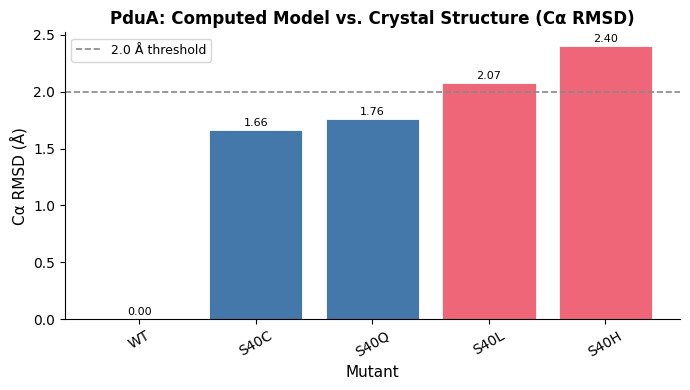

Comparing 5 mutant(s) to crystal structures …
  S40C       vs /Users/matthew/Desktop/Pdu_PyRosetta/4QIG_fixed.pdb  RMSD =  0.278 Å  (20 N atoms, residues 38-42)
  S40H       vs /Users/matthew/Desktop/Pdu_PyRosetta/4QIF_fixed.pdb  RMSD =  0.077 Å  (20 N atoms, residues 38-42)
  S40L       vs /Users/matthew/Desktop/Pdu_PyRosetta/4RBT_fixed.pdb  RMSD =  0.135 Å  (20 N atoms, residues 38-42)
  S40Q       vs /Users/matthew/Desktop/Pdu_PyRosetta/4RBU_fixed.pdb  RMSD =  0.180 Å  (20 N atoms, residues 38-42)
  WT         vs /Users/matthew/Desktop/Pdu_PyRosetta/3NGK_fixed.pdb  RMSD =  0.000 Å  (20 N atoms, residues 38-42)

Pore-focused crystal RMSD (residues 38-42):


,mutant_label,crystal_label,rmsd_A,n_atoms,computed_pdb,crystal_pdb
0,S40C,/Users/matthew/Desktop/Pdu_PyRosetta/4QIG_fixe...,0.278,20,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/4QIG_fixe...
1,S40H,/Users/matthew/Desktop/Pdu_PyRosetta/4QIF_fixe...,0.077,20,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/4QIF_fixe...
2,S40L,/Users/matthew/Desktop/Pdu_PyRosetta/4RBT_fixe...,0.135,20,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/4RBT_fixe...
3,S40Q,/Users/matthew/Desktop/Pdu_PyRosetta/4RBU_fixe...,0.180,20,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/4RBU_fixe...
4,WT,/Users/matthew/Desktop/Pdu_PyRosetta/3NGK_fixe...,0.000,20,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/3NGK_fixe...



  SPEARMAN: computed ddG vs. Chowdhury 2014 experimental

Spearman correlation: computed ddG vs. ddG_exp_kcal_mol
  n pairs  : 5
  r        : -0.600
  p-value  : 0.2848

Per-mutant comparison (top-10 poses averaged):
mutant  mean_dG_REU  ddG_computed_REU  ddG_exp_kcal_mol
  S40A       -5.291            -1.253            -2.100
  S40H       -5.518            -1.480             1.500
  S40L       -6.058            -2.020             4.700
  S40Q       -4.957            -0.918            -0.200
    WT       -4.038             0.000             0.000
  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/spearman_ddG.png


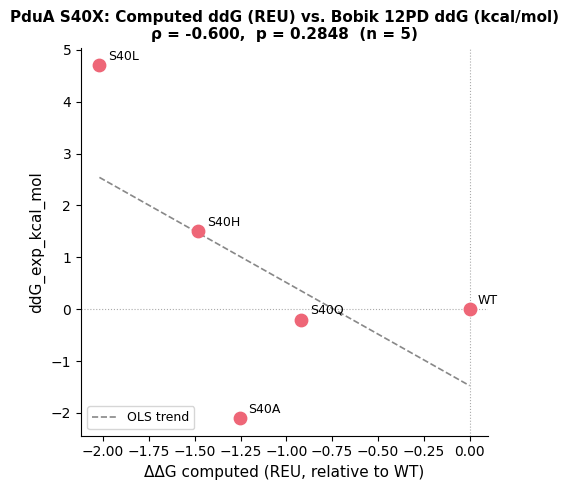


Spearman correlation: computed ddG vs. pore_diameter
  n pairs  : 6
  r        : +0.086
  p-value  : 0.8717

Per-mutant comparison (top-10 poses averaged):
mutant  mean_dG_REU  ddG_computed_REU  pore_diameter
  S40A       -5.291            -1.253          5.900
  S40C       -5.395            -1.357          2.600
  S40H       -5.518            -1.480          4.300
  S40L       -6.058            -2.020          5.500
  S40Q       -4.957            -0.918          0.500
    WT       -4.038             0.000          5.600
  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/spearman_pore_diameter.png


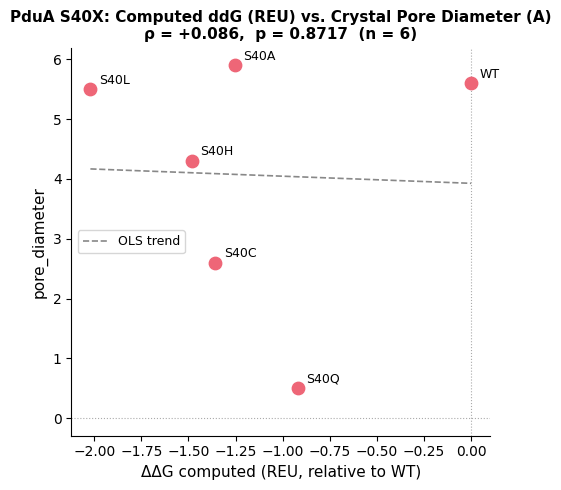


Spearman correlation: computed ddG vs. PduD_activity
  n pairs  : 9
  r        : -0.300
  p-value  : 0.4328

Per-mutant comparison (top-10 poses averaged):
mutant  mean_dG_REU  ddG_computed_REU  PduD_activity
  S40A       -5.291            -1.253         26.100
  S40C       -5.395            -1.357         27.100
  S40H       -5.518            -1.480         28.500
  S40L       -6.058            -2.020         14.800
  S40M       -6.864            -2.826         29.200
  S40N       -6.098            -2.060         27.800
  S40Q       -4.957            -0.918         21.200
  S40T       -5.658            -1.620         29.400
    WT       -4.038             0.000         28.400
  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/spearman_PduD_activity.png


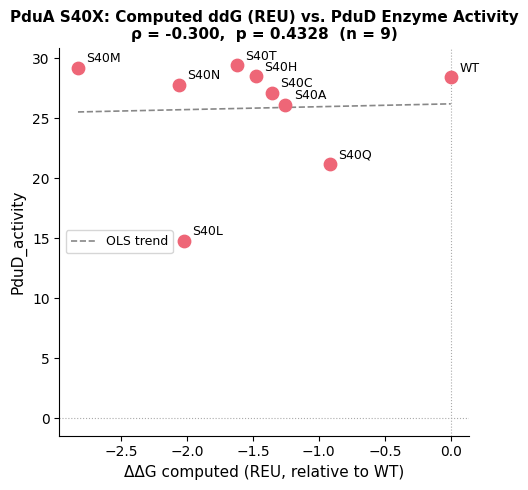


Interpretation note:
  r > 0 -> computed ranks variants same direction as experiment
  r < 0 -> inverted (check sign convention: interface_energy < 0 for binding)
  Small n (<=6) limits p-value significance; use r for cross-validation ranking.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CALL 1 — Computed models vs. crystal structures (validation)
#
# Only the 5 pairs listed in the notebook header are compared:
#   WT (3NGK), S40L (4RBT), S40H (4QIF), S40C (4QIG), S40Q (4RBU)
#
# Kabsch superimposition removes crystal-lattice translation/rotation before
# RMSD is measured, so only true structural differences contribute.
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 60)
print('  COMPUTED vs. CRYSTAL RMSD')
print('=' * 60)

# Discover all mutant PDBs once — reused by later cells
all_mutant_pdbs = discover_mutant_pdbs(MUTANT_DIR, pattern='*.pdb')

# ── Crystal validation (ONLY the 5 solved crystal structures) ─────────────
df_crystal = batch_compare_to_crystals(
    mutant_pdb_map  = COMPUTED_CRYSTAL_MAP,  # computed: WT, S40L, S40H, S40C, S40Q
    crystal_pdb_map = CRYSTAL_PDB_MAP,       # crystal:  3NGK, 4RBT, 4QIF, 4QIG, 4RBU
    computed_chain  = CHAIN,
    crystal_chain   = CHAIN,
    pdb_res_range   = None,                  # full chain
    atom_names      = ATOM_NAMES,
    fix_computed    = FIX_CHAINS,
    fix_crystal     = FIX_CHAINS,
)
display(df_crystal.round(3))
df_crystal.to_csv(os.path.join(OUT_DIR, 'rmsd_computed_vs_crystal.csv'), index=False)

fig_crys = plot_crystal_comparison(
    df_crystal,
    title     = 'PduA: Computed Model vs. Crystal Structure (Cα RMSD)',
    save_path = os.path.join(OUT_DIR, 'rmsd_crystal_vs_computed.png'),
)
plt.show()

# ── Pore-focused crystal validation ──────────────────────────────────────
df_crystal_pore = batch_compare_to_crystals(
    mutant_pdb_map  = COMPUTED_CRYSTAL_MAP,
    crystal_pdb_map = CRYSTAL_PDB_MAP,
    computed_chain  = CHAIN,
    crystal_chain   = CHAIN,
    pdb_res_range   = PORE_RANGE,
    atom_names      = ('N', 'CA', 'C', 'O'),
    fix_computed    = FIX_CHAINS,
    fix_crystal     = FIX_CHAINS,
)
print('\nPore-focused crystal RMSD (residues 38-42):')
display(df_crystal_pore.round(3))
df_crystal_pore.to_csv(os.path.join(OUT_DIR, 'rmsd_computed_vs_crystal_pore.csv'), index=False)

# ── Build combined docking CSV if needed ─────────────────────────────────
COMBINED_CSV = os.path.join(OUT_DIR, 'all_docking_scores.csv')

if not os.path.exists(COMBINED_CSV):
    frames = []
    for d in sorted(glob.glob(os.path.join(DOCKING_ROOT, '*/docking_scores.csv'))):
        frames.append(pd.read_csv(d))
    if frames:
        combined = pd.concat(frames, ignore_index=True)
        combined.to_csv(COMBINED_CSV, index=False)
        print(f'  Created combined CSV: {COMBINED_CSV}  ({len(combined)} rows)')
    else:
        print(f'  WARNING: no docking_scores.csv files found under {DOCKING_ROOT}')

# ── Spearman: computed ddG vs. Chowdhury 2014 (S40 crystal pairs only) ───
if os.path.exists(COMBINED_CSV):
    print('\n' + '=' * 60)
    print('  SPEARMAN: computed ddG vs. Chowdhury 2014 experimental')
    print('=' * 60)

    # Run Spearman for each available experimental column in LITERATURE_DDG.
    # Each correlation is saved independently; low n warns but doesn't crash.
    spearman_runs = [
        ('ddG_exp_kcal_mol', 'interface_energy',
         'Computed ddG (REU) vs. Bobik 12PD ddG (kcal/mol)',
         'spearman_ddG.png'),
        ('pore_diameter',    'interface_energy',
         'Computed ddG (REU) vs. Crystal Pore Diameter (A)',
         'spearman_pore_diameter.png'),
        ('PduD_activity',    'interface_energy',
         'Computed ddG (REU) vs. PduD Enzyme Activity',
         'spearman_PduD_activity.png'),
    ]

    for exp_col, comp_col, sp_title, sp_fname in spearman_runs:
        try:
            sp_result = spearman_vs_literature(
                computed_csv = COMBINED_CSV,
                lit_ddg      = LITERATURE_DDG,
                computed_col = comp_col,
                exp_col      = exp_col,
                mutant_col   = 'mutant',
                wt_label     = 'WT',
                n_top        = 10,
                site         = 'S40',
            )
            sp_result['merged_df'].to_csv(
                os.path.join(OUT_DIR, f'spearman_{exp_col}.csv'), index=False
            )
            fig_sp = plot_spearman(
                sp_result,
                title     = f'PduA S40X: {sp_title}',
                save_path = os.path.join(OUT_DIR, sp_fname),
            )
            plt.show()
        except ValueError as e:
            print(f'  Skipping {exp_col}: {e}')

    print('\nInterpretation note:')
    print('  r > 0 -> computed ranks variants same direction as experiment')
    print('  r < 0 -> inverted (check sign convention: interface_energy < 0 for binding)')
    print('  Small n (<=6) limits p-value significance; use r for cross-validation ranking.')
else:
    print('Skipped - no docking CSV available.')


## Cell 11 — Call 2: All Generated Mutants vs. Wildtype

  PORE SIDECHAIN DISPLACEMENT vs. WILDTYPE
Comparing 5 mutant(s) to crystal structures …
  S40C       vs /Users/matthew/Desktop/Pdu_PyRosetta/4QIG_fixed.pdb  RMSD =  0.278 Å  (20 N atoms, residues 38-42)
  S40H       vs /Users/matthew/Desktop/Pdu_PyRosetta/4QIF_fixed.pdb  RMSD =  0.077 Å  (20 N atoms, residues 38-42)
  S40L       vs /Users/matthew/Desktop/Pdu_PyRosetta/4RBT_fixed.pdb  RMSD =  0.135 Å  (20 N atoms, residues 38-42)
  S40Q       vs /Users/matthew/Desktop/Pdu_PyRosetta/4RBU_fixed.pdb  RMSD =  0.180 Å  (20 N atoms, residues 38-42)
  WT         vs /Users/matthew/Desktop/Pdu_PyRosetta/3NGK_fixed.pdb  RMSD =  0.000 Å  (20 N atoms, residues 38-42)

Pore-focused crystal RMSD (residues 38-42):


,mutant_label,crystal_label,rmsd_A,n_atoms,computed_pdb,crystal_pdb
0,S40C,/Users/matthew/Desktop/Pdu_PyRosetta/4QIG_fixe...,0.278,20,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/4QIG_fixe...
1,S40H,/Users/matthew/Desktop/Pdu_PyRosetta/4QIF_fixe...,0.077,20,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/4QIF_fixe...
2,S40L,/Users/matthew/Desktop/Pdu_PyRosetta/4RBT_fixe...,0.135,20,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/4RBT_fixe...
3,S40Q,/Users/matthew/Desktop/Pdu_PyRosetta/4RBU_fixe...,0.180,20,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/4RBU_fixe...
4,WT,/Users/matthew/Desktop/Pdu_PyRosetta/3NGK_fixe...,0.000,20,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/3NGK_fixe...



  PORE GEOMETRY — S40 VARIANTS (PDB residue 40)
Loading WT reference: /Users/matthew/Desktop/Pdu_PyRosetta/3NGK_fixed.pdb
  S40A_3NGK        pore_d=6.79 Å  pore_r=3.39 Å  cb_dev=0.018 Å
  S40C_3NGK        pore_d=6.85 Å  pore_r=3.42 Å  cb_dev=0.042 Å
  S40D_3NGK        pore_d=4.32 Å  pore_r=2.16 Å  cb_dev=0.030 Å
  S40E_3NGK        pore_d=6.08 Å  pore_r=3.04 Å  cb_dev=0.028 Å
  S40F_3NGK        pore_d=4.94 Å  pore_r=2.47 Å  cb_dev=0.033 Å
  S40G_3NGK        pore_d=6.00 Å  pore_r=3.00 Å  cb_dev=0.000 Å
  S40H_3NGK        pore_d=3.89 Å  pore_r=1.94 Å  cb_dev=0.027 Å
  S40I_3NGK        pore_d=4.41 Å  pore_r=2.21 Å  cb_dev=0.031 Å
  S40K_3NGK        pore_d=4.36 Å  pore_r=2.18 Å  cb_dev=0.018 Å
  S40L_3NGK        pore_d=5.14 Å  pore_r=2.57 Å  cb_dev=0.037 Å
  S40M_3NGK        pore_d=4.85 Å  pore_r=2.42 Å  cb_dev=0.018 Å
  S40N_3NGK        pore_d=3.62 Å  pore_r=1.81 Å  cb_dev=0.015 Å
  S40P_3NGK        pore_d=6.49 Å  pore_r=3.24 Å  cb_dev=0.225 Å
  S40Q_3NGK        pore_d=6.00 Å  pore_r=3.00

,mutant,residue_name,pore_diameter_A,pore_radius_A,sidechain_volume_A3,mean_cb_distance_A,cb_centroid_dev_A,n_chains,pdb_path
0,S40N_3NGK,ASN,3.619,1.810,678.0,5.081,0.015,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...
1,S40H_3NGK,HIS,3.887,1.944,918.0,5.112,0.027,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...
2,S40W_3NGK,TRP,4.262,2.131,978.0,5.118,0.036,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...
3,S40D_3NGK,ASP,4.320,2.160,666.0,5.114,0.030,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...
4,S40Y_3NGK,TYR,4.328,2.164,846.0,5.098,0.014,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...
5,S40K_3NGK,LYS,4.358,2.179,810.0,5.102,0.018,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...
6,S40I_3NGK,ILE,4.414,2.207,744.0,5.117,0.031,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...
7,S40M_3NGK,MET,4.848,2.424,744.0,5.097,0.018,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...
8,S40F_3NGK,PHE,4.943,2.472,810.0,5.116,0.033,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...
9,S40L_3NGK,LEU,5.139,2.570,744.0,5.120,0.037,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...



  CRYSTAL PORE GEOMETRY — S40 VARIANTS (PDB resseq 40)
  S40C      crystal pore_d=2.22 Å  (CYS | chain A SG ↔ chain F SG)
  S40H      crystal pore_d=2.99 Å  (HIS | chain A CE1 ↔ chain D CE1)
  S40L      crystal pore_d=3.56 Å  (LEU | chain A CD1 ↔ chain D CD1)
  S40Q      crystal pore_d=0.00 Å  (GLN | chain C OE1 ↔ chain F NE2)
  WT        crystal pore_d=6.77 Å  (SER | chain A CB ↔ chain D CB)


,mutant,residue_name,pore_diameter_A,pore_radius_A,chain_a,chain_b,atom_a,atom_b,n_chains,pdb_path
0,S40Q,GLN,0.000,0.000,C,F,OE1,NE2,6,/Users/matthew/Desktop/Pdu_PyRosetta/4RBU_fixe...
1,S40C,CYS,2.222,1.111,A,F,SG,SG,6,/Users/matthew/Desktop/Pdu_PyRosetta/4QIG_fixe...
2,S40H,HIS,2.991,1.496,A,D,CE1,CE1,6,/Users/matthew/Desktop/Pdu_PyRosetta/4QIF_fixe...
3,S40L,LEU,3.558,1.779,A,D,CD1,CD1,4,/Users/matthew/Desktop/Pdu_PyRosetta/4RBT_fixe...
4,WT,SER,6.773,3.386,A,D,CB,CB,6,/Users/matthew/Desktop/Pdu_PyRosetta/3NGK_fixe...


  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/pore_diameter_3way_S40.png


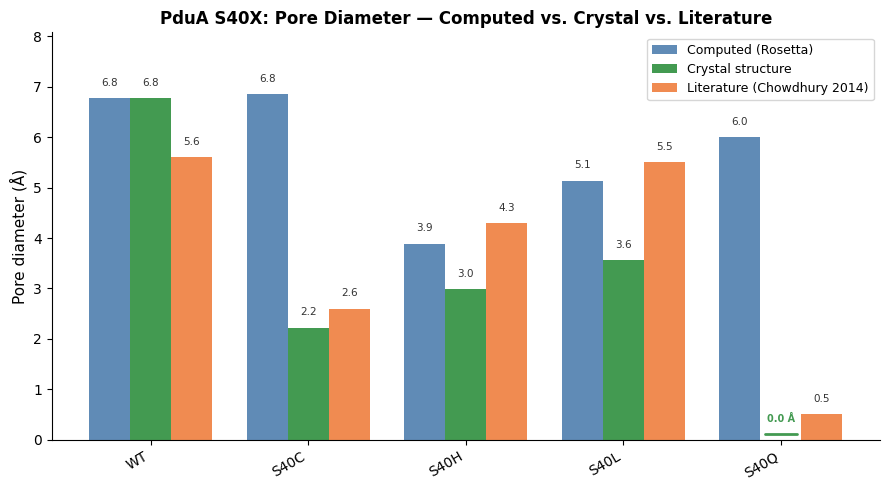

  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/pore_geo_S40_pore_radius_A.png


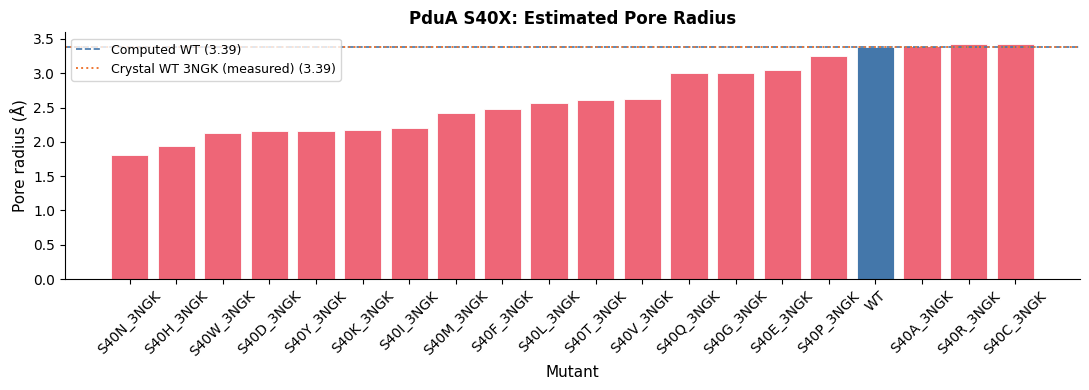

  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/pore_geo_S40_sidechain_volume_A3.png


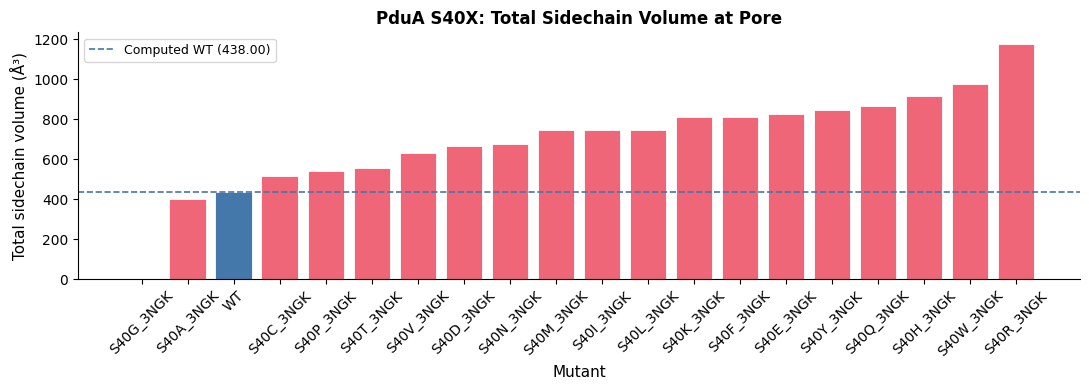

  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/pore_geo_S40_cb_centroid_dev_A.png


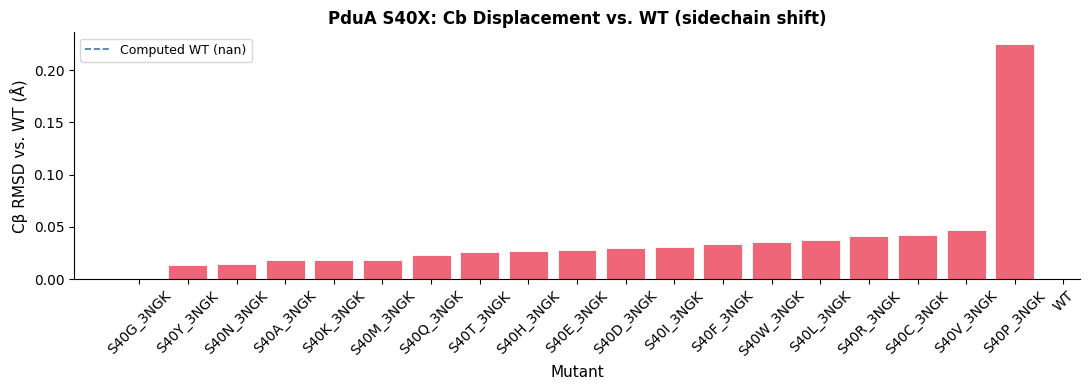


  PORE GEOMETRY — K37 VARIANTS (PDB residue 37)
Loading WT reference: /Users/matthew/Desktop/Pdu_PyRosetta/3NGK_fixed.pdb
  K37A_3NGK        pore_d=6.47 Å  pore_r=3.23 Å  cb_dev=0.038 Å
  K37C_3NGK        pore_d=6.47 Å  pore_r=3.23 Å  cb_dev=0.038 Å
  K37D_3NGK        pore_d=6.48 Å  pore_r=3.24 Å  cb_dev=0.038 Å
  K37E_3NGK        pore_d=6.49 Å  pore_r=3.24 Å  cb_dev=0.038 Å
  K37F_3NGK        pore_d=6.54 Å  pore_r=3.27 Å  cb_dev=0.038 Å
  K37G_3NGK        pore_d=6.47 Å  pore_r=3.23 Å  cb_dev=0.038 Å
  K37H_3NGK        pore_d=6.54 Å  pore_r=3.27 Å  cb_dev=0.038 Å
  K37I_3NGK        pore_d=6.51 Å  pore_r=3.26 Å  cb_dev=0.038 Å
  K37L_3NGK        pore_d=6.53 Å  pore_r=3.26 Å  cb_dev=0.038 Å
  K37M_3NGK        pore_d=6.50 Å  pore_r=3.25 Å  cb_dev=0.038 Å
  K37N_3NGK        pore_d=6.55 Å  pore_r=3.28 Å  cb_dev=0.038 Å
  K37P_3NGK        pore_d=6.49 Å  pore_r=3.25 Å  cb_dev=0.038 Å
  K37Q_3NGK        pore_d=6.51 Å  pore_r=3.25 Å  cb_dev=0.038 Å
  K37R_3NGK        pore_d=6.49 Å  pore_r=3.24

,mutant,residue_name,pore_diameter_A,pore_radius_A,sidechain_volume_A3,mean_cb_distance_A,cb_centroid_dev_A,n_chains,pdb_path
0,K37T_3NGK,SER,6.462,3.231,438.0,5.111,0.038,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...
1,K37G_3NGK,SER,6.468,3.234,438.0,5.111,0.038,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...
2,K37A_3NGK,SER,6.470,3.235,438.0,5.111,0.038,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...
3,K37C_3NGK,SER,6.470,3.235,438.0,5.111,0.038,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...
4,K37S_3NGK,SER,6.470,3.235,438.0,5.111,0.038,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...
5,K37D_3NGK,SER,6.477,3.238,438.0,5.111,0.038,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...
6,K37W_3NGK,SER,6.480,3.240,438.0,5.111,0.038,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...
7,K37R_3NGK,SER,6.488,3.244,438.0,5.111,0.038,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...
8,K37E_3NGK,SER,6.489,3.244,438.0,5.111,0.038,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...
9,K37P_3NGK,SER,6.494,3.247,438.0,5.111,0.038,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...



  CRYSTAL PORE GEOMETRY — K37 SITE (measuring S40 pore at rank 37)
  WT        crystal pore_d=6.77 Å  (SER | chain A CB ↔ chain D CB)


,mutant,residue_name,pore_diameter_A,pore_radius_A,chain_a,chain_b,atom_a,atom_b,n_chains,pdb_path
0,WT,SER,6.773,3.386,A,D,CB,CB,6,/Users/matthew/Desktop/Pdu_PyRosetta/3NGK_fixe...


  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/pore_geo_K37_pore_radius_A.png


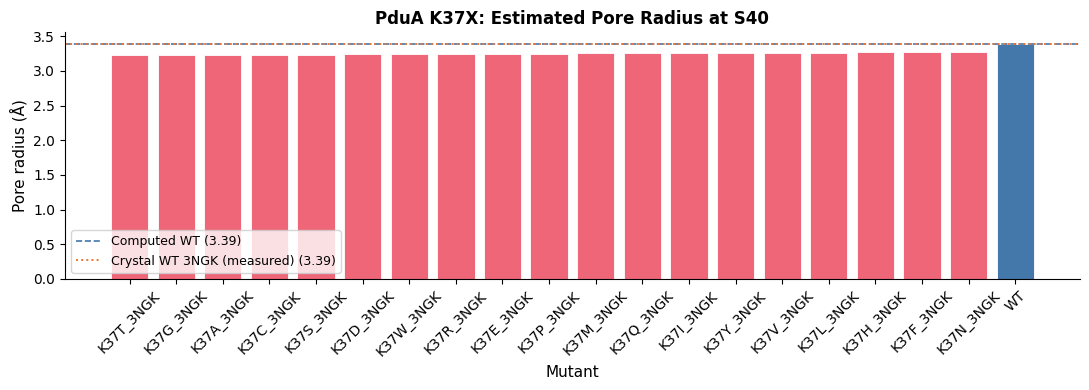

  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/pore_geo_K37_sidechain_volume_A3.png


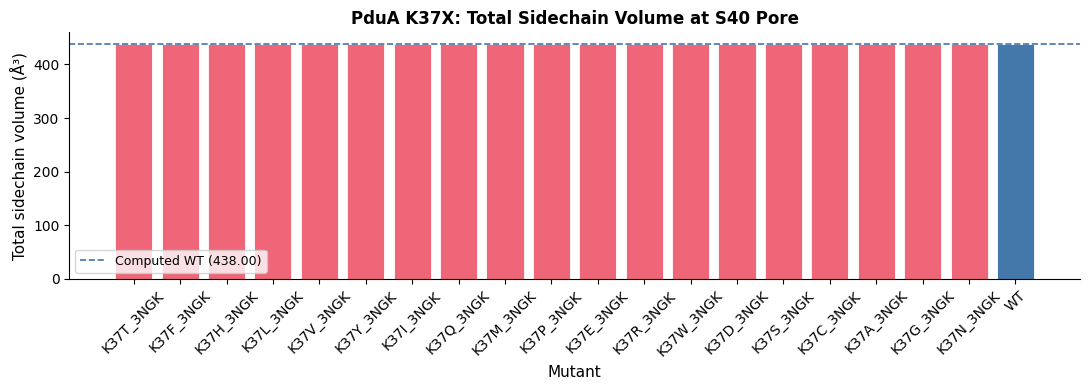

  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/pore_geo_K37_cb_centroid_dev_A.png


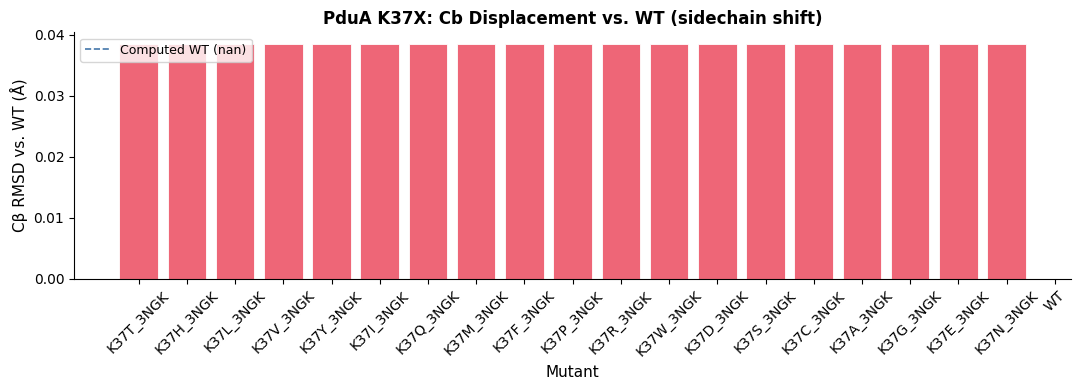


S40 variants — Cb displacement at pore residue 40:


,mutant,residue_name,pore_radius_A,sidechain_volume_A3,cb_centroid_dev_A
0,S40N_3NGK,ASN,1.810,678.0,0.015
1,S40H_3NGK,HIS,1.944,918.0,0.027
2,S40W_3NGK,TRP,2.131,978.0,0.036
3,S40D_3NGK,ASP,2.160,666.0,0.030
4,S40Y_3NGK,TYR,2.164,846.0,0.014
5,S40K_3NGK,LYS,2.179,810.0,0.018
6,S40I_3NGK,ILE,2.207,744.0,0.031
7,S40M_3NGK,MET,2.424,744.0,0.018
8,S40F_3NGK,PHE,2.472,810.0,0.033
9,S40L_3NGK,LEU,2.570,744.0,0.037


  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/cb_dev_S40.png


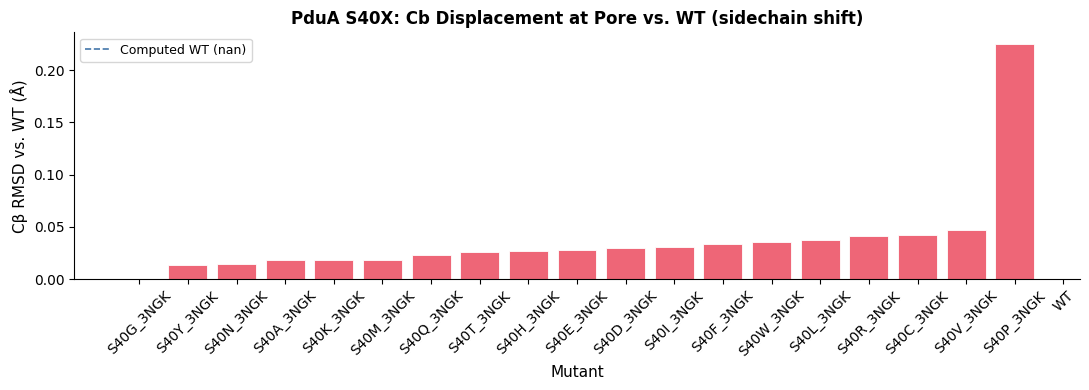

  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/pore_radius_S40.png


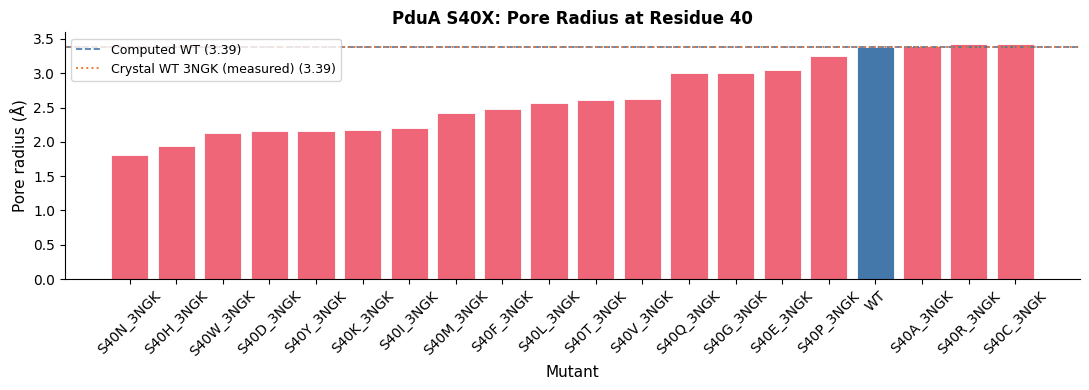


K37 variants — Cb displacement at pore residue 37:


,mutant,residue_name,pore_radius_A,sidechain_volume_A3,cb_centroid_dev_A
0,K37T_3NGK,SER,3.231,438.0,0.038
1,K37G_3NGK,SER,3.234,438.0,0.038
2,K37A_3NGK,SER,3.235,438.0,0.038
3,K37C_3NGK,SER,3.235,438.0,0.038
4,K37S_3NGK,SER,3.235,438.0,0.038
5,K37D_3NGK,SER,3.238,438.0,0.038
6,K37W_3NGK,SER,3.240,438.0,0.038
7,K37R_3NGK,SER,3.244,438.0,0.038
8,K37E_3NGK,SER,3.244,438.0,0.038
9,K37P_3NGK,SER,3.247,438.0,0.038


  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/cb_dev_K37.png


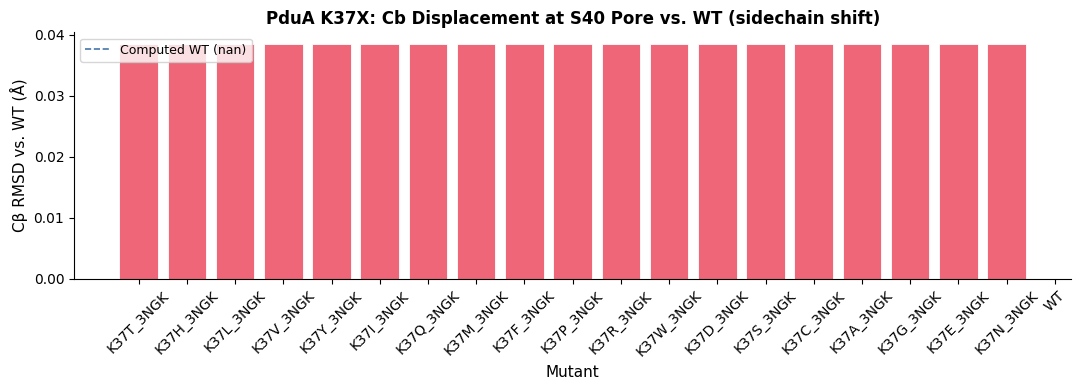

  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/pore_radius_K37.png


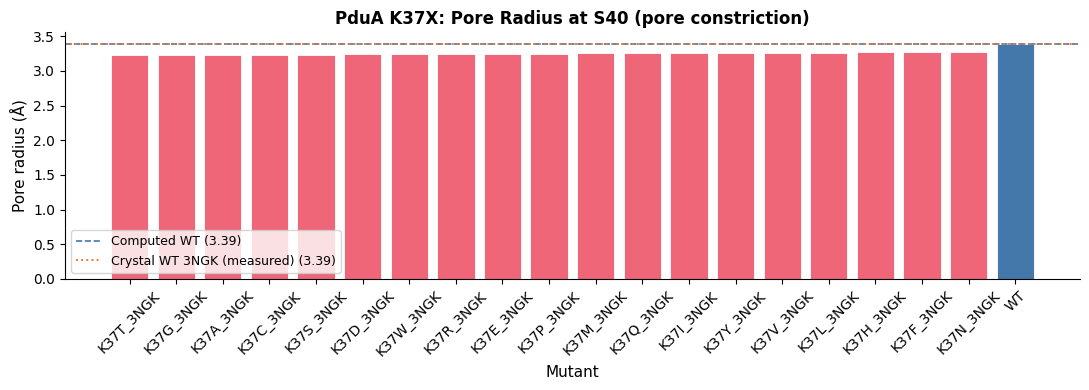

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# CALL 2 — Sidechain displacement vs. wildtype (per site)
#
# Since backbone is frozen during mutagenesis (set_bb=False), Cα RMSD is
# uninformative (all zeros). Instead we use cb_centroid_dev_A from
# batch_pore_geometry, which measures how far the Cβ centroid at the pore
# shifts relative to WT — the meaningful per-residue structural readout.
#
# S40 and K37 variants are kept separate throughout.
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 60)
print('  PORE SIDECHAIN DISPLACEMENT vs. WILDTYPE')
print('=' * 60)

# ── Pore-focused crystal validation ──────────────────────────────────────
df_crystal_pore = batch_compare_to_crystals(
    mutant_pdb_map  = COMPUTED_CRYSTAL_MAP,
    crystal_pdb_map = CRYSTAL_PDB_MAP,
    computed_chain  = CHAIN,
    crystal_chain   = CHAIN,
    pdb_res_range   = PORE_RANGE,
    atom_names      = ('N', 'CA', 'C', 'O'),
    fix_computed    = FIX_CHAINS,
    fix_crystal     = FIX_CHAINS,
)
print('\nPore-focused crystal RMSD (residues 38-42):')
display(df_crystal_pore.round(3))
df_crystal_pore.to_csv(os.path.join(OUT_DIR, 'rmsd_computed_vs_crystal_pore.csv'), index=False)

# ── Pore geometry — S40 variants ONLY ────────────────────────────────────
# Build site-specific maps so K37 and S40 entries don't mix
s40_pdbs = {k: v for k, v in all_mutant_pdbs.items() if k.startswith('S40')}
s40_pdbs['WT'] = WT_PDB

k37_pdbs = {k: v for k, v in all_mutant_pdbs.items() if k.startswith('K37')}
k37_pdbs['WT'] = WT_PDB

print('\n' + '=' * 60)
print('  PORE GEOMETRY — S40 VARIANTS (PDB residue 40)')
print('=' * 60)

df_pore_geo_s40 = batch_pore_geometry(
    pdb_map        = s40_pdbs,
    target_pdb_num = 40,
    wt_key         = 'WT',
    fix_chains     = FIX_CHAINS,
)
display(df_pore_geo_s40.round(3))
df_pore_geo_s40.to_csv(os.path.join(OUT_DIR, 'pore_geometry_S40.csv'), index=False)

# ── Crystal pore geometry at S40 (direct structural measurement) ──────────
print('\n' + '=' * 60)
print('  CRYSTAL PORE GEOMETRY — S40 VARIANTS (PDB resseq 40)')
print('=' * 60)
df_crystal_pore_s40 = batch_crystal_pore_geometry(
    crystal_pdb_map = CRYSTAL_PDB_MAP,
    target_resseq   = 40,   # absolute RCSB resseq 40 = S40 in all crystal structures
)
display(df_crystal_pore_s40.round(3))
df_crystal_pore_s40.to_csv(os.path.join(OUT_DIR, 'crystal_pore_geometry_S40.csv'), index=False)

# Three-way comparison: Computed vs Crystal vs Literature
fig_3way_s40 = plot_pore_diameter_comparison(
    df_computed  = df_pore_geo_s40,
    df_crystal   = df_crystal_pore_s40,
    lit_ddg      = LITERATURE_DDG,
    lit_diam_key = 'pore_diameter',
    title        = 'PduA S40X: Pore Diameter — Computed vs. Crystal vs. Literature',
    save_path    = os.path.join(OUT_DIR, 'pore_diameter_3way_S40.png'),
)
plt.show()

# Crystal pore_radius from the measured 3NGK structure (not literature / 2)
_crystal_wt_pore_r_s40 = (
    float(df_crystal_pore_s40.loc[df_crystal_pore_s40['mutant'] == 'WT', 'pore_radius_A'].iloc[0])
    if 'WT' in df_crystal_pore_s40['mutant'].values else
    LITERATURE_DDG['WT']['pore_diameter'] / 2.0
)

for metric, title, crystal_ref_val, crystal_ref_label in [
    ('pore_radius_A',       'PduA S40X: Estimated Pore Radius',
     _crystal_wt_pore_r_s40, 'Crystal WT 3NGK (measured)'),
    ('sidechain_volume_A3', 'PduA S40X: Total Sidechain Volume at Pore',
     None, ''),
    ('cb_centroid_dev_A',   'PduA S40X: Cb Displacement vs. WT (sidechain shift)',
     None, ''),
]:
    fig = plot_pore_geometry(
        df_pore_geo_s40,
        metric            = metric,
        title             = title,
        wt_key            = 'WT',
        crystal_ref_val   = crystal_ref_val,
        crystal_ref_label = crystal_ref_label,
        save_path         = os.path.join(OUT_DIR, f'pore_geo_S40_{metric}.png'),
    )
    plt.show()

# ── Pore geometry — K37 variants ONLY ────────────────────────────────────
print('\n' + '=' * 60)
print('  PORE GEOMETRY — K37 VARIANTS (PDB residue 37)')
print('=' * 60)

df_pore_geo_k37 = batch_pore_geometry(
    pdb_map        = k37_pdbs,
    target_pdb_num = 40,   # measure S40 pore (actual constriction) not K37 position
    wt_key         = 'WT',
    fix_chains     = FIX_CHAINS,
)
display(df_pore_geo_k37.round(3))
df_pore_geo_k37.to_csv(os.path.join(OUT_DIR, 'pore_geometry_K37.csv'), index=False)

# ── Crystal pore geometry at K37 (direct structural measurement) ──────────
print('\n' + '=' * 60)
print('  CRYSTAL PORE GEOMETRY — K37 SITE (measuring S40 pore at rank 37)')
print('=' * 60)
_k37_crystal_map = {'WT': CRYSTAL_PDB_MAP['WT']}   # only 3NGK has K37 data
df_crystal_pore_k37 = batch_crystal_pore_geometry(
    crystal_pdb_map = _k37_crystal_map,
    target_resseq   = 40,   # absolute RCSB resseq 40 = S40 pore constriction
)
display(df_crystal_pore_k37.round(3))
df_crystal_pore_k37.to_csv(os.path.join(OUT_DIR, 'crystal_pore_geometry_K37.csv'), index=False)

_crystal_wt_pore_r_k37 = (
    float(df_crystal_pore_k37.loc[df_crystal_pore_k37['mutant'] == 'WT', 'pore_radius_A'].iloc[0])
    if 'WT' in df_crystal_pore_k37['mutant'].values else float('nan')
)

for metric, title, crystal_ref_val, crystal_ref_label in [
    ('pore_radius_A',       'PduA K37X: Estimated Pore Radius at S40',
     _crystal_wt_pore_r_k37, 'Crystal WT 3NGK (measured)'),
    ('sidechain_volume_A3', 'PduA K37X: Total Sidechain Volume at S40 Pore',
     None, ''),
    ('cb_centroid_dev_A',   'PduA K37X: Cb Displacement vs. WT (sidechain shift)',
     None, ''),
]:
    fig = plot_pore_geometry(
        df_pore_geo_k37,
        metric            = metric,
        title             = title,
        wt_key            = 'WT',
        crystal_ref_val   = crystal_ref_val,
        crystal_ref_label = crystal_ref_label,
        save_path         = os.path.join(OUT_DIR, f'pore_geo_K37_{metric}.png'),
    )
    plt.show()

DOCKING_ROOT = os.path.join(HOME, 'PduA_docking_mutants')

# ── Build combined docking CSV if needed ─────────────────────────────────
COMBINED_CSV = os.path.join(OUT_DIR, 'all_docking_scores.csv')

if not os.path.exists(COMBINED_CSV):
    frames = []
    for d in sorted(glob.glob(os.path.join(DOCKING_ROOT, '*/docking_scores.csv'))):
        frames.append(pd.read_csv(d))
    if frames:
        combined = pd.concat(frames, ignore_index=True)
        combined.to_csv(COMBINED_CSV, index=False)
        print(f'  Created combined CSV: {COMBINED_CSV}  ({len(combined)} rows)')
    else:
        print(f'  WARNING: no docking_scores.csv files found under {DOCKING_ROOT}')

# Partition discovered PDBs by site (s40_pdbs and k37_pdbs already built in Cell 10)
# Partition the full library for use in later cells too
s40_mutant_pdbs = {k: v for k, v in all_mutant_pdbs.items() if k.startswith('S40')}
k37_mutant_pdbs = {k: v for k, v in all_mutant_pdbs.items() if k.startswith('K37')}

# ── S40: plot cb_centroid_dev_A from pore geometry ─────────────────────────
print('\nS40 variants — Cb displacement at pore residue 40:')
display(df_pore_geo_s40[['mutant', 'residue_name', 'pore_radius_A',
                          'sidechain_volume_A3', 'cb_centroid_dev_A']].round(3))

fig_cb_s40 = plot_pore_geometry(
    df_pore_geo_s40,
    metric    = 'cb_centroid_dev_A',
    title     = 'PduA S40X: Cb Displacement at Pore vs. WT (sidechain shift)',
    wt_key    = 'WT',
    save_path = os.path.join(OUT_DIR, 'cb_dev_S40.png'),
)
plt.show()

# Also plot pore radius with measured crystal reference line
fig_pr_s40 = plot_pore_geometry(
    df_pore_geo_s40,
    metric            = 'pore_radius_A',
    title             = 'PduA S40X: Pore Radius at Residue 40',
    wt_key            = 'WT',
    crystal_ref_val   = _crystal_wt_pore_r_s40,
    crystal_ref_label = 'Crystal WT 3NGK (measured)',
    save_path         = os.path.join(OUT_DIR, 'pore_radius_S40.png'),
)
plt.show()

# ── K37: plot cb_centroid_dev_A from pore geometry ─────────────────────────
print('\nK37 variants — Cb displacement at pore residue 37:')
display(df_pore_geo_k37[['mutant', 'residue_name', 'pore_radius_A',
                          'sidechain_volume_A3', 'cb_centroid_dev_A']].round(3))

fig_cb_k37 = plot_pore_geometry(
    df_pore_geo_k37,
    metric    = 'cb_centroid_dev_A',
    title     = 'PduA K37X: Cb Displacement at S40 Pore vs. WT (sidechain shift)',
    wt_key    = 'WT',
    save_path = os.path.join(OUT_DIR, 'cb_dev_K37.png'),
)
plt.show()

fig_pr_k37 = plot_pore_geometry(
    df_pore_geo_k37,
    metric            = 'pore_radius_A',
    title             = 'PduA K37X: Pore Radius at S40 (pore constriction)',
    wt_key            = 'WT',
    crystal_ref_val   = _crystal_wt_pore_r_k37,
    crystal_ref_label = 'Crystal WT 3NGK (measured)',
    save_path         = os.path.join(OUT_DIR, 'pore_radius_K37.png'),
)
plt.show()


## Cell 12 — Call 3: Bound vs. Unbound Conformational Shift

  BOUND vs. UNBOUND CONFORMATIONAL SHIFT
NOTE: Full-chain RMSD = 0 for backbone (frozen). CB selection captures sidechain shift.

S40 variants — CB RMSD:
  Located best-pose files for 20/20 mutants
Comparing bound vs. unbound for 20 mutants ...
  S40A             full RMSD =  8.336 Å  pore RMSD =  0.993 Å (2 atoms)
  S40C             full RMSD =  8.336 Å  pore RMSD =  1.008 Å (2 atoms)
  S40D             full RMSD =  8.335 Å  pore RMSD =  1.002 Å (2 atoms)
  S40E             full RMSD =  8.336 Å  pore RMSD =  1.001 Å (2 atoms)
  S40F             full RMSD =  8.336 Å  pore RMSD =  1.003 Å (2 atoms)
  S40G             full RMSD =  8.286 Å  pore RMSD =  0.000 Å (1 atoms)
  S40H             full RMSD =  8.336 Å  pore RMSD =  1.000 Å (2 atoms)
  S40I             full RMSD =  8.336 Å  pore RMSD =  1.001 Å (2 atoms)
  S40K             full RMSD =  8.336 Å  pore RMSD =  0.996 Å (2 atoms)
  S40L             full RMSD =  8.336 Å  pore RMSD =  1.005 Å (2 atoms)
  S40M             full RMSD =  8.3

,mutant_label,full_rmsd_A,pore_rmsd_A,n_full,n_pore,unbound_pdb,bound_pdb
0,S40G,8.286,0.000,66,1,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_dock...
1,S40P,8.331,1.048,68,2,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_dock...
2,WT,8.334,0.980,68,2,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_dock...
3,S40R,8.334,1.006,68,2,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_dock...
4,S40V,8.335,1.010,68,2,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_dock...
5,S40D,8.335,1.002,68,2,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_dock...
6,S40W,8.336,1.004,68,2,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_dock...
7,S40C,8.336,1.008,68,2,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_dock...
8,S40L,8.336,1.005,68,2,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_dock...
9,S40F,8.336,1.003,68,2,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_dock...


  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/bound_vs_unbound_CB_S40.png


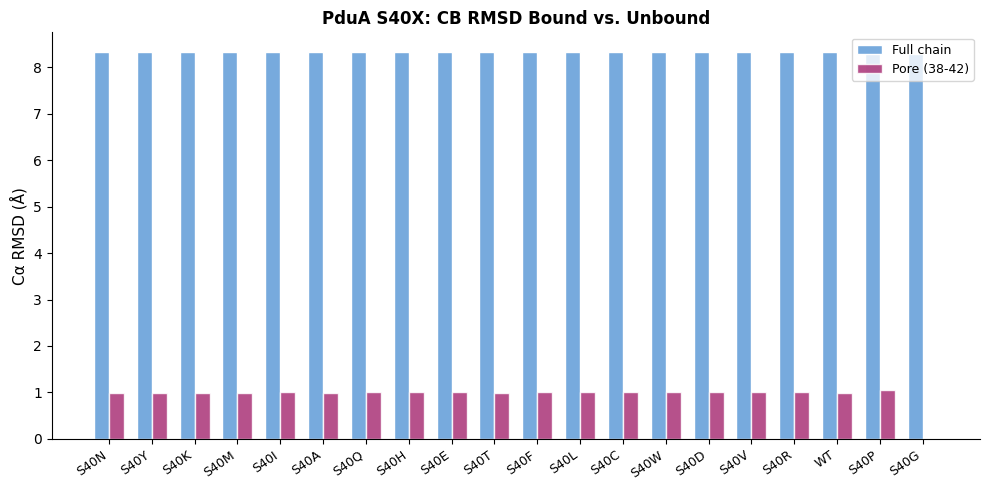


K37 variants — CB RMSD (pore_range centred on residue 37):
  Located best-pose files for 19/19 mutants
Comparing bound vs. unbound for 19 mutants ...
  K37A             full RMSD =  8.335 Å  pore RMSD =  0.023 Å (2 atoms)
  K37C             full RMSD =  8.335 Å  pore RMSD =  0.008 Å (2 atoms)
  K37D             full RMSD =  8.335 Å  pore RMSD =  0.013 Å (2 atoms)
  K37E             full RMSD =  8.335 Å  pore RMSD =  0.015 Å (2 atoms)
  K37F             full RMSD =  8.336 Å  pore RMSD =  0.017 Å (2 atoms)
  K37G             full RMSD =  8.291 Å  pore RMSD =  0.000 Å (1 atoms)
  K37H             full RMSD =  8.335 Å  pore RMSD =  0.016 Å (2 atoms)
  K37I             full RMSD =  8.335 Å  pore RMSD =  0.012 Å (2 atoms)
  K37L             full RMSD =  8.336 Å  pore RMSD =  0.018 Å (2 atoms)
  K37M             full RMSD =  8.336 Å  pore RMSD =  0.026 Å (2 atoms)
  K37N             full RMSD =  8.335 Å  pore RMSD =  0.023 Å (2 atoms)
  K37P             full RMSD =  8.339 Å  pore RMSD =  0.0

,mutant_label,full_rmsd_A,pore_rmsd_A,n_full,n_pore,unbound_pdb,bound_pdb
0,K37G,8.291,0.000,67,1,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_dock...
1,K37A,8.335,0.023,68,2,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_dock...
2,K37T,8.335,0.009,68,2,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_dock...
3,K37N,8.335,0.023,68,2,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_dock...
4,K37Q,8.335,0.020,68,2,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_dock...
5,K37C,8.335,0.008,68,2,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_dock...
6,K37S,8.335,0.017,68,2,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_dock...
7,K37D,8.335,0.013,68,2,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_dock...
8,K37E,8.335,0.015,68,2,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_dock...
9,K37V,8.335,0.010,68,2,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduA_dock...


  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/bound_vs_unbound_CB_K37.png


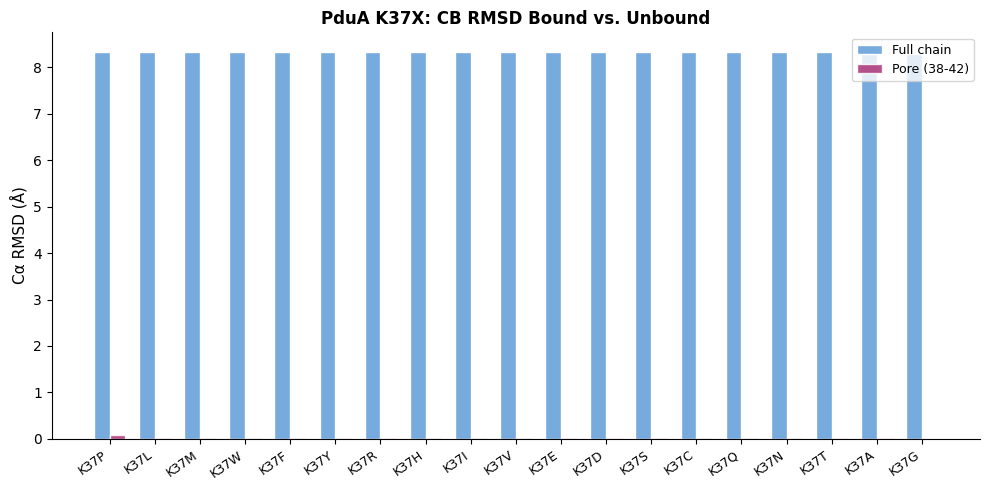


  PORE RADIUS: BOUND vs. UNBOUND
  Located best-pose files for 20/20 mutants
  Located best-pose files for 19/19 mutants
  Located best-pose files for 20/20 mutants

S40 — best bound poses found: 20
K37 — best bound poses found: 19

Measuring pore geometry from S40 bound poses (pure PDB reader):
  S40A      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  S40C      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  S40D      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  S40E      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  S40F      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  S40G      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  S40H      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  S40I      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  S40K      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  S40L      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  

,mutant,pore_r_apo,pore_r_bound,delta_pore_r
0,S40A,10.278,10.278,0.000
1,S40W,10.278,10.278,0.000
2,S40V,10.278,10.278,0.000
3,S40T,10.278,10.278,0.000
4,S40P,10.278,10.278,0.000
5,S40N,10.278,10.278,0.000
6,S40M,10.278,10.278,0.000
7,S40Y,10.278,10.278,0.000
8,S40L,10.278,10.278,0.000
9,S40I,10.278,10.278,0.000



Measuring pore geometry from K37 bound poses (pure PDB reader):
  K37A      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  K37C      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  K37D      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  K37E      crystal pore_d=22.94 Å  (VAL | chain C CB ↔ chain F CB)
  K37F      crystal pore_d=22.94 Å  (VAL | chain C CB ↔ chain F CB)
  K37G      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  K37H      crystal pore_d=22.94 Å  (VAL | chain C CB ↔ chain F CB)
  K37I      crystal pore_d=20.57 Å  (VAL | chain C CG2 ↔ chain F CG2)
  K37L      crystal pore_d=22.94 Å  (VAL | chain C CB ↔ chain F CB)
  K37M      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  K37N      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  K37P      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  K37Q      crystal pore_d=22.94 Å  (VAL | chain C CB ↔ chain F CB)
  K37R      crystal pore_d=22.94 Å 

,mutant,pore_r_apo,pore_r_bound,delta_pore_r
0,K37M,10.277,10.278,0.001
1,K37D,10.277,10.278,0.001
2,K37V,10.278,10.278,0.000
3,K37N,10.278,10.278,-0.001
4,K37C,10.280,10.278,-0.002
5,K37T,10.284,10.287,0.003
6,K37S,10.289,10.278,-0.011
7,K37A,10.289,10.278,-0.011
8,K37P,10.290,10.278,-0.012
9,K37G,10.300,10.278,-0.022


  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/pore_radius_delta_S40.png


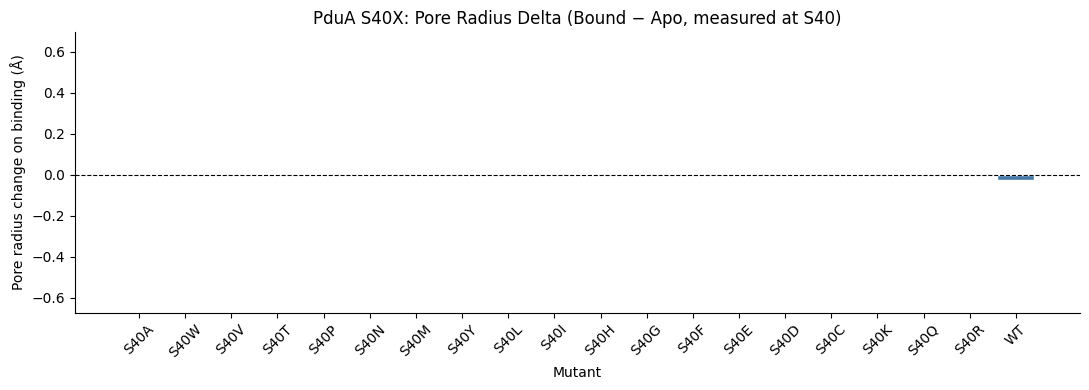

  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/pore_radius_delta_K37.png


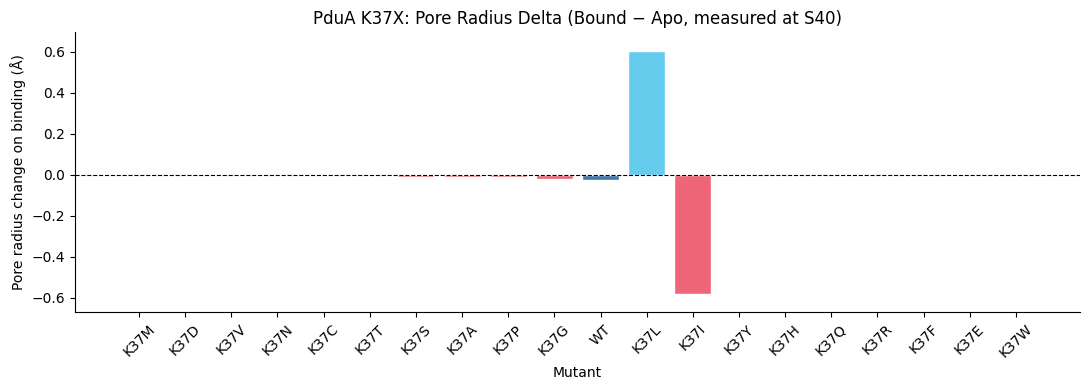

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CALL 3 — Bound vs. unbound conformational shift
#
# Two complementary readouts:
#   (a) CB RMSD: sidechain displacement at pore on binding (batch_bound_vs_unbound_fixed)
#   (b) Pore radius delta: how pore diameter changes between apo and best-docked
#       pose (batch_pore_geometry on best-bound poses vs. unbound poses)
#
# Full-chain backbone RMSD is ~0 by construction (frozen backbone).
# Both S40 and K37 variant sets are run.
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 60)
print('  BOUND vs. UNBOUND CONFORMATIONAL SHIFT')
print('=' * 60)

MUTANTS_FOR_BVU_S40 = [
    'WT', 'S40A', 'S40C', 'S40D', 'S40E', 'S40F',
    'S40G', 'S40H', 'S40I', 'S40K', 'S40L',
    'S40M', 'S40N', 'S40P', 'S40Q', 'S40R',
    'S40T', 'S40V', 'S40W', 'S40Y',
]

MUTANTS_FOR_BVU_K37 = [
    'K37A', 'K37C', 'K37D', 'K37E', 'K37F',
    'K37G', 'K37H', 'K37I', 'K37L', 'K37M',
    'K37N', 'K37P', 'K37Q', 'K37R', 'K37S',
    'K37T', 'K37V', 'K37W', 'K37Y',
]

print('NOTE: Full-chain RMSD = 0 for backbone (frozen). CB selection captures sidechain shift.\n')

# ── (a) CB RMSD: bound vs. unbound ───────────────────────────────────────
print('S40 variants — CB RMSD:')
df_bvu_s40 = batch_bound_vs_unbound_fixed(
    unbound_dir   = MUTANT_DIR,
    docking_root  = DOCKING_ROOT,
    mutants       = MUTANTS_FOR_BVU_S40,
    chain         = CHAIN,
    pore_range    = PORE_RANGE,
    atom_names    = ('CB',),
    fix_chains    = FIX_CHAINS,
    score_col     = 'interface_energy',
)
display(df_bvu_s40.round(3))
df_bvu_s40.to_csv(os.path.join(OUT_DIR, 'bound_vs_unbound_S40.csv'), index=False)

fig_bvu_s40 = plot_bound_vs_unbound(
    df_bvu_s40,
    title     = 'PduA S40X: CB RMSD Bound vs. Unbound',
    save_path = os.path.join(OUT_DIR, 'bound_vs_unbound_CB_S40.png'),
)
plt.show()

# K37 is at PDB residue 37 — PORE_RANGE (38,42) excludes it entirely.
# Use a K37-centred window (35,39) so residue 37 is within the pore_range.
K37_PORE_RANGE = (35, 39)

print('\nK37 variants — CB RMSD (pore_range centred on residue 37):')
df_bvu_k37 = batch_bound_vs_unbound_fixed(
    unbound_dir   = MUTANT_DIR,
    docking_root  = DOCKING_ROOT,
    mutants       = MUTANTS_FOR_BVU_K37,
    chain         = CHAIN,
    pore_range    = K37_PORE_RANGE,
    atom_names    = ('CB',),
    fix_chains    = FIX_CHAINS,
    score_col     = 'interface_energy',
)
display(df_bvu_k37.round(3))
df_bvu_k37.to_csv(os.path.join(OUT_DIR, 'bound_vs_unbound_K37.csv'), index=False)

fig_bvu_k37 = plot_bound_vs_unbound(
    df_bvu_k37,
    title     = 'PduA K37X: CB RMSD Bound vs. Unbound',
    save_path = os.path.join(OUT_DIR, 'bound_vs_unbound_CB_K37.png'),
)
plt.show()

# ── (b) Pore radius: bound vs. unbound ───────────────────────────────────
# Compute pore diameter from the best-docked (bound) PDB files and compare
# to the apo pore geometry from CALL 1.
#
# IMPORTANT: batch_crystal_pore_geometry is used here instead of
# batch_pore_geometry.  Docked PDB files contain HETATM ligand records
# (12PD / 12P) which can cause PyRosetta to silently fail or skip residues
# during pose loading.  The pure-PDB reader reads only ATOM records and
# ignores HETATM entirely — it measures the protein pore geometry directly
# from the file without needing ligand params.
print('\n' + '=' * 60)
print('  PORE RADIUS: BOUND vs. UNBOUND')
print('=' * 60)

best_s40 = find_best_bound_poses(DOCKING_ROOT, MUTANTS_FOR_BVU_S40, score_col='interface_energy')
# Include WT in K37 bound search for pore delta comparison
_k37_for_pore = ['WT'] + MUTANTS_FOR_BVU_K37
best_k37 = find_best_bound_poses(DOCKING_ROOT, MUTANTS_FOR_BVU_K37, score_col='interface_energy')
best_k37_pore = find_best_bound_poses(DOCKING_ROOT, _k37_for_pore, score_col='interface_energy')

print(f'\nS40 — best bound poses found: {len(best_s40)}')
print(f'K37 — best bound poses found: {len(best_k37)}')

# ── S40: pore radius delta ────────────────────────────────────────────────
if best_s40:
    # Measure pore at resseq 40 directly from docked PDB files (no PyRosetta)
    print('\nMeasuring pore geometry from S40 bound poses (pure PDB reader):')
    df_pore_bound_s40 = batch_crystal_pore_geometry(
        crystal_pdb_map = best_s40,
        target_resseq   = 40,   # intra-chain rank 40 = S40 (works for both per-chain and continuous numbering)
        use_absolute_resseq = False,   # rank-based: handles Rosetta continuous chain numbering
        hexamer_chains      = None,    # docked/unbound PDBs always have exactly 6 chains (A-F)
    )
    print(f'  Bound poses measured: {len(df_pore_bound_s40)}')
    print(f'  pore_radius_A non-NaN: {df_pore_bound_s40["pore_radius_A"].notna().sum()}')

    # Measure apo pore geometry from the unbound mutant PDB files using the
    # SAME pure-PDB rank-based method as the bound measurement.
    # (df_pore_geo_s40 uses PyRosetta poses — a different coordinate source
    # that gives systematically different radii, making delta unreliable.)
    s40_unbound_pdbs = {}
    for m in MUTANTS_FOR_BVU_S40:
        fname = 'WT_3NGK.pdb' if m == 'WT' else f'{m}_3NGK.pdb'
        p = os.path.join(MUTANT_DIR, fname)
        if os.path.exists(p):
            s40_unbound_pdbs[m] = p
    print(f'\nMeasuring pore geometry from S40 unbound mutant PDBs (pure PDB reader):')
    df_pore_apo_s40 = batch_crystal_pore_geometry(
        crystal_pdb_map = s40_unbound_pdbs,
        target_resseq   = 40,   # PDB resseq 40 = S40 directly (per-chain numbering in unbound PDBs)
        use_absolute_resseq = True,    # unbound PDBs have per-chain numbering; resseq 40 = S40
        hexamer_chains      = None,    # docked/unbound PDBs always have exactly 6 chains (A-F)
    )
    print(f'  Apo poses measured: {len(df_pore_apo_s40)}')
    print(f'  pore_radius_A non-NaN: {df_pore_apo_s40["pore_radius_A"].notna().sum()}')

    print(f'\nApo labels:   {sorted(df_pore_apo_s40["mutant"].tolist())}')
    print(f'Bound labels: {sorted(df_pore_bound_s40["mutant"].tolist())}')

    apo_pr  = df_pore_apo_s40.set_index('mutant')['pore_radius_A'].rename('pore_r_apo')
    bnd_pr  = df_pore_bound_s40.set_index('mutant')['pore_radius_A'].rename('pore_r_bound')
    df_pr_s40 = pd.concat([apo_pr, bnd_pr], axis=1).dropna().reset_index()
    df_pr_s40['delta_pore_r'] = df_pr_s40['pore_r_bound'] - df_pr_s40['pore_r_apo']
    df_pr_s40.to_csv(os.path.join(OUT_DIR, 'pore_radius_bound_vs_apo_S40.csv'), index=False)

    print(f'\nMatched rows after merge+dropna: {len(df_pr_s40)}')
    display(df_pr_s40.round(3))

    # Store for shared-axis plotting below
    _df_pr_s40 = df_pr_s40

# ── K37: pore radius delta ────────────────────────────────────────────────
if best_k37:
    # Measure pore at resseq 37 directly from docked PDB files (no PyRosetta)
    print('\nMeasuring pore geometry from K37 bound poses (pure PDB reader):')
    df_pore_bound_k37 = batch_crystal_pore_geometry(
        crystal_pdb_map = best_k37_pore,   # includes WT
        target_resseq   = 40,   # intra-chain rank 40 = S40 (works for both per-chain and continuous numbering)
        use_absolute_resseq = False,   # rank-based: handles Rosetta continuous chain numbering
        hexamer_chains      = None,    # docked/unbound PDBs always have exactly 6 chains (A-F)
    )
    print(f'  Bound poses measured: {len(df_pore_bound_k37)}')
    print(f'  pore_radius_A non-NaN: {df_pore_bound_k37["pore_radius_A"].notna().sum()}')

    # Measure apo pore geometry from the unbound mutant PDB files — same method
    # as bound measurement for apples-to-apples comparison.
    k37_unbound_pdbs = {}
    for m in MUTANTS_FOR_BVU_K37:
        p = os.path.join(MUTANT_DIR, f'{m}_3NGK.pdb')
        if os.path.exists(p):
            k37_unbound_pdbs[m] = p
    # Also add WT unbound as reference (K37 WT = LYS at position 37)
    wt_p = os.path.join(MUTANT_DIR, 'WT_3NGK.pdb')
    if os.path.exists(wt_p):
        k37_unbound_pdbs['WT'] = wt_p
    print(f'\nMeasuring pore geometry from K37 unbound mutant PDBs (pure PDB reader):')
    df_pore_apo_k37 = batch_crystal_pore_geometry(
        crystal_pdb_map = k37_unbound_pdbs,
        target_resseq   = 40,   # PDB resseq 40 = S40 directly (per-chain numbering in unbound PDBs)
        use_absolute_resseq = True,    # unbound PDBs have per-chain numbering; resseq 40 = S40
        hexamer_chains      = None,    # docked/unbound PDBs always have exactly 6 chains (A-F)
    )
    print(f'  Apo poses measured: {len(df_pore_apo_k37)}')
    print(f'  pore_radius_A non-NaN: {df_pore_apo_k37["pore_radius_A"].notna().sum()}')

    print(f'\nApo labels:   {sorted(df_pore_apo_k37["mutant"].tolist())}')
    print(f'Bound labels: {sorted(df_pore_bound_k37["mutant"].tolist())}')

    apo_pr  = df_pore_apo_k37.set_index('mutant')['pore_radius_A'].rename('pore_r_apo')
    bnd_pr  = df_pore_bound_k37.set_index('mutant')['pore_radius_A'].rename('pore_r_bound')
    df_pr_k37 = pd.concat([apo_pr, bnd_pr], axis=1).dropna().reset_index()
    df_pr_k37['delta_pore_r'] = df_pr_k37['pore_r_bound'] - df_pr_k37['pore_r_apo']
    df_pr_k37.to_csv(os.path.join(OUT_DIR, 'pore_radius_bound_vs_apo_K37.csv'), index=False)

    print(f'\nMatched rows after merge+dropna: {len(df_pr_k37)}')
    display(df_pr_k37.round(3))

    # Store for shared-axis plotting below
    _df_pr_k37 = df_pr_k37

# ── Shared y-axis bar plots for S40 and K37 pore radius delta ────────────
_have_s40 = '_df_pr_s40' in dir() and len(_df_pr_s40) > 0
_have_k37 = '_df_pr_k37' in dir() and len(_df_pr_k37) > 0

if _have_s40 or _have_k37:
    # Compute global y limits across both sites
    _all_deltas = []
    if _have_s40: _all_deltas.extend(_df_pr_s40['delta_pore_r'].tolist())
    if _have_k37: _all_deltas.extend(_df_pr_k37['delta_pore_r'].tolist())
    _pad   = max(abs(v) for v in _all_deltas) * 0.15 if _all_deltas else 0.5
    _ymin  = min(_all_deltas) - _pad
    _ymax  = max(_all_deltas) + _pad

    def _plot_pore_delta(df, title, save_name):
        fig, ax = plt.subplots(figsize=(11, 4))
        colors = ['#4477AA' if m == 'WT' else ('#66CCEE' if v >= 0 else '#EE6677')
                  for m, v in zip(df['mutant'], df['delta_pore_r'])]
        ax.bar(df['mutant'], df['delta_pore_r'], color=colors, edgecolor='white')
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_ylim(_ymin, _ymax)
        ax.set_xlabel('Mutant'); ax.set_ylabel('Pore radius change on binding (Å)')
        ax.set_title(title)
        ax.tick_params(axis='x', rotation=45)
        sns.despine(fig); fig.tight_layout()
        fig.savefig(os.path.join(OUT_DIR, save_name), dpi=150, bbox_inches='tight')
        print(f'  Saved → {OUT_DIR}/{save_name}')
        plt.show()
        return fig

    if _have_s40:
        fig_dpr_s40 = _plot_pore_delta(
            _df_pr_s40,
            'PduA S40X: Pore Radius Delta (Bound − Apo, measured at S40)',
            'pore_radius_delta_S40.png',
        )
    else:
        print('  WARNING: No matched rows for S40 pore delta — check label alignment above.')

    if _have_k37:
        fig_dpr_k37 = _plot_pore_delta(
            _df_pr_k37,
            'PduA K37X: Pore Radius Delta (Bound − Apo, measured at S40)',
            'pore_radius_delta_K37.png',
        )
    else:
        print('  WARNING: No matched rows for K37 pore delta — check label alignment above.')

## Cell 13 — Call 4: Pairwise RMSD Matrix + Correlation Clustermap

  PAIRWISE CB-RMSD MATRIX

S40 variants:
Pre-loading 20 structures ...
Extracting coordinates ...
Computing 190 RMSD pairs ...
Done.  Matrix shape: (20, 20)
  S40 off-diagonal: min=0.000 A  mean=0.015 A  max=0.096 A
  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/cb_rmsd_clustermap_S40.png


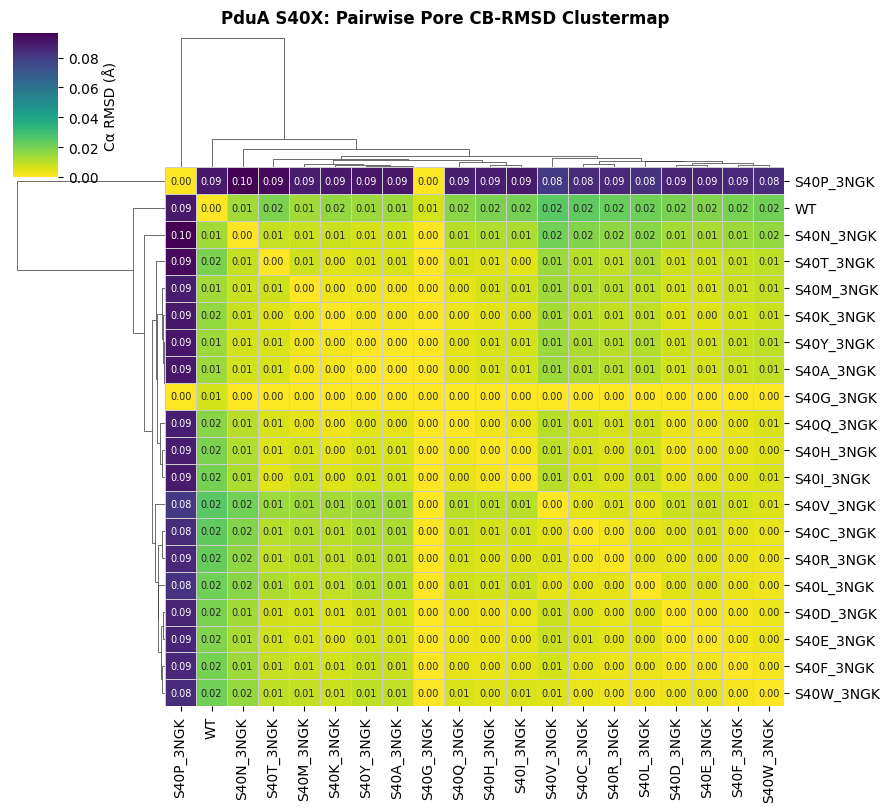

  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/cb_rmsd_similarity_clustermap_S40.png


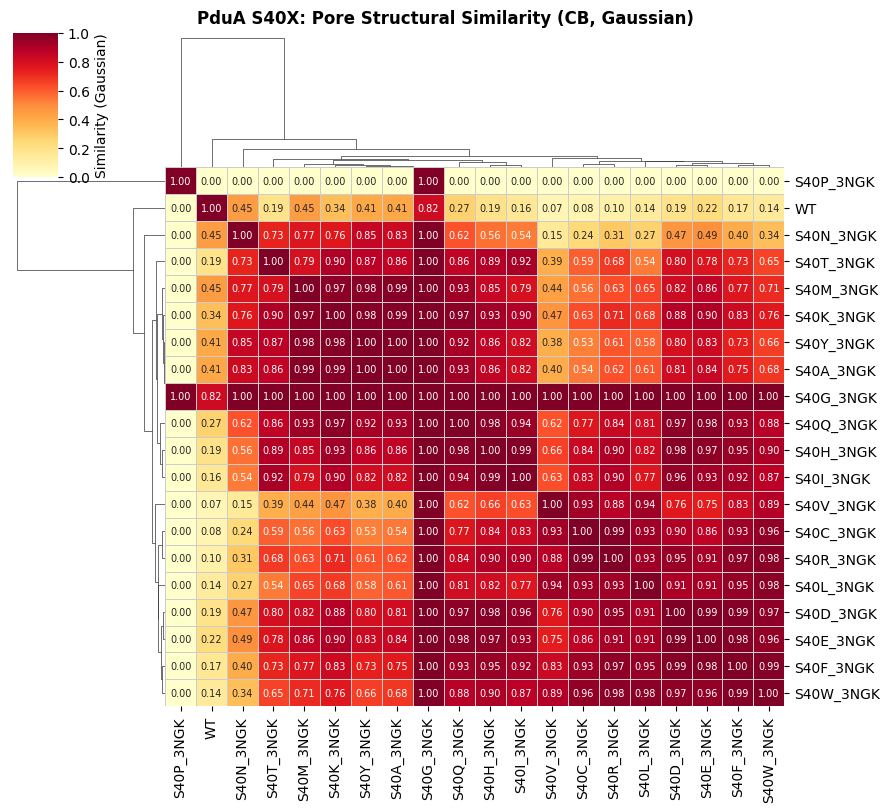


K37 variants:
Pre-loading 20 structures ...
Extracting coordinates ...
Computing 190 RMSD pairs ...
Done.  Matrix shape: (20, 20)
  K37 off-diagonal: min=0.000 A  mean=0.002 A  max=0.020 A
  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/cb_rmsd_clustermap_K37.png


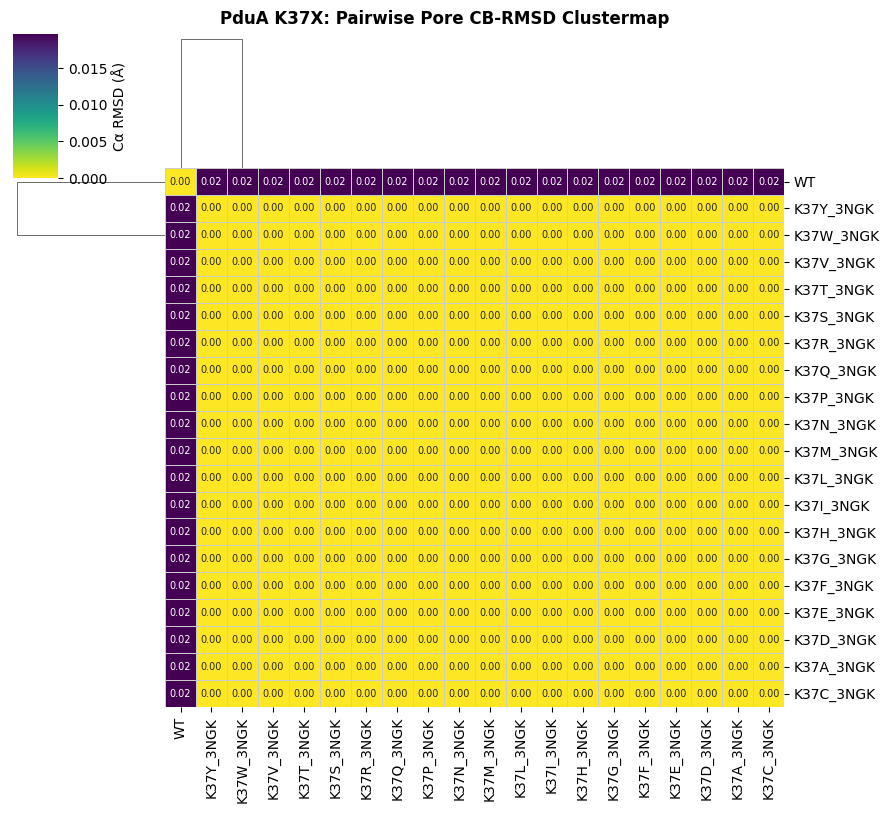

  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/cb_rmsd_similarity_clustermap_K37.png


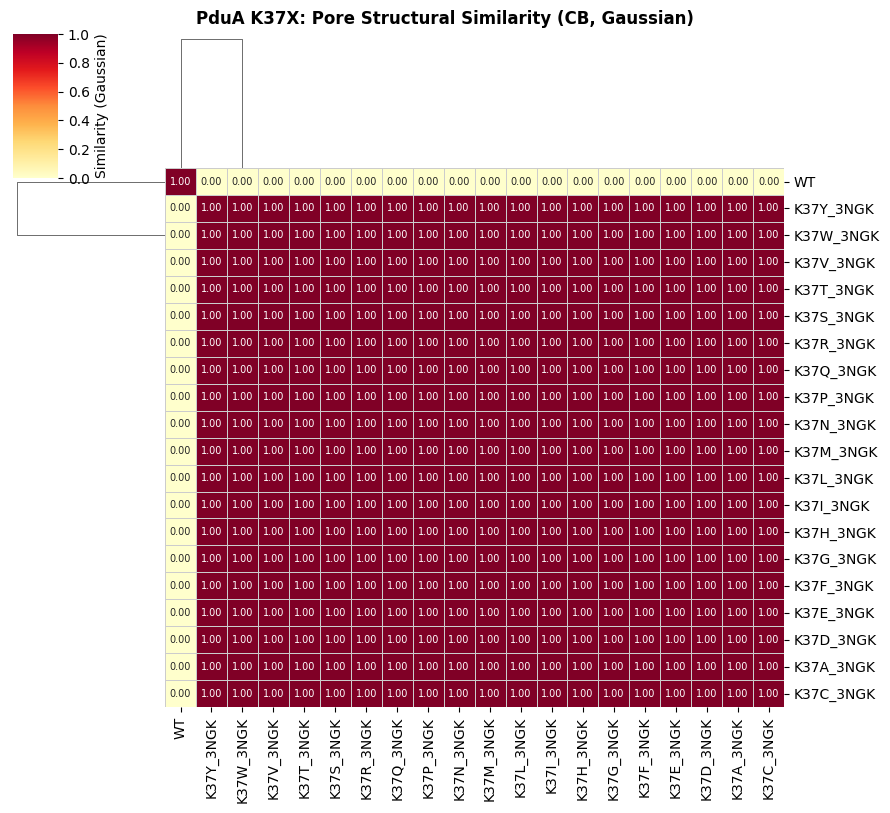

  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/cb_rmsd_heatmap_ordered_S40.png


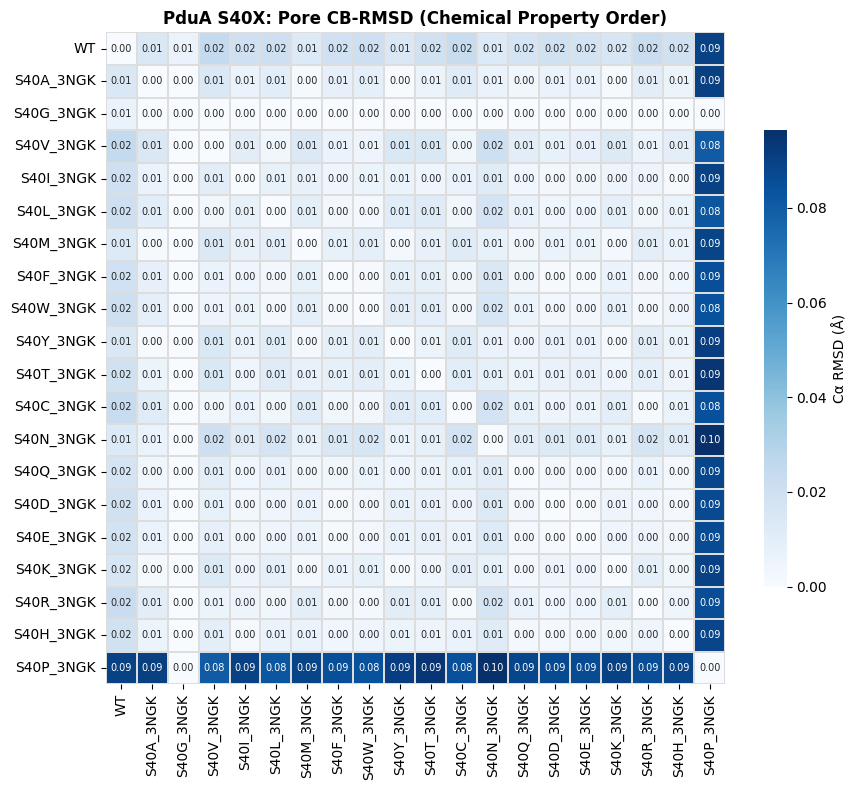

  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/cb_rmsd_heatmap_ordered_K37.png


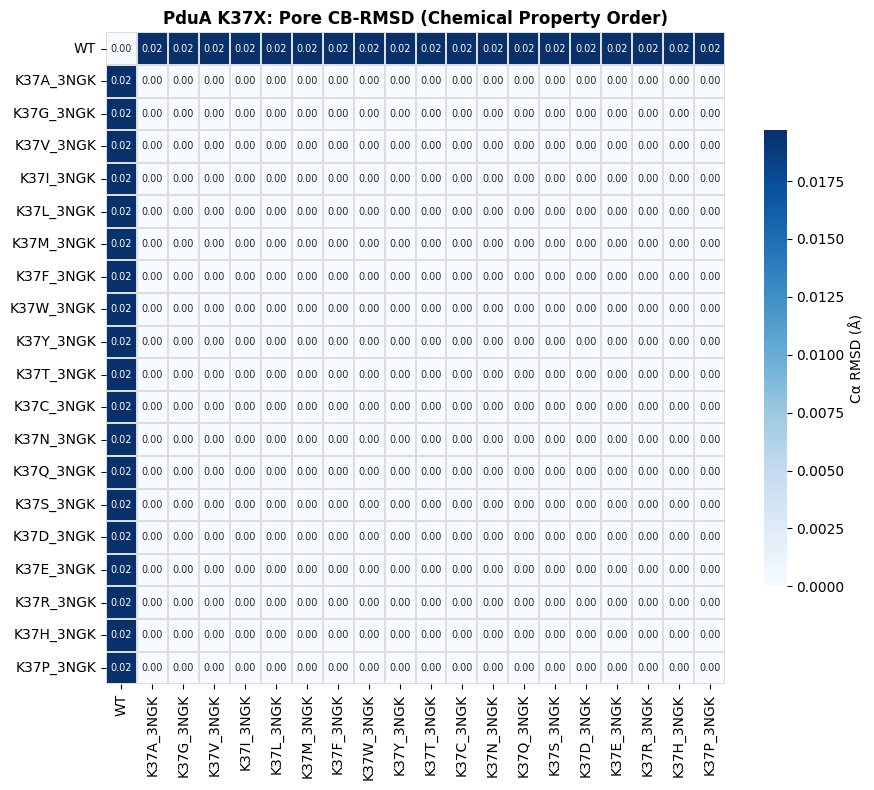

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CALL 4 — Pairwise CB-RMSD matrix and clustermap
#
# Using CB atoms to match the sidechain-focused methodology established in
# Cells 10-12.  Cα would give all-zero values for rigid-backbone models.
# Run separately for S40 and K37 so within-site clustering is clean.
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 60)
print('  PAIRWISE CB-RMSD MATRIX')
print('=' * 60)

# Include WT in both site maps
s40_pdbs_with_wt = dict(s40_mutant_pdbs)
s40_pdbs_with_wt['WT'] = WT_PDB

k37_pdbs_with_wt = dict(k37_mutant_pdbs)
k37_pdbs_with_wt['WT'] = WT_PDB

# ── S40 pairwise CB-RMSD ─────────────────────────────────────────────────
print('\nS40 variants:')
rmsd_mat_s40 = build_rmsd_matrix(
    pdb_map       = s40_pdbs_with_wt,
    chain         = CHAIN,
    pdb_res_range = PORE_RANGE,      # restrict to pore residues — site-specific
    atom_names    = ('CB',),          # sidechain, not backbone
    fix_chains    = FIX_CHAINS,
)
rmsd_mat_s40.to_csv(os.path.join(OUT_DIR, 'pairwise_cb_rmsd_matrix_S40.csv'))

off_s40 = rmsd_mat_s40.values[np.triu_indices_from(rmsd_mat_s40.values, k=1)]
print(f'  S40 off-diagonal: min={np.nanmin(off_s40):.3f} A  mean={np.nanmean(off_s40):.3f} A  max={np.nanmax(off_s40):.3f} A')

g_s40 = plot_rmsd_clustermap(
    rmsd_mat_s40,
    as_similarity = False,
    title         = 'PduA S40X: Pairwise Pore CB-RMSD Clustermap',
    cmap          = 'viridis_r',
    save_path     = os.path.join(OUT_DIR, 'cb_rmsd_clustermap_S40.png'),
)
plt.show()

g_sim_s40 = plot_rmsd_clustermap(
    rmsd_mat_s40,
    as_similarity = True,
    title         = 'PduA S40X: Pore Structural Similarity (CB, Gaussian)',
    save_path     = os.path.join(OUT_DIR, 'cb_rmsd_similarity_clustermap_S40.png'),
)
plt.show()

# ── K37 pairwise CB-RMSD ─────────────────────────────────────────────────
print('\nK37 variants:')
rmsd_mat_k37 = build_rmsd_matrix(
    pdb_map       = k37_pdbs_with_wt,
    chain         = CHAIN,
    pdb_res_range = PORE_RANGE,
    atom_names    = ('CB',),
    fix_chains    = FIX_CHAINS,
)
rmsd_mat_k37.to_csv(os.path.join(OUT_DIR, 'pairwise_cb_rmsd_matrix_K37.csv'))

off_k37 = rmsd_mat_k37.values[np.triu_indices_from(rmsd_mat_k37.values, k=1)]
print(f'  K37 off-diagonal: min={np.nanmin(off_k37):.3f} A  mean={np.nanmean(off_k37):.3f} A  max={np.nanmax(off_k37):.3f} A')

g_k37 = plot_rmsd_clustermap(
    rmsd_mat_k37,
    as_similarity = False,
    title         = 'PduA K37X: Pairwise Pore CB-RMSD Clustermap',
    cmap          = 'viridis_r',
    save_path     = os.path.join(OUT_DIR, 'cb_rmsd_clustermap_K37.png'),
)
plt.show()

g_sim_k37 = plot_rmsd_clustermap(
    rmsd_mat_k37,
    as_similarity = True,
    title         = 'PduA K37X: Pore Structural Similarity (CB, Gaussian)',
    save_path     = os.path.join(OUT_DIR, 'cb_rmsd_similarity_clustermap_K37.png'),
)
plt.show()

# ── Plain heatmaps with chemical-property ordering ────────────────────────
manual_order_s40 = [
    'WT',
    'S40A_3NGK', 'S40G_3NGK',
    'S40V_3NGK', 'S40I_3NGK', 'S40L_3NGK', 'S40M_3NGK',
    'S40F_3NGK', 'S40W_3NGK', 'S40Y_3NGK',
    'S40T_3NGK', 'S40C_3NGK', 'S40N_3NGK', 'S40Q_3NGK',
    'S40D_3NGK', 'S40E_3NGK',
    'S40K_3NGK', 'S40R_3NGK', 'S40H_3NGK', 'S40P_3NGK',
]
manual_order_k37 = [
    'WT',
    'K37A_3NGK', 'K37G_3NGK',
    'K37V_3NGK', 'K37I_3NGK', 'K37L_3NGK', 'K37M_3NGK',
    'K37F_3NGK', 'K37W_3NGK', 'K37Y_3NGK',
    'K37T_3NGK', 'K37C_3NGK', 'K37N_3NGK', 'K37Q_3NGK',
    'K37S_3NGK',
    'K37D_3NGK', 'K37E_3NGK',
    'K37R_3NGK', 'K37H_3NGK', 'K37P_3NGK',
]

for label, mat, order, fname in [
    ('S40', rmsd_mat_s40, manual_order_s40, 'cb_rmsd_heatmap_ordered_S40.png'),
    ('K37', rmsd_mat_k37, manual_order_k37, 'cb_rmsd_heatmap_ordered_K37.png'),
]:
    present = [l for l in order if l in mat.index]
    if len(present) >= 2:
        fig_plain = plot_rmsd_heatmap(
            mat.loc[present, present],
            title     = f'PduA {label}X: Pore CB-RMSD (Chemical Property Order)',
            cmap      = 'Blues',
            save_path = os.path.join(OUT_DIR, fname),
        )
        plt.show()


## Cell 14 — Call 5: Full Spearman ρ Heatmap

For each site (S40, K37), computes a **7 × N Spearman ρ matrix** correlating
physicochemical properties of the substituted amino acid (rows) against every
computed and experimental metric (columns).

**Rows (physical properties)**
- Backbone avg pKa · Total avg pKa · Isoelectric point · Molar mass
- Nχ dihedral angles · C–Cα dihedral · N–Cα dihedral

**S40 columns:** ΔΔG (computed) · Lit ΔΔG (Chowdhury 2014) · Lit pore diam ·
Computed pore diam · PduD activity · Pore radius delta

**K37 columns:** ΔΔG (computed) · Computed pore diam · Pore radius delta ·
Final OD600 (Slininger Lee 2017, Fig 6 — fill `_OD600_K37_SLI2017` from the paper)

> Gold borders and bold text mark cells with p < 0.05.  
> Heatmaps are saved to `rmsd_analysis/spearman_property_heatmap_full.png`.


  S40A      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  S40C      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  S40D      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  S40E      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  S40F      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  S40G      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  S40H      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  S40I      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  S40K      crystal pore_d=20.55 Å  (VAL | chain C CG2 ↔ chain F CG2)
  S40L      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  S40M      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  S40N      crystal pore_d=20.55 Å  (VAL | chain B CG2 ↔ chain E CG2)
  S40P      crystal pore_d=20.55 Å  (VAL | chain C CG2 ↔ chain F CG2)
  S40Q      crystal pore_d=20.56 Å  (VAL | chain C CG2 ↔ chain F CG2)
  S40R      crystal 

,ΔΔG\n(computed),Lit ΔΔG\n(Chowdhury),Lit pore\ndiam (Å),Computed\npore diam (Å),PduD\nactivity,Pore radius\ndelta (Å),Assembly Enrichment
property,,,,,,,
Backbone\navg pKa,0.275,-0.400,0.200,0.426,-0.452,0.439,0.276
Total\navg pKa,0.451,-0.200,0.400,0.367,-0.429,-0.125,-0.285
Isoelectric\npt (pI),0.449,0.316,0.051,0.237,-0.096,-0.126,-0.298
Molar mass\n(Da),-0.354,0.400,-0.500,-0.480,0.167,-0.266,-0.187
N χ angles,-0.059,0.316,-0.667,-0.178,-0.037,-0.482,-0.469
C–Cα\ndihedral (°),0.135,-1.000,0.100,0.294,0.252,0.063,-0.081
N–Cα\ndihedral (°),-0.108,1.000,0.000,-0.234,-0.095,0.172,0.054



K37 Spearman ρ matrix:


,ΔΔG\n(computed),Computed\npore diam (Å),Pore radius\ndelta (Å),Assembly Enrichment,Final OD600\n(SL17 Fig6)
property,,,,,
Backbone\navg pKa,-0.233,-0.275,-0.408,0.578,-0.225
Total\navg pKa,-0.375,-0.076,-0.390,0.187,-0.568
Isoelectric\npt (pI),-0.344,-0.024,-0.236,0.135,-0.449
Molar mass\n(Da),-0.167,0.458,0.469,-0.499,0.050
N χ angles,0.082,0.436,0.383,-0.314,0.194
C–Cα\ndihedral (°),-0.092,-0.398,-0.439,-0.046,0.150
N–Cα\ndihedral (°),-0.039,0.477,0.191,0.051,-0.225



  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/spearman_property_heatmap_full.png


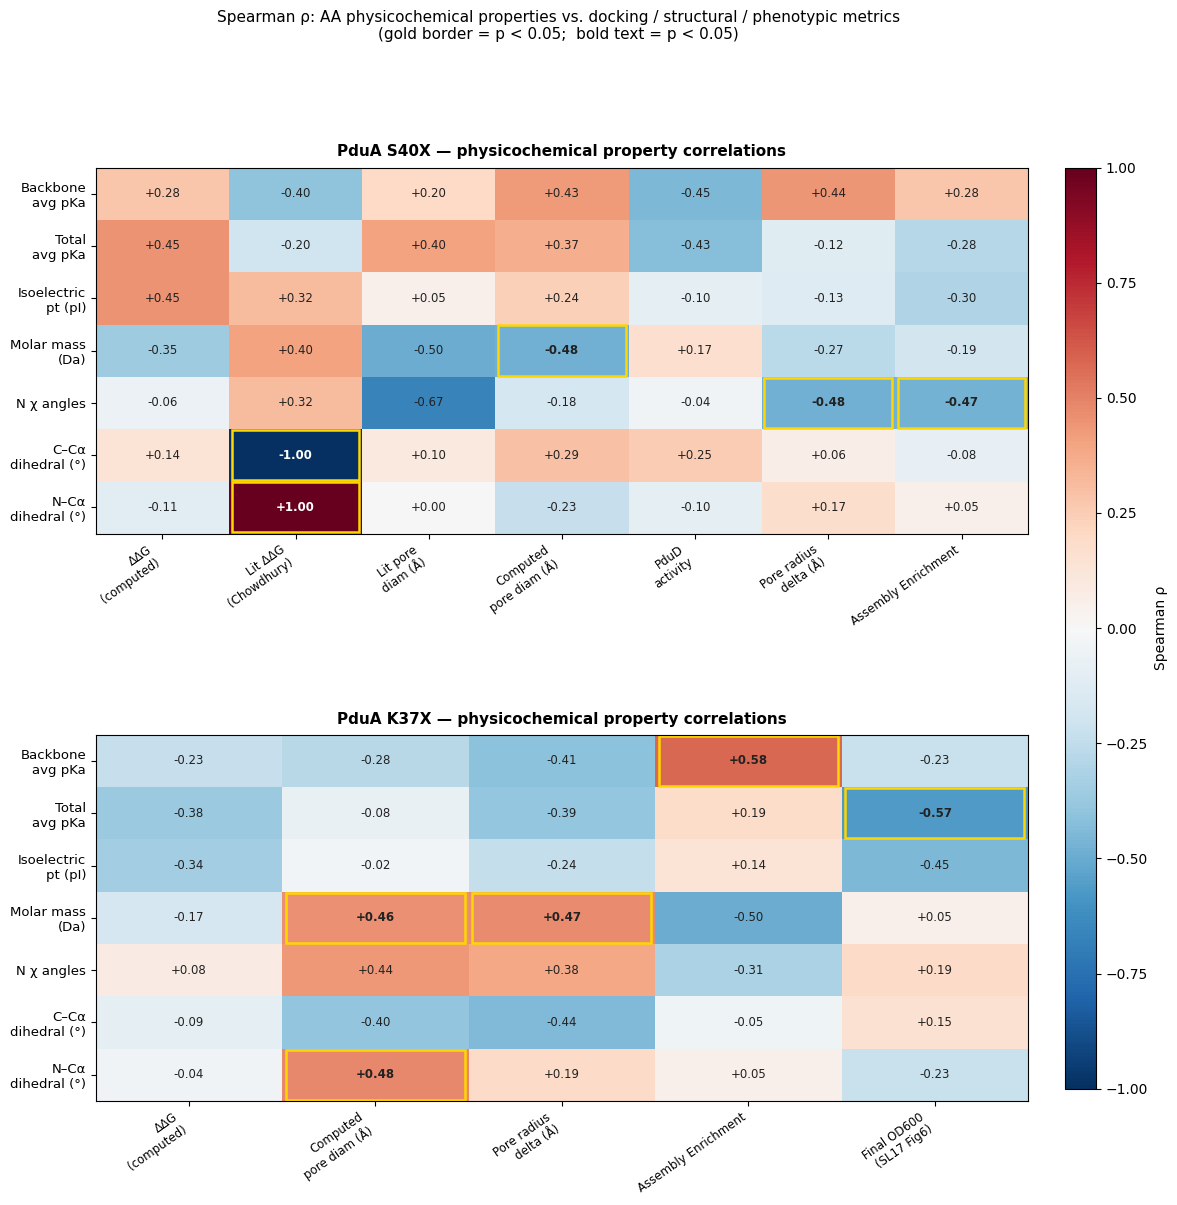

  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/spearman_matrix_S40.csv
  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduA_rmsd_analysis/spearman_matrix_K37.csv


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# CALL 5 — Spearman correlation heatmap: physicochemical properties of the
#           substituted amino acid vs. every computed / experimental metric
#
# Y-axis (rows): 7 physicochemical properties of the substituted AA
#   ┌──────────────────────┬──────────────────────────────────────────────┐
#   │ Backbone avg pKa     │ pKa of backbone NH/CO in average context     │
#   │ Total avg pKa        │ Average over all ionisable groups            │
#   │ Isoelectric pt (pI)  │ Standard AA isoelectric point                │
#   │ Molar mass (Da)      │ AA molecular weight                          │
#   │ N χ angles           │ Number of sidechain dihedral angles          │
#   │ C–Cα dihedral (°)    │ Average C–Cα backbone dihedral               │
#   │ N–Cα dihedral (°)    │ Average N–Cα backbone dihedral               │
#   └──────────────────────┴──────────────────────────────────────────────┘
#
# X-axis (columns): computed + literature metrics, split by site
#   S40 columns:  ΔΔG (computed), Lit ΔΔG (Chowdhury 2014), Lit pore diam,
#                 Computed pore diam, PduD activity, Pore radius delta
#   K37 columns:  ΔΔG (computed), Computed pore diam (at S40 constriction),
#                 Pore radius delta, Final OD600 (Slininger Lee 2017 Fig 6)
#
# NOTE on R/E isoelectric points: the user-supplied table has E=3.08 and R=3.08.
# These are used as provided; standard reference values are E≈3.22, R≈10.76.
# If you intended R to be ~10.76, update _PI['R'] below before re-running.
#
# NOTE on OD600 (Slininger Lee 2017, Fig 6): the dictionary _OD600_K37_SLI2017
# is pre-populated with the values that can be determined from Fig 6 of
# Slininger Lee et al., ACS Synth. Biol. 2017, 6(10):1880-1891.
# Mutants tested: K37A, K37D, K37E, K37H, K37I, K37L, K37N, K37Q, K37R, K37S, WT
# (the paper tested a subset of K37 substitutions).
# Values not reported in the paper are left as np.nan.
# ─────────────────────────────────────────────────────────────────────────────

from scipy.stats import spearmanr as _spearmanr

# ── Single-letter code ordering ──────────────────────────────────────────────
_AA1 = list('ACDEFGHIKLMNPQRSTVWY')

# ── Physicochemical property tables ─────────────────────────────────────────
# Backbone average pKa (backbone NH/CO context)
_PKA_BB = dict(zip(_AA1, [
    6.11, 6.31, 5.945, 5.785, 5.755, 6.065, 5.565, 6.04, 5.72,  6.035,
    5.705, 5.43, 6.295, 5.65, 5.405, 5.7, 5.595, 6.015, 5.935, 5.705,
]))

# Total average pKa (over all ionisable groups)
_PKA_TOT = dict(zip(_AA1, [
    6.11, 6.31, 5.263, 5.213, 5.755, 6.065, 5.723, 6.04, 7.327, 6.035,
    5.705, 5.43, 6.295, 5.65, 7.763, 5.7, 5.595, 6.015, 5.935, 7.29,
]))

# Isoelectric point (over entire residue)
_PI = dict(zip(_AA1, [
    6.02, 9.56, 2.98, 3.22, 5.48, 5.97, 7.61, 6.02, 9.87, 6.02, 
    5.75, 5.43, 6.30, 5.65, 10.76, 5.68, 5.87, 5.97, 5.89, 9.59,
]))

# Molar mass (Da)
_MW = dict(zip(_AA1, [
    89, 121, 132, 146, 165, 75, 155, 131, 147, 131,
    149, 132, 115, 146, 175, 105, 119, 117, 204, 181,
]))

# Number of sidechain dihedral (χ) angles
_N_CHI = dict(zip(_AA1, [
    0, 1, 2, 3, 2, 0, 2, 2, 4, 2,
    3, 2, 2, 3, 4, 1, 1, 1, 2, 2,
]))

# Average C–Cα backbone dihedral (°)
_C_CA = dict(zip(_AA1, [
    143.8, 139.3, 129.0, 134.4, 140.6, 180.0, 136.0, 130.5, 134.2, 131.8,
    139.3, 135.7, 157.5, 136.9, 135.9, 145.1, 138.1, 132.5, 142.7, 142.8,
]))

# Average N–Cα backbone dihedral (°)
_N_CA = dict(zip(_AA1, [
    -130.2, -124.2, -113.4, -121.0, -123.3, -180.0, -122.4, -118.5, -118.9, -115.2,
    -127.5, -117.9, -45.0, -124.5, -123.9, -129.7, -123.9, -121.2, -124.7, -125.5,
]))

# Ordered dict for display on y-axis (row order matches user's request)
PHYS_PROPS = {
    'Backbone\navg pKa':   _PKA_BB,
    'Total\navg pKa':      _PKA_TOT,
    'Isoelectric\npt (pI)':_PI,
    'Molar mass\n(Da)':    _MW,
    'N χ angles':          _N_CHI,
    'C–Cα\ndihedral (°)':  _C_CA,
    'N–Cα\ndihedral (°)':  _N_CA,
}

# ── Slininger Lee 2017 Fig 6: final OD600 for K37 mutants grown on 1,2-PD ───
_OD600_K37_SLI2017 = {
    'WT':   1.86,
    'K37A': np.nan,
    'K37C': 0.61,
    'K37D': 1.85,
    'K37E': 2.19,
    'K37F': 0.81,
    'K37G': 1.23,
    'K37H': 1.44,
    'K37I': np.nan,
    'K37L': 1.08,
    'K37M': np.nan,
    'K37N': 1.00,
    'K37P': 1.41,
    'K37Q': 2.91,
    'K37R': 0.89,
    'K37S': 3.05,
    'K37T': 1.61,
    'K37V': 0.68,
    'K37W': 2.33,
    'K37Y': np.nan,
}

# ── Kennedy unpublished assembly of PduA fibrils in E. coli ─────────────────
_assembly = {
    'WT':   0.40,
    'K37A': 0.82,
    'K37C': 0.61,
    'K37D':-0.12,
    'K37E': np.nan,
    'K37F':-0.27,
    'K37G': 0.35,
    'K37H': 0.37,
    'K37I': 0.95,
    'K37L': 0.38,
    'K37M': np.nan,
    'K37N': np.nan,
    'K37P': 0.40,
    'K37Q': np.nan,
    'K37R': 0.08,
    'K37S': 0.53,
    'K37T':-4.00,
    'K37V': 0.62,
    'K37W': np.nan,
    'K37Y':-0.54,
    'S40A': 0.74,
    'S40C': 1.68,
    'S40D': 0.87,
    'S40E': 0.54,
    'S40F': 1.81,
    'S40G': 0.34,
    'S40H': 0.74,
    'S40I': 0.90,
    'S40K':-0.58,
    'S40L': 0.22,
    'S40M': 0.70,
    'S40N': 0.67,
    'S40P': 0.41,
    'S40Q': 0.24,
    'S40R':-0.88,
    'S40T': 0.59,
    'S40V': 1.20,
    'S40W': 0.36,
    'S40Y': 0.46,
}

# ── Helper: build a site-level Spearman ρ matrix ────────────────────────────
def _build_spearman_matrix(
    site_prefix:     str,                     # 'S40' or 'K37'
    combined_csv:    str,                     # all_docking_scores.csv
    df_pore_geo:     pd.DataFrame,            # from batch_pore_geometry (models)
    df_apo_pore:     pd.DataFrame,            # from batch_crystal_pore_geometry (unbound)
    df_pr_delta:     pd.DataFrame,            # df_pr_s40 or df_pr_k37 (pore radius delta)
    lit_ddg:         dict      = LITERATURE_DDG,
    od600_map:       dict      = _OD600_K37_SLI2017,               # {mutant_full_label: OD600} or None
    assembly_map:    dict      = _assembly,
    wt_label:        str       = 'WT',
    n_top:           int       = 10,
) -> pd.DataFrame:
    """
    Returns a DataFrame (properties × metrics) of Spearman ρ values.
    Excludes WT from all correlations (19 substitutions only).
    NaN cells indicate fewer than 4 paired observations.
    """

    # ── 1. Computed ΔΔG from docking ──────────────────────────────────────
    df_dock = pd.read_csv(combined_csv)
    mask = (df_dock['mutant'].str.startswith(site_prefix) |
            (df_dock['mutant'] == wt_label))
    df_dock = df_dock[mask]
    agg = []
    for mut, grp in df_dock.groupby('mutant'):
        top = grp.nsmallest(n_top, 'interface_energy')
        agg.append({'mutant': mut, 'mean_dG': top['interface_energy'].mean()})
    df_agg = pd.DataFrame(agg)
    wt_dG  = df_agg.loc[df_agg['mutant'] == wt_label, 'mean_dG'].iloc[0]
    df_agg['ddG_REU'] = df_agg['mean_dG'] - wt_dG

    # ── 2. Computed pore radius (from Rosetta models) ─────────────────────
    df_p = df_pore_geo.copy()
    df_p['mutant'] = df_p['mutant'].str.replace('_3NGK$', '', regex=True)

    # ── 3. Apo pore diameter (from raw PDB, unbound) ─────────────────────
    df_ap = df_apo_pore.copy()

    # ── 4. Pore radius delta (bound − apo) ────────────────────────────────
    df_delta = df_pr_delta[['mutant', 'delta_pore_r']].copy() if df_pr_delta is not None else pd.DataFrame(columns=['mutant','delta_pore_r'])

    # ── 5. Literature data for S40 (Chowdhury 2014) ──────────────────────
    lit_rows = []
    for k, v in lit_ddg.items():
        if k.startswith(site_prefix) or k == wt_label:
            lit_rows.append({
                'mutant':          k,
                'lit_ddG':         v.get('ddG_exp_kcal_mol'),
                'lit_pore_diam':   v.get('pore_diameter'),
                'PduD_activity':   v.get('PduD_activity'),
            })
    df_lit = (pd.DataFrame(lit_rows) if lit_rows else
             pd.DataFrame(columns=['mutant', 'lit_ddG', 'lit_pore_diam', 'PduD_activity']))

    # ── 6. Merge everything ───────────────────────────────────────────────
    df = (df_agg
          .merge(df_p[['mutant','pore_diameter_A']].rename(columns={'pore_diameter_A':'pore_d_comp'}),
                 on='mutant', how='left')
          .merge(df_ap[['mutant','pore_diameter_A']].rename(columns={'pore_diameter_A':'pore_d_apo'}),
                 on='mutant', how='left')
          .merge(df_delta, on='mutant', how='left')
          .merge(df_lit,   on='mutant', how='left'))

    # OD600 column (K37 only)
    if od600_map:
        df['od600'] = df['mutant'].map(od600_map)
    else:
        df['od600'] = np.nan


    # assembly data
    if assembly_map:
        df['assembly'] = df['mutant'].map(assembly_map)
    else:
        df['assembly'] = np.nan

    # ── 7. Restrict to 19 non-WT substitutions; extract single-letter code
    df = df[df['mutant'] != wt_label].copy()
    df['aa'] = df['mutant'].str[-1]

    # ── 8. Define metric columns for this site ────────────────────────────
    if site_prefix in ('S40', 'S39'):
        METRICS = {
            'ΔΔG\n(computed)':         'ddG_REU',
            'Lit ΔΔG\n(Chowdhury)':   'lit_ddG',
            'Lit pore\ndiam (Å)':      'lit_pore_diam',
            'Computed\npore diam (Å)': 'pore_d_comp',
            'PduD\nactivity':          'PduD_activity',
            'Pore radius\ndelta (Å)':  'delta_pore_r',
            'Assembly Enrichment':     'assembly'
        }
    else:  # K37
        METRICS = {
            'ΔΔG\n(computed)':         'ddG_REU',
            'Computed\npore diam (Å)': 'pore_d_comp',
            'Pore radius\ndelta (Å)':  'delta_pore_r',
            'Assembly Enrichment':     'assembly',
            'Final OD600\n(SL17 Fig6)':'od600',
        }

    # ── 9. Compute Spearman ρ for each (property, metric) pair ───────────
    rows = []
    for prop_name, prop_map in PHYS_PROPS.items():
        row = {'property': prop_name}
        for metric_label, metric_col in METRICS.items():
            if metric_col not in df.columns:
                row[metric_label] = np.nan
                continue
            sub = df[['aa', metric_col]].dropna()
            sub = sub[sub['aa'].isin(prop_map)]
            if len(sub) < 4:
                row[metric_label] = np.nan
                continue
            x = [prop_map[a] for a in sub['aa']]
            y = sub[metric_col].tolist()
            rho, pval = _spearmanr(x, y)
            row[metric_label]          = round(rho, 3)
            row[metric_label + '_p']   = round(pval, 4)   # stored but not displayed
        rows.append(row)

    result = pd.DataFrame(rows).set_index('property')
    # Separate p-value columns for optional significance masking
    p_cols  = [c for c in result.columns if c.endswith('_p')]
    rho_mat = result.drop(columns=p_cols)
    p_mat   = result[p_cols].rename(columns=lambda c: c[:-2])  # strip '_p'
    return rho_mat, p_mat


# ── Plot helper ──────────────────────────────────────────────────────────────
def _plot_spearman_heatmap(
    rho_mat:     pd.DataFrame,
    p_mat:       pd.DataFrame,
    title:       str,
    ax,
    vabs:        float,
    sig_alpha:   float = 0.05,
):
    """
    Draw a single Spearman ρ heatmap on *ax*.
    Significant cells (p < sig_alpha) get a bold border.
    """
    cmap = plt.cm.RdBu_r
    im = ax.imshow(
        rho_mat.values.astype(float),
        cmap=cmap, vmin=-vabs, vmax=vabs, aspect='auto',
    )
    nrows, ncols = rho_mat.shape

    ax.set_xticks(range(ncols))
    ax.set_xticklabels(rho_mat.columns, fontsize=8.5, rotation=35, ha='right')
    ax.set_yticks(range(nrows))
    ax.set_yticklabels(rho_mat.index, fontsize=9.5)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)

    for r in range(nrows):
        for c in range(ncols):
            val = rho_mat.values[r, c]
            col_name = rho_mat.columns[c]
            p_val = p_mat.loc[rho_mat.index[r], col_name] if col_name in p_mat.columns else np.nan

            if np.isnan(val):
                ax.text(c, r, 'n/a', ha='center', va='center', fontsize=7, color='#aaaaaa')
                continue

            # Pick text colour for contrast
            norm_v  = (val + vabs) / (2 * vabs)
            bg_lum  = (0.2126 * cmap(norm_v)[0] +
                       0.7152 * cmap(norm_v)[1] +
                       0.0722 * cmap(norm_v)[2])
            txt_col = 'white' if bg_lum < 0.45 else '#222222'

            weight = 'bold' if (not np.isnan(p_val) and p_val < sig_alpha) else 'normal'
            ax.text(c, r, f'{val:+.2f}',
                    ha='center', va='center',
                    fontsize=8.5, color=txt_col, fontweight=weight)

            # Significant cells: draw a coloured border rect
            if not np.isnan(p_val) and p_val < sig_alpha:
                from matplotlib.patches import FancyBboxPatch
                ax.add_patch(FancyBboxPatch(
                    (c - 0.48, r - 0.48), 0.96, 0.96,
                    boxstyle='square,pad=0', linewidth=1.8,
                    edgecolor='#FFD700', facecolor='none',
                ))

    return im


# ── Main execution ───────────────────────────────────────────────────────────
if not os.path.exists(COMBINED_CSV):
    print('WARNING: COMBINED_CSV not found — skipping Spearman heatmap.')
else:
    # Rebuild apo pore series (same protocol as earlier cells, no PyRosetta)
    _s40_unb = {k.replace('_3NGK', ''): v
                for k, v in all_mutant_pdbs.items() if k.startswith('S40')}
    _s40_unb['WT'] = WT_PDB
    _df_apo_s40_hm = batch_crystal_pore_geometry(
        crystal_pdb_map=_s40_unb, target_resseq=40,
        use_absolute_resseq=True, hexamer_chains=None)  # per-chain PDB: resseq 40 = S40 directly

    _k37_unb = {k.replace('_3NGK', ''): v
                for k, v in all_mutant_pdbs.items() if k.startswith('K37')}
    _k37_unb['WT'] = WT_PDB
    _df_apo_k37_hm = batch_crystal_pore_geometry(
        crystal_pdb_map=_k37_unb, target_resseq=40,
        use_absolute_resseq=True, hexamer_chains=None)  # per-chain PDB: resseq 40 = S40 directly

    # Safely retrieve pore-delta DataFrames (may not exist if cell 12 was skipped)
    _df_pr_s40_hm = df_pr_s40 if '_have_s40' in dir() and _have_s40 else None
    _df_pr_k37_hm = df_pr_k37 if '_have_k37' in dir() and _have_k37 else None

    print('=' * 60)
    print('  BUILDING SPEARMAN ρ MATRICES')
    print('=' * 60)

    rho_s40, p_s40 = _build_spearman_matrix(
        site_prefix  = 'S40',
        combined_csv = COMBINED_CSV,
        df_pore_geo  = df_pore_geo_s40,
        df_apo_pore  = _df_apo_s40_hm,
        df_pr_delta  = _df_pr_s40_hm,
        lit_ddg      = LITERATURE_DDG,
        assembly_map = _assembly,
    )

    rho_k37, p_k37 = _build_spearman_matrix(
        site_prefix  = 'K37',
        combined_csv = COMBINED_CSV,
        df_pore_geo  = df_pore_geo_k37,
        df_apo_pore  = _df_apo_k37_hm,
        df_pr_delta  = _df_pr_k37_hm,
        lit_ddg      = LITERATURE_DDG,
        assembly_map = _assembly,
        od600_map    = _OD600_K37_SLI2017,
    )

    print('\nS40 Spearman ρ matrix:')
    display(rho_s40.round(3))
    print('\nK37 Spearman ρ matrix:')
    display(rho_k37.round(3))

    # ── Plot: two heatmaps stacked vertically ────────────────────────────
    # S40 has 6 metric columns; K37 has 4. Use a width-ratio gridspec.
    _n_s40 = len(rho_s40.columns)
    _n_k37 = len(rho_k37.columns)
    _nrows  = len(PHYS_PROPS)   # 7

    fig, (ax_s40, ax_k37) = plt.subplots(
        2, 1,
        figsize=(max(_n_s40, _n_k37) * 1.55 + 1.5, _nrows * 0.78 * 2 + 1.2),
        gridspec_kw={'hspace': 0.55},
    )

    _vabs = max(
        np.nanmax(np.abs(rho_s40.values)),
        np.nanmax(np.abs(rho_k37.values)),
    )
    _vabs = min(float(_vabs), 1.0)

    im_s40 = _plot_spearman_heatmap(
        rho_s40, p_s40,
        title   = 'PduA S40X — physicochemical property correlations',
        ax      = ax_s40,
        vabs    = _vabs,
    )
    im_k37 = _plot_spearman_heatmap(
        rho_k37, p_k37,
        title   = 'PduA K37X — physicochemical property correlations',
        ax      = ax_k37,
        vabs    = _vabs,
    )

    # Shared colourbar
    fig.subplots_adjust(right=0.88)
    cbar_ax = fig.add_axes([0.91, 0.12, 0.025, 0.76])
    cb = fig.colorbar(im_s40, cax=cbar_ax)
    cb.set_label('Spearman ρ', fontsize=10)

    fig.suptitle(
        'Spearman ρ: AA physicochemical properties vs. docking / structural / phenotypic metrics\n'
        '(gold border = p < 0.05;  bold text = p < 0.05)',
        fontsize=11, y=1.01,
    )

    _hm_path = os.path.join(OUT_DIR, 'spearman_property_heatmap_full.png')
    fig.savefig(_hm_path, dpi=150, bbox_inches='tight')
    print(f'\n  Saved → {_hm_path}')
    plt.show()

    # Also save the matrices as CSV for downstream use
    rho_s40.to_csv(os.path.join(OUT_DIR, 'spearman_matrix_S40.csv'))
    rho_k37.to_csv(os.path.join(OUT_DIR, 'spearman_matrix_K37.csv'))
    print(f'  Saved → {OUT_DIR}/spearman_matrix_S40.csv')
    print(f'  Saved → {OUT_DIR}/spearman_matrix_K37.csv')


---
## Cell 15 — Reuse Template: Switch to PduJ Library

Duplicate and edit this cell to run the same analyses for PduJ.

  Discovered 39 PDBs in /Users/matthew/Desktop/Pdu_PyRosetta/PduJ_mutants
Loading WT: /Users/matthew/Desktop/Pdu_PyRosetta/PduJ.pdb
  K36A_PduJ        RMSD vs WT =  0.000 Å  (90 atoms)
  K36C_PduJ        RMSD vs WT =  0.000 Å  (90 atoms)
  K36D_PduJ        RMSD vs WT =  0.000 Å  (90 atoms)
  K36E_PduJ        RMSD vs WT =  0.000 Å  (90 atoms)
  K36F_PduJ        RMSD vs WT =  0.000 Å  (90 atoms)
  K36G_PduJ        RMSD vs WT =  0.000 Å  (90 atoms)
  K36H_PduJ        RMSD vs WT =  0.000 Å  (90 atoms)
  K36I_PduJ        RMSD vs WT =  0.000 Å  (90 atoms)
  K36L_PduJ        RMSD vs WT =  0.000 Å  (90 atoms)
  K36M_PduJ        RMSD vs WT =  0.000 Å  (90 atoms)
  K36N_PduJ        RMSD vs WT =  0.000 Å  (90 atoms)
  K36P_PduJ        RMSD vs WT =  0.000 Å  (90 atoms)
  K36Q_PduJ        RMSD vs WT =  0.000 Å  (90 atoms)
  K36R_PduJ        RMSD vs WT =  0.000 Å  (90 atoms)
  K36S_PduJ        RMSD vs WT =  0.000 Å  (90 atoms)
  K36T_PduJ        RMSD vs WT =  0.000 Å  (90 atoms)
  K36V_PduJ        R

,mutant,rmsd_vs_wt_A,n_atoms,pdb_path
0,K36A_PduJ,0.0,90,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
1,S39D_PduJ,0.0,90,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
2,S39E_PduJ,0.0,90,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
3,S39F_PduJ,0.0,90,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
4,S39G_PduJ,0.0,90,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
5,S39H_PduJ,0.0,90,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
6,S39I_PduJ,0.0,90,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
7,S39K_PduJ,0.0,90,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
8,S39C_PduJ,0.0,90,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
9,S39L_PduJ,0.0,90,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...


  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduJ_rmsd_analysis/rmsd_vs_wt.png


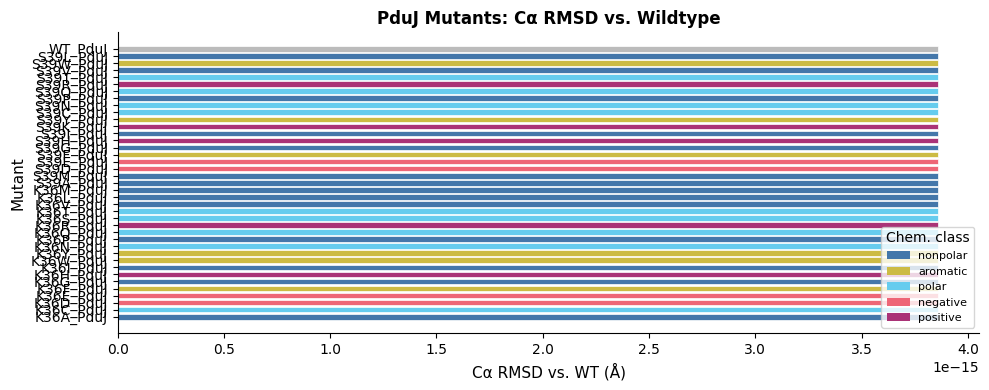

Pre-loading 40 structures ...
Extracting coordinates ...
Computing 780 RMSD pairs ...
Done.  Matrix shape: (40, 40)
  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduJ_rmsd_analysis/rmsd_clustermap.png


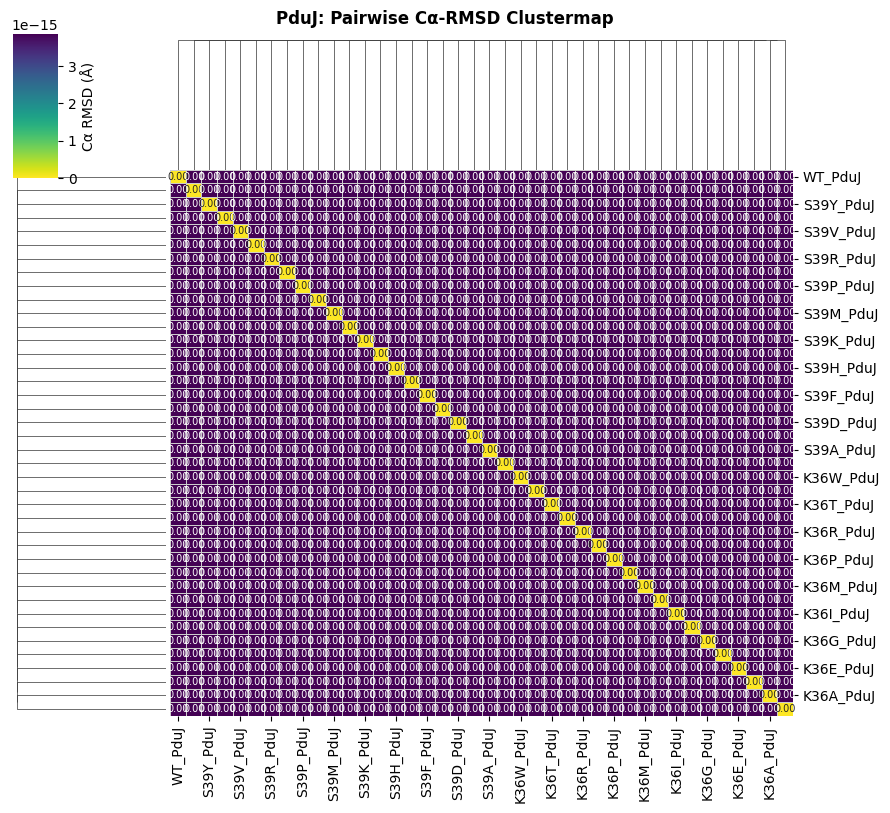

PduJ S39 variants: 19
PduJ K36 variants: 19
  PORE GEOMETRY — PduJ S39 VARIANTS (Rosetta models)
Loading WT reference: /Users/matthew/Desktop/Pdu_PyRosetta/PduJ.pdb
  S39A             pore_d=6.56 Å  pore_r=3.28 Å  cb_dev=0.037 Å
  S39C             pore_d=5.65 Å  pore_r=2.82 Å  cb_dev=0.017 Å
  S39D             pore_d=4.17 Å  pore_r=2.08 Å  cb_dev=0.018 Å
  S39E             pore_d=4.35 Å  pore_r=2.18 Å  cb_dev=0.021 Å
  S39F             pore_d=4.40 Å  pore_r=2.20 Å  cb_dev=0.016 Å
  S39G             pore_d=5.93 Å  pore_r=2.97 Å  cb_dev=0.000 Å
  S39H             pore_d=3.05 Å  pore_r=1.52 Å  cb_dev=0.022 Å
  S39I             pore_d=4.74 Å  pore_r=2.37 Å  cb_dev=0.031 Å
  S39K             pore_d=6.60 Å  pore_r=3.30 Å  cb_dev=0.022 Å
  S39L             pore_d=4.79 Å  pore_r=2.40 Å  cb_dev=0.018 Å
  S39M             pore_d=4.64 Å  pore_r=2.32 Å  cb_dev=0.023 Å
  S39N             pore_d=4.05 Å  pore_r=2.03 Å  cb_dev=0.035 Å
  S39P             pore_d=6.66 Å  pore_r=3.33 Å  cb_dev=0.199 Å
  S

,mutant,residue_name,pore_diameter_A,pore_radius_A,sidechain_volume_A3,mean_cb_distance_A,cb_centroid_dev_A,n_chains,pdb_path
0,S39H,HIS,3.050,1.525,918.0,5.012,0.022,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
1,S39Y,TYR,3.903,1.952,846.0,4.986,0.038,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
2,S39W,TRP,3.926,1.963,978.0,5.007,0.023,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
3,S39N,ASN,4.053,2.026,678.0,4.981,0.035,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
4,S39D,ASP,4.169,2.084,666.0,5.014,0.018,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
5,S39E,GLU,4.352,2.176,828.0,5.007,0.021,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
6,S39F,PHE,4.400,2.200,810.0,5.016,0.016,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
7,S39M,MET,4.644,2.322,744.0,4.996,0.023,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
8,S39V,VAL,4.679,2.340,630.0,5.031,0.027,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
9,S39I,ILE,4.742,2.371,744.0,5.016,0.031,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...


  CRYSTAL PORE GEOMETRY — PduJ S39 (PDB resseq 39)
  K25A      crystal pore_d=6.52 Å  (SER | chain C CB ↔ chain F CB)


,mutant,residue_name,pore_diameter_A,pore_radius_A,chain_a,chain_b,atom_a,atom_b,n_chains,pdb_path
0,K25A,SER,6.521,3.26,C,F,CB,CB,6,/Users/matthew/Desktop/Pdu_PyRosetta/5D6V_fixe...


  PORE GEOMETRY — PduJ K36 VARIANTS (measuring S39 constriction)
Loading WT reference: /Users/matthew/Desktop/Pdu_PyRosetta/PduJ.pdb
  K36A             pore_d=6.30 Å  pore_r=3.15 Å  cb_dev=0.000 Å
  K36C             pore_d=6.30 Å  pore_r=3.15 Å  cb_dev=0.000 Å
  K36D             pore_d=6.30 Å  pore_r=3.15 Å  cb_dev=0.000 Å
  K36E             pore_d=6.30 Å  pore_r=3.15 Å  cb_dev=0.000 Å
  K36F             pore_d=6.25 Å  pore_r=3.13 Å  cb_dev=0.000 Å
  K36G             pore_d=6.30 Å  pore_r=3.15 Å  cb_dev=0.000 Å
  K36H             pore_d=6.30 Å  pore_r=3.15 Å  cb_dev=0.000 Å
  K36I             pore_d=6.30 Å  pore_r=3.15 Å  cb_dev=0.000 Å
  K36L             pore_d=6.24 Å  pore_r=3.12 Å  cb_dev=0.000 Å
  K36M             pore_d=6.30 Å  pore_r=3.15 Å  cb_dev=0.000 Å
  K36N             pore_d=6.30 Å  pore_r=3.15 Å  cb_dev=0.000 Å
  K36P             pore_d=6.24 Å  pore_r=3.12 Å  cb_dev=0.000 Å
  K36Q             pore_d=6.30 Å  pore_r=3.15 Å  cb_dev=0.000 Å
  K36R             pore_d=6.30 Å  p

,mutant,residue_name,pore_diameter_A,pore_radius_A,sidechain_volume_A3,mean_cb_distance_A,cb_centroid_dev_A,n_chains,pdb_path
0,K36Y,SER,6.213,3.106,438.0,5.012,0.0,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
1,K36L,SER,6.236,3.118,438.0,5.012,0.0,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
2,K36P,SER,6.242,3.121,438.0,5.012,0.0,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
3,K36W,SER,6.243,3.122,438.0,5.012,0.0,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
4,K36F,SER,6.254,3.127,438.0,5.012,0.0,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
5,K36A,SER,6.305,3.152,438.0,5.012,0.0,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
6,K36V,SER,6.305,3.152,438.0,5.012,0.0,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
7,K36T,SER,6.305,3.152,438.0,5.012,0.0,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
8,K36S,SER,6.305,3.152,438.0,5.012,0.0,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
9,K36R,SER,6.305,3.152,438.0,5.012,0.0,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# PDUJ TEMPLATE  — set paths, then call the same functions
# ─────────────────────────────────────────────────────────────────────────────

# ── PduJ-specific paths ───────────────────────────────────────────────────
PDUJ_WT_PDB     = os.path.join(HOME, 'PduJ.pdb')
PDUJ_MUTANT_DIR = os.path.join(HOME, 'PduJ_mutants')
PDUJ_BOUND_DIR  = os.path.join(HOME, 'PduJ_mutants', 'bound')
PDUJ_OUT_DIR    = os.path.join(HOME, 'PduJ_rmsd_analysis')
os.makedirs(PDUJ_OUT_DIR, exist_ok=True)

# If PduJ has crystal structures, add them here; otherwise leave empty
PDUJ_CRYSTAL_PDB_MAP = {'K25A': os.path.join(HOME, '5D6V_fixed.pdb')}   # e.g. {'WT': os.path.join(HOME, 'PduJ_WT_crystal.pdb')}
PDUJ_COMPUTED_MAP    = {'WT': os.path.join(HOME, 'PduJ.pdb')}   # e.g. {'WT': os.path.join(HOME, 'PduJ_mutants', 'WT_PduJ.pdb')}

# ── Discover all PduJ mutant PDBs ─────────────────────────────────────────
pduj_mutant_pdbs = discover_mutant_pdbs(PDUJ_MUTANT_DIR)

# ── Mutants vs. WT ────────────────────────────────────────────────────────
df_pduj_wt = mutants_vs_wildtype(
    wt_pdb      = PDUJ_WT_PDB,
    mutant_pdbs = pduj_mutant_pdbs,
    chain       = 'A',
    atom_names  = ('CA',),
)
display(df_pduj_wt.round(3))
df_pduj_wt.to_csv(os.path.join(PDUJ_OUT_DIR, 'rmsd_vs_wt.csv'), index=False)

plot_mutants_vs_wt(
    df_pduj_wt,
    title     = 'PduJ Mutants: Cα RMSD vs. Wildtype',
    save_path = os.path.join(PDUJ_OUT_DIR, 'rmsd_vs_wt.png'),
)
plt.show()

# ── Pairwise RMSD matrix ──────────────────────────────────────────────────
pduj_pdbs_all = dict(pduj_mutant_pdbs)
pduj_pdbs_all['WT'] = PDUJ_WT_PDB
rmsd_mat_j = build_rmsd_matrix(pduj_pdbs_all, chain='A')
rmsd_mat_j.to_csv(os.path.join(PDUJ_OUT_DIR, 'pairwise_rmsd_matrix.csv'))
plot_rmsd_clustermap(
    rmsd_mat_j,
    title     = 'PduJ: Pairwise Cα-RMSD Clustermap',
    save_path = os.path.join(PDUJ_OUT_DIR, 'rmsd_clustermap.png'),
)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# PduJ-specific sub-variables
# S39 = pore constriction (analogous to PduA S40)
# K36 = lysine gate (analogous to PduA K37)
# ─────────────────────────────────────────────────────────────────────────────

PDUJ_DOCKING_ROOT = os.path.join(HOME, 'PduJ_docking_mutants')
PDUJ_COMBINED_CSV = os.path.join(PDUJ_OUT_DIR, 'all_docking_scores.csv')

pduj_s39_pdbs = {k.replace('_PduJ', ''): v for k, v in pduj_mutant_pdbs.items() if k.startswith('S39')}
pduj_s39_pdbs['WT'] = PDUJ_WT_PDB

pduj_k36_pdbs = {k.replace('_PduJ', ''): v for k, v in pduj_mutant_pdbs.items() if k.startswith('K36')}
pduj_k36_pdbs['WT'] = PDUJ_WT_PDB

S39_PORE_RANGE = (37, 41)   # S39-centred window  (cf. PORE_RANGE = (38, 42) for S40)

MUTANTS_FOR_BVU_S39 = sorted(k for k in pduj_s39_pdbs if k != 'WT')
MUTANTS_FOR_BVU_K36 = sorted(k for k in pduj_k36_pdbs if k != 'WT')

print(f'PduJ S39 variants: {len(pduj_s39_pdbs) - 1}')
print(f'PduJ K36 variants: {len(pduj_k36_pdbs) - 1}')

# ── CALL 1 — S39 pore geometry (Rosetta models) ───────────────────────────
print('=' * 60)
print('  PORE GEOMETRY — PduJ S39 VARIANTS (Rosetta models)')
print('=' * 60)

df_pore_geo_s39 = batch_pore_geometry(
    pdb_map        = pduj_s39_pdbs,
    target_pdb_num = 39,
    wt_key         = 'WT',
    fix_chains     = FIX_CHAINS,
)
display(df_pore_geo_s39.round(3))
df_pore_geo_s39.to_csv(os.path.join(PDUJ_OUT_DIR, 'pore_geometry_S39.csv'), index=False)

if PDUJ_CRYSTAL_PDB_MAP:
    print('=' * 60)
    print('  CRYSTAL PORE GEOMETRY — PduJ S39 (PDB resseq 39)')
    print('=' * 60)
    df_crystal_pore_s39 = batch_crystal_pore_geometry(
        crystal_pdb_map = PDUJ_CRYSTAL_PDB_MAP,
        target_resseq   = 39,
    )
    display(df_crystal_pore_s39.round(3))
    df_crystal_pore_s39.to_csv(os.path.join(PDUJ_OUT_DIR, 'crystal_pore_geometry_S39.csv'), index=False)
else:
    df_crystal_pore_s39 = None
    print('  (No PduJ crystal structures configured — skipping crystal pore geometry)')

# ── CALL 2 — K36 pore geometry (Rosetta models, measuring S39 constriction) ─
print('=' * 60)
print('  PORE GEOMETRY — PduJ K36 VARIANTS (measuring S39 constriction)')
print('=' * 60)

df_pore_geo_k36 = batch_pore_geometry(
    pdb_map        = pduj_k36_pdbs,
    target_pdb_num = 39,   # measure S39 pore (actual constriction), not K36 position
    wt_key         = 'WT',
    fix_chains     = FIX_CHAINS,
)
display(df_pore_geo_k36.round(3))
df_pore_geo_k36.to_csv(os.path.join(PDUJ_OUT_DIR, 'pore_geometry_K36.csv'), index=False)


  Combined 39 docking score files → /Users/matthew/Desktop/Pdu_PyRosetta/PduJ_rmsd_analysis/all_docking_scores.csv

S39 variants — CB RMSD (bound vs. unbound):
  Located best-pose files for 19/19 mutants
Comparing bound vs. unbound for 19 mutants ...
  S39A             full RMSD =  5.491 Å  pore RMSD =  0.000 Å (1 atoms)
  S39C             full RMSD =  5.491 Å  pore RMSD =  0.000 Å (1 atoms)
  S39D             full RMSD =  5.490 Å  pore RMSD =  0.000 Å (1 atoms)
  S39E             full RMSD =  5.490 Å  pore RMSD =  0.000 Å (1 atoms)
  S39F             full RMSD =  5.490 Å  pore RMSD =  0.000 Å (1 atoms)
  S39G             full RMSD =  5.490 Å  pore RMSD =  0.000 Å (1 atoms)
  S39H             full RMSD =  5.490 Å  pore RMSD =  0.000 Å (1 atoms)
  S39I             full RMSD =  5.491 Å  pore RMSD =  0.000 Å (1 atoms)
  S39K             full RMSD =  5.490 Å  pore RMSD =  0.000 Å (1 atoms)
  S39L             full RMSD =  5.490 Å  pore RMSD =  0.000 Å (1 atoms)
  S39M             full RMSD 

,mutant_label,full_rmsd_A,pore_rmsd_A,n_full,n_pore,unbound_pdb,bound_pdb
0,S39K,5.490,0.0,69,1,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
1,S39G,5.490,0.0,69,1,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
2,S39L,5.490,0.0,69,1,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
3,S39V,5.490,0.0,69,1,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
4,S39Q,5.490,0.0,69,1,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
5,S39P,5.490,0.0,69,1,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
6,S39M,5.490,0.0,69,1,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
7,S39W,5.490,0.0,69,1,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
8,S39Y,5.490,0.0,69,1,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
9,S39H,5.490,0.0,69,1,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...


  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduJ_rmsd_analysis/bound_vs_unbound_CB_S39.png


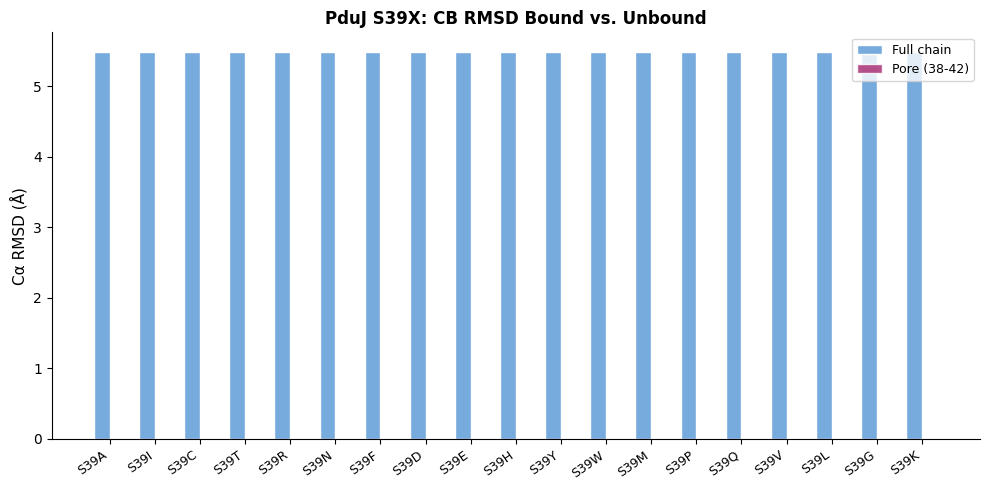


K36 variants — CB RMSD (pore_range = S39 pore motif):
  Located best-pose files for 19/19 mutants
Comparing bound vs. unbound for 19 mutants ...
  K36A             full RMSD =  5.489 Å  pore RMSD =  0.000 Å (1 atoms)
  K36C             full RMSD =  5.490 Å  pore RMSD =  0.000 Å (1 atoms)
  K36D             full RMSD =  5.489 Å  pore RMSD =  0.000 Å (1 atoms)
  K36E             full RMSD =  5.490 Å  pore RMSD =  0.000 Å (1 atoms)
  K36F             full RMSD =  5.489 Å  pore RMSD =  0.000 Å (1 atoms)
  K36G             full RMSD =  5.476 Å  pore RMSD =  0.000 Å (1 atoms)
  K36H             full RMSD =  5.490 Å  pore RMSD =  0.000 Å (1 atoms)
  K36I             full RMSD =  5.490 Å  pore RMSD =  0.000 Å (1 atoms)
  K36L             full RMSD =  5.490 Å  pore RMSD =  0.000 Å (1 atoms)
  K36M             full RMSD =  5.490 Å  pore RMSD =  0.000 Å (1 atoms)
  K36N             full RMSD =  5.489 Å  pore RMSD =  0.000 Å (1 atoms)
  K36P             full RMSD =  5.489 Å  pore RMSD =  0.000 Å 

,mutant_label,full_rmsd_A,pore_rmsd_A,n_full,n_pore,unbound_pdb,bound_pdb
0,K36G,5.476,0.0,67,1,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
1,K36P,5.489,0.0,69,1,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
2,K36R,5.489,0.0,69,1,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
3,K36N,5.489,0.0,69,1,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
4,K36S,5.489,0.0,69,1,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
5,K36A,5.489,0.0,69,1,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
6,K36F,5.489,0.0,69,1,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
7,K36D,5.489,0.0,69,1,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
8,K36H,5.490,0.0,69,1,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
9,K36C,5.490,0.0,69,1,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...


  Saved → /Users/matthew/Desktop/Pdu_PyRosetta/PduJ_rmsd_analysis/bound_vs_unbound_CB_K36.png


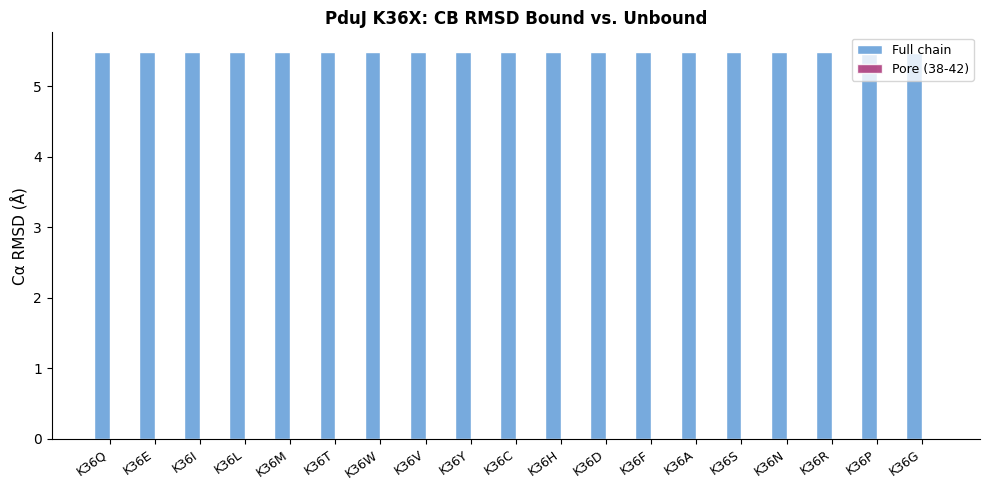

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# PduJ CALL 3+4 — Bound vs. Unbound Conformational Shift (S39 and K36)
# ─────────────────────────────────────────────────────────────────────────────

# Collect all docking scores into combined CSV
_score_files_j = sorted(glob.glob(os.path.join(PDUJ_DOCKING_ROOT, '*/docking_scores.csv')))
if _score_files_j:
    pd.concat([pd.read_csv(f) for f in _score_files_j], ignore_index=True).to_csv(
        PDUJ_COMBINED_CSV, index=False)
    print(f'  Combined {len(_score_files_j)} docking score files → {PDUJ_COMBINED_CSV}')
else:
    print(f'  WARNING: no docking_scores.csv found under {PDUJ_DOCKING_ROOT}')
    print('  CALL 3-6 require PduJ docking data. Skipping.')

if _score_files_j:
    print('\nS39 variants — CB RMSD (bound vs. unbound):')
    df_bvu_s39 = batch_bound_vs_unbound_fixed(
        unbound_dir   = PDUJ_MUTANT_DIR,
        docking_root  = PDUJ_DOCKING_ROOT,
        mutants       = MUTANTS_FOR_BVU_S39,
        chain         = 'A',
        pore_range    = S39_PORE_RANGE,
        atom_names    = ('CB',),
        fix_chains    = FIX_CHAINS,
        score_col     = 'interface_energy',
    )
    display(df_bvu_s39.round(3))
    df_bvu_s39.to_csv(os.path.join(PDUJ_OUT_DIR, 'bound_vs_unbound_S39.csv'), index=False)

    fig_bvu_s39 = plot_bound_vs_unbound(
        df_bvu_s39,
        title     = 'PduJ S39X: CB RMSD Bound vs. Unbound',
        save_path = os.path.join(PDUJ_OUT_DIR, 'bound_vs_unbound_CB_S39.png'),
    )
    plt.show()

    # K36 is slightly outside the pore. Pore metrics are always measured at the
    # S39 pore window (37,41) — the same pore motif used for S39 variants.
    print('\nK36 variants — CB RMSD (pore_range = S39 pore motif):')
    df_bvu_k36 = batch_bound_vs_unbound_fixed(
        unbound_dir   = PDUJ_MUTANT_DIR,
        docking_root  = PDUJ_DOCKING_ROOT,
        mutants       = MUTANTS_FOR_BVU_K36,
        chain         = 'A',
        pore_range    = S39_PORE_RANGE,
        atom_names    = ('CB',),
        fix_chains    = FIX_CHAINS,
        score_col     = 'interface_energy',
    )
    display(df_bvu_k36.round(3))
    df_bvu_k36.to_csv(os.path.join(PDUJ_OUT_DIR, 'bound_vs_unbound_K36.csv'), index=False)

    fig_bvu_k36 = plot_bound_vs_unbound(
        df_bvu_k36,
        title     = 'PduJ K36X: CB RMSD Bound vs. Unbound',
        save_path = os.path.join(PDUJ_OUT_DIR, 'bound_vs_unbound_CB_K36.png'),
    )
    plt.show()


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# PduJ CALL 5 — Pore Geometry from Best Docked Poses (bound + apo)
# ─────────────────────────────────────────────────────────────────────────────

if not _score_files_j:
    print('No docking data — skipping CALL 5.')
else:
    best_s39 = find_best_bound_poses(PDUJ_DOCKING_ROOT, MUTANTS_FOR_BVU_S39,
                                      score_col='interface_energy')
    best_s39['WT'] = PDUJ_WT_PDB

    best_k36_pore = find_best_bound_poses(PDUJ_DOCKING_ROOT, MUTANTS_FOR_BVU_K36,
                                           score_col='interface_energy')
    best_k36_pore['WT'] = PDUJ_WT_PDB

    print('Measuring pore geometry from S39 bound poses (pure PDB reader):')
    df_pore_bound_s39 = batch_crystal_pore_geometry(
        crystal_pdb_map     = best_s39,
        target_resseq       = 39,
        use_absolute_resseq = False,
    )
    display(df_pore_bound_s39.round(3))

    print('Measuring pore geometry from S39 unbound mutant PDBs:')
    df_pore_apo_s39 = batch_crystal_pore_geometry(
        crystal_pdb_map     = pduj_s39_pdbs,
        target_resseq       = 39,   # PDB resseq 39 = S39 directly (per-chain numbering)
        use_absolute_resseq = True,
    )
    display(df_pore_apo_s39.round(3))

    print('Measuring pore geometry from K36 bound poses (pure PDB reader):')
    df_pore_bound_k36 = batch_crystal_pore_geometry(
        crystal_pdb_map     = best_k36_pore,
        target_resseq       = 39,
        use_absolute_resseq = False,
    )
    display(df_pore_bound_k36.round(3))

    print('Measuring pore geometry from K36 unbound mutant PDBs:')
    df_pore_apo_k36 = batch_crystal_pore_geometry(
        crystal_pdb_map     = pduj_k36_pdbs,
        target_resseq       = 39,   # PDB resseq 39 = S39 directly (per-chain numbering)
        use_absolute_resseq = True,
    )
    display(df_pore_apo_k36.round(3))

  Located best-pose files for 19/19 mutants
  Located best-pose files for 19/19 mutants
Measuring pore geometry from S39 bound poses (pure PDB reader):
  S39A      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39C      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39D      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39E      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39F      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39G      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39H      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39I      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39K      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39L      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39M      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39N      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39P      crystal pore_d=12.04

,mutant,residue_name,pore_diameter_A,pore_radius_A,chain_a,chain_b,atom_a,atom_b,n_chains,pdb_path
0,S39A,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
1,S39W,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
2,S39V,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
3,S39T,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
4,S39R,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
5,S39Q,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
6,S39P,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
7,S39N,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
8,S39M,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
9,S39L,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...


Measuring pore geometry from S39 unbound mutant PDBs:
  S39A      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39C      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39D      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39E      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39F      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39G      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39H      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39I      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39K      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39L      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39M      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39N      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39P      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39Q      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain 

,mutant,residue_name,pore_diameter_A,pore_radius_A,chain_a,chain_b,atom_a,atom_b,n_chains,pdb_path
0,S39A,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
1,S39W,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
2,S39V,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
3,S39T,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
4,S39R,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
5,S39Q,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
6,S39P,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
7,S39N,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
8,S39M,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
9,S39L,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...


Measuring pore geometry from K36 bound poses (pure PDB reader):
  K36A      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36C      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36D      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36E      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36F      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36G      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36H      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36I      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36L      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36M      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36N      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36P      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36Q      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36R      crystal pore_d=12.04 Å  (GLY | chain A C

,mutant,residue_name,pore_diameter_A,pore_radius_A,chain_a,chain_b,atom_a,atom_b,n_chains,pdb_path
0,K36A,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
1,K36W,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
2,K36V,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
3,K36T,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
4,K36S,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
5,K36R,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
6,K36Q,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
7,K36P,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
8,K36N,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...
9,K36M,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_dock...


Measuring pore geometry from K36 unbound mutant PDBs:
  K36A      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36C      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36D      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36E      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36F      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36G      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36H      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36I      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36L      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36M      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36N      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36P      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36Q      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  K36R      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain 

,mutant,residue_name,pore_diameter_A,pore_radius_A,chain_a,chain_b,atom_a,atom_b,n_chains,pdb_path
0,K36A,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
1,K36W,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
2,K36V,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
3,K36T,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
4,K36S,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
5,K36R,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
6,K36Q,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
7,K36P,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
8,K36N,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...
9,K36M,GLY,12.042,6.021,A,D,CA,CA,6,/Users/matthew/Desktop/Pdu_PyRosetta/PduJ_muta...


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# PduJ CALL 6 — Spearman ρ Heatmap: AA physicochemical properties vs. metrics
#
# Uses _build_spearman_matrix and _plot_spearman_heatmap defined in PduA CALL 5
# (cell 29). Requires that cell to have been run first.
#
# PduJ has no literature ΔΔG, OD600, or assembly enrichment data yet.
# Those columns will appear as NaN in the correlation matrices.
# ─────────────────────────────────────────────────────────────────────────────

if not os.path.exists(PDUJ_COMBINED_CSV):
    print(f'PDUJ_COMBINED_CSV not found at {PDUJ_COMBINED_CSV}')
    print('Run PduJ docking first, then re-run this cell.')
else:
    # Build unbound pore geometry for all PduJ S39 and K36 models (rank-based lookup)
    _df_apo_s39_hm = batch_crystal_pore_geometry(
        crystal_pdb_map     = pduj_s39_pdbs,
        target_resseq       = 39,   # PDB resseq 39 = S39 directly (per-chain numbering)
        use_absolute_resseq = True,
        hexamer_chains      = None,
    )
    _df_apo_k36_hm = batch_crystal_pore_geometry(
        crystal_pdb_map     = pduj_k36_pdbs,
        target_resseq       = 39,   # PDB resseq 39 = S39 directly (per-chain numbering)
        use_absolute_resseq = True,
        hexamer_chains      = None,
    )

    print('=' * 60)
    print('  BUILDING SPEARMAN ρ MATRICES — PduJ')
    print('=' * 60)

    rho_s39, p_s39 = _build_spearman_matrix(
        site_prefix  = 'S39',
        combined_csv = PDUJ_COMBINED_CSV,
        df_pore_geo  = df_pore_geo_s39,
        df_apo_pore  = _df_apo_s39_hm,
        df_pr_delta  = None,
        lit_ddg      = {},
        od600_map    = {},
        assembly_map = {},
    )

    rho_k36, p_k36 = _build_spearman_matrix(
        site_prefix  = 'K36',
        combined_csv = PDUJ_COMBINED_CSV,
        df_pore_geo  = df_pore_geo_k36,
        df_apo_pore  = _df_apo_k36_hm,
        df_pr_delta  = None,
        lit_ddg      = {},
        od600_map    = {},
        assembly_map = {},
    )

    print('\nPduJ S39 Spearman ρ matrix:')
    display(rho_s39.round(3))
    print('\nPduJ K36 Spearman ρ matrix:')
    display(rho_k36.round(3))

    _vabs = min(1.0, float(max(
        np.nanmax(np.abs(rho_s39.values)),
        np.nanmax(np.abs(rho_k36.values)),
    )))

    fig, (ax_s39, ax_k36) = plt.subplots(
        2, 1,
        figsize=(max(len(rho_s39.columns), len(rho_k36.columns)) * 1.55 + 1.5,
                 len(PHYS_PROPS) * 0.78 * 2 + 1.2),
        gridspec_kw={'hspace': 0.55},
    )
    im_s39 = _plot_spearman_heatmap(
        rho_s39, p_s39,
        title='PduJ S39X — physicochemical property correlations',
        ax=ax_s39, vabs=_vabs,
    )
    im_k36 = _plot_spearman_heatmap(
        rho_k36, p_k36,
        title='PduJ K36X — physicochemical property correlations',
        ax=ax_k36, vabs=_vabs,
    )
    fig.subplots_adjust(right=0.88)
    cbar_ax = fig.add_axes([0.91, 0.12, 0.025, 0.76])
    fig.colorbar(im_s39, cax=cbar_ax).set_label('Spearman ρ', fontsize=10)
    fig.suptitle(
        'PduJ: Spearman ρ — AA physicochemical properties vs. docking / structural metrics',
        fontsize=11, y=1.01,
    )
    _hm_path = os.path.join(PDUJ_OUT_DIR, 'spearman_property_heatmap_PduJ.png')
    fig.savefig(_hm_path, dpi=150, bbox_inches='tight')
    print(f'\n  Saved → {_hm_path}')
    plt.show()

    rho_s39.to_csv(os.path.join(PDUJ_OUT_DIR, 'spearman_matrix_S39.csv'))
    rho_k36.to_csv(os.path.join(PDUJ_OUT_DIR, 'spearman_matrix_K36.csv'))
    print(f'  Saved → {PDUJ_OUT_DIR}/spearman_matrix_S39.csv')
    print(f'  Saved → {PDUJ_OUT_DIR}/spearman_matrix_K36.csv')

  S39A      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39C      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39D      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39E      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39F      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39G      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39H      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39I      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39K      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39L      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39M      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39N      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39P      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39Q      crystal pore_d=12.04 Å  (GLY | chain A CA ↔ chain D CA)
  S39R      crystal pore_d=12.04 Å  (GLY | chain

KeyError: 'mutant'